# Lección 17.1 · Clasificación de secuencias con ML clásico

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-17-machine-learning/17.1_ml_clasico_secuencias.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 17 — Machine Learning e IA en bioinformática** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Python y NumPy; probabilidad básica; matrices de puntuación y PWM (Módulos 3 y 4); motivos (Lección 13.3) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Formular** un problema bioinformático como aprendizaje supervisado (riesgo empírico frente a riesgo esperado) y
   **convertir** secuencias en vectores: codificación *one-hot*, espectro de $k$-mers y núcleo de espectro.
2. **Derivar** el gradiente de la regresión logística, **programar** el descenso por gradiente desde cero y **ver**
   cómo se mueve la frontera de decisión en cada paso.
3. **Explicar** qué optimiza una máquina de vectores de soporte (margen, holguras, vectores de soporte, truco del
   núcleo) y por qué un *random forest* reduce la varianza de los árboles.
4. **Diagnosticar** el compromiso sesgo-varianza y **diseñar** una validación honesta: validación cruzada por grupos,
   preprocesamiento dentro del *pipeline* y detección de atajos (como el contenido de GC).
5. **Elegir** métricas adecuadas cuando los positivos son raros: curvas ROC frente a curvas de precisión-exhaustividad.
6. **Aplicar** todo lo anterior a dos problemas **reales**: los promotores σ⁷⁰ de *E. coli* (Harley y Reynolds, 1987)
   y los sitios de unión de **CTCF** medidos por ChIP-seq en células humanas GM12878 (ENCODE).

## 🗺️ Mapa de la clase

1. El catador que nunca leyó un manual: el aprendizaje supervisado y nuestros dos problemas reales
2. Representar una secuencia como vector: *one-hot* y espectro de $k$-mers
3. El núcleo de espectro (ejemplo del libro «Núcleo de espectro a mano»)
4. Regresión logística: sigmoide, entropía cruzada y gradiente (ejemplo «Un paso de descenso por gradiente»,
   🎬 animación, 🔍 interactivo con los promotores de *E. coli*)
5. Máquinas de vectores de soporte: margen, núcleo y la figura de fronteras del libro (🔍 interactivo con CTCF)
6. Árboles de decisión y *random forests*
7. Sesgo, varianza y complejidad (🎬 animación)
8. Validación cruzada y la fuga de información (por homología, por preprocesamiento y por atajos)
9. Métricas para clases desbalanceadas (ejemplo «Un clasificador excelente que casi siempre se equivoca», 🔍 interactivo)
10. Todo junto con scikit-learn sobre CTCF
11. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Clasificación de secuencias con ML clásico» del
> capítulo 17 del libro *Bioinformática Práctica*. Usamos sus símbolos ($\mathbf{x}_i$, $y_i$, $f_{\boldsymbol\theta}$,
> $\ell$, $\Phi_k$, $\phi_u$, $K_k$, $\tilde K_k$, $\sigma$, $\mathcal{L}$, $\eta$, $C$, $\xi_i$, $\alpha_i$, $G$, $\rho$,
> $B$, $F_k$, $\pi$, $\tau$), su numeración de ecuaciones (17.1–17.15 en el orden del libro) y reproducimos, cifra por
> cifra y con las mismas semillas, sus ejemplos resueltos y sus figuras de fronteras, sesgo-varianza, fuga de
> información y curvas ROC/PR. El notebook se puede seguir sin el libro.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, json, math, time, warnings
from itertools import product
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib as mpl
from matplotlib.patches import Rectangle

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (KFold, GroupKFold, StratifiedKFold, LeaveOneOut,
                                     cross_val_score, cross_validate, cross_val_predict)
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score, average_precision_score)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons
import sklearn
warnings.filterwarnings("ignore")

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name, fallback_url=None):
    """Ruta de un archivo del curso: 1) ../data; 2) repositorio de GitHub; 3) URL original (si se da)."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        try:
            urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
        except Exception:
            if fallback_url is None:
                raise
            urllib.request.urlretrieve(fallback_url, name)
    return name

def read_fasta(path):
    """Lee un FASTA (gzip o texto) y devuelve [(cabecera, SECUENCIA en mayúsculas)]."""
    op = gzip.open if str(path).endswith(".gz") else open
    recs = []
    with op(path, "rt") as fh:
        for line in fh:
            line = line.strip()
            if line.startswith(">"):
                recs.append([line[1:], []])
            elif line:
                recs[-1][1].append(line)
    return [(h, "".join(s).upper()) for h, s in recs]   # el fondo viene enmascarado en minúsculas

# ---- Funciones del libro (figuras/cap17/generar.py), sin cambios ----
def kmers(k, alf="ACGT"):
    return ["".join(p) for p in product(alf, repeat=k)]

def spectrum(s, k, alf="ACGT"):
    idx = {u: i for i, u in enumerate(kmers(k, alf))}
    v = np.zeros(len(idx))
    for i in range(len(s) - k + 1):
        u = s[i:i + k]
        if u in idx:
            v[idx[u]] += 1
    return v

sig = lambda z: 1 / (1 + np.exp(-z))
fmt = lambda v, d=3: f"{v:.{d}f}".replace(".", ",")      # números con coma decimal
print("Listo para la Lección 17.1 · numpy", np.__version__, "· scikit-learn", sklearn.__version__)

Entorno listo ✔  |  Colab: False


Listo para la Lección 17.1 · numpy 2.5.3 · scikit-learn 1.9.1


## 1. El catador que nunca leyó un manual

Un catador experto distingue un Rioja de un Burdeos con un sorbo, pero sería incapaz de escribir las reglas que usa.
Aprendió probando miles de vinos **etiquetados**, y su cerebro ajustó poco a poco una frontera entre «esto es Rioja» y
«esto no». Si sólo hubiera probado vinos de tres bodegas, confundiría «Rioja» con «el estilo de esas tres bodegas» y
fracasaría ante la cuarta. El aprendizaje supervisado hace lo mismo con secuencias, y comparte el mismo riesgo:
**aprender las bodegas en lugar de la región**. Esta lección es, en el fondo, una colección de herramientas para no
caer en esa trampa.

### El problema del aprendizaje supervisado

Supongamos que tenemos $n$ secuencias de ADN y, para cada una, un experimento (por ejemplo, ChIP-seq) que dice si un
factor de transcripción se une a ella ($y=1$) o no ($y=0$). Queremos una función que, dada una secuencia **nueva**,
prediga la etiqueta. Formalmente, dado un conjunto de entrenamiento
$\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{n}$ extraído de una distribución desconocida $P(\mathbf{x},y)$ y una familia
de funciones $f_{\boldsymbol\theta}$, buscamos los parámetros que minimizan el **riesgo empírico regularizado**
(ecuación 17.1 del libro):

$$
\hat{\boldsymbol\theta} = \arg\min_{\boldsymbol\theta}\; \frac{1}{n}\sum_{i=1}^{n} \ell\big(y_i, f_{\boldsymbol\theta}(\mathbf{x}_i)\big) \;+\; \lambda\, \Omega(\boldsymbol\theta).
$$

Pero lo que realmente nos importa es el **riesgo esperado**
$R(\boldsymbol\theta)=\mathbb{E}_{(\mathbf{x},y)\sim P}\big[\ell(y,f_{\boldsymbol\theta}(\mathbf{x}))\big]$ sobre
secuencias que el modelo nunca vio.

| Símbolo | Significado |
|---|---|
| $\mathbf{x}_i,\ y_i$ | Representación numérica de la $i$-ésima secuencia y su etiqueta (clase o valor) |
| $f_{\boldsymbol\theta}$ | Modelo con parámetros $\boldsymbol\theta$ (pesos de una regresión, de una red, umbrales de un árbol) |
| $\ell(y,\hat y)$ | Función de pérdida: cuánto cuesta predecir $\hat y$ cuando la verdad es $y$ |
| $\Omega(\boldsymbol\theta),\ \lambda$ | Penalización de complejidad (regularización) y su peso |
| $P(\mathbf{x},y)$ | Distribución de la población de secuencias sobre la que se usará el modelo |

Toda la dificultad del aprendizaje automático está en la distancia entre esas dos cantidades: minimizamos el error
sobre los datos que tenemos, pero nos importa el error sobre los que no tenemos. Un modelo que minimiza el primero sin
controlar el segundo **sobreajusta**, como el estudiante que memoriza las respuestas del examen del año pasado.

> 🤔 **Antes de seguir, piense.** Un modelo acierta el 100 % de las secuencias con las que se entrenó. ¿Qué dice eso de
> su riesgo esperado? (Respuesta: casi nada. Un modelo que memoriza una tabla de consulta también acierta el 100 %
> en entrenamiento y puede fallar la mitad de las veces con secuencias nuevas.)

### Nuestros dos problemas reales

A lo largo de la clase alternaremos los ejemplos pequeños del libro (que se pueden hacer a mano) con dos problemas
reales, elegidos porque cada uno se adapta a una representación distinta:

| Problema | Datos | Positivos / negativos | Por qué es interesante |
|---|---|---|---|
| **Promotores σ⁷⁰ de *E. coli*** | 106 secuencias de 57 pb, alineadas en el inicio de la transcripción (posiciones −50 a +7) | 53 promotores reales (Harley y Reynolds, 1987) / 53 fragmentos no promotores | Conjunto clásico del repositorio UCI; las cajas −35 y −10 están en posiciones **fijas**, ideal para *one-hot* |
| **Sitios de unión de CTCF** | 1 000 ventanas de 100 pb centradas en las cumbres de los picos de ChIP-seq de CTCF (ENCODE, GM12878, reutilizadas de la Lección 13.3) | 1 000 sitios / 6 202 ventanas aleatorias de hg38 | El motivo aparece en **cualquier** posición; hay un atajo tentador (el GC) y los positivos son raros en el genoma |

Un promotor es la «pista de aterrizaje» de la ARN polimerasa: la subunidad σ⁷⁰ reconoce dos hexámeros, la caja −35
(consenso `TTGACA`) y la caja −10 (`TATAAT`). CTCF es la proteína «arquitecta» que, junto con la cohesina, delimita los
bucles de la cromatina; reconoce un motivo de unos 19 pb rico en GC. Dos biologías, un mismo marco matemático.

In [2]:
# ---- Problema real 1: promotores de E. coli (UCI Machine Learning Repository) ----
UCI_URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/"
           "promoter-gene-sequences/promoters.data")
rows = [l.strip().split(",") for l in open(course_file("171_uci_ecoli_promoters.data", UCI_URL)) if l.strip()]
prom_seqs = [r[2].strip().upper() for r in rows]
prom_names = [r[1] for r in rows]
y_prom = np.array([r[0] == "+" for r in rows], int)
POS_PROM = np.r_[np.arange(-50, 0), np.arange(1, 8)]      # no existe la posición 0
print(f"Promotores: {len(prom_seqs)} secuencias de {len(prom_seqs[0])} pb · {y_prom.sum()} positivas")
print("Ejemplo positivo  ", prom_names[0], prom_seqs[0])
print("Ejemplo negativo  ", prom_names[-1], prom_seqs[-1])

# ---- Problema real 2: CTCF (ENCODE GM12878) frente a fondo genómico aleatorio (hg38) ----
peaks = read_fasta(course_file("133_ctcf_gm12878_summits500.fa.gz"))
bg = read_fasta(course_file("133_hg38_random_background100.fa.gz"))
ctcf_pos = [s[200:300] for h, s in peaks]                   # 100 pb centrados en la cumbre
ctcf_neg = [s for h, s in bg]
chr_pos = np.array([h.split(":")[0] for h, s in peaks])
chr_neg = np.array([h.split(":")[0] for h, s in bg])
print(f"\nCTCF: {len(ctcf_pos)} ventanas positivas · fondo: {len(ctcf_neg)} ventanas de "
      f"{len(ctcf_neg[0])} pb · cromosomas: {len(set(chr_pos))}")
print("Ejemplo de sitio:", ctcf_pos[0])

Promotores: 106 secuencias de 57 pb · 53 positivas
Ejemplo positivo   S10 TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGCGGGCTTGTCGT
Ejemplo negativo   1442 TAACATTAATAAATAAGGAGGCTCTAATGGCACTCATTAGCCAATCAATCAAGAACT

CTCF: 1000 ventanas positivas · fondo: 6202 ventanas de 100 pb · cromosomas: 23
Ejemplo de sitio: CGAGAGTGCGGCGGAAACCACGCGGCGCCGCCGGGCGGGCAGCAGGGGGAGCCGCTGAGCCAGGGGCTGAGGGTTGCAGGCGGCTGTGGCCTTGGCCAGG


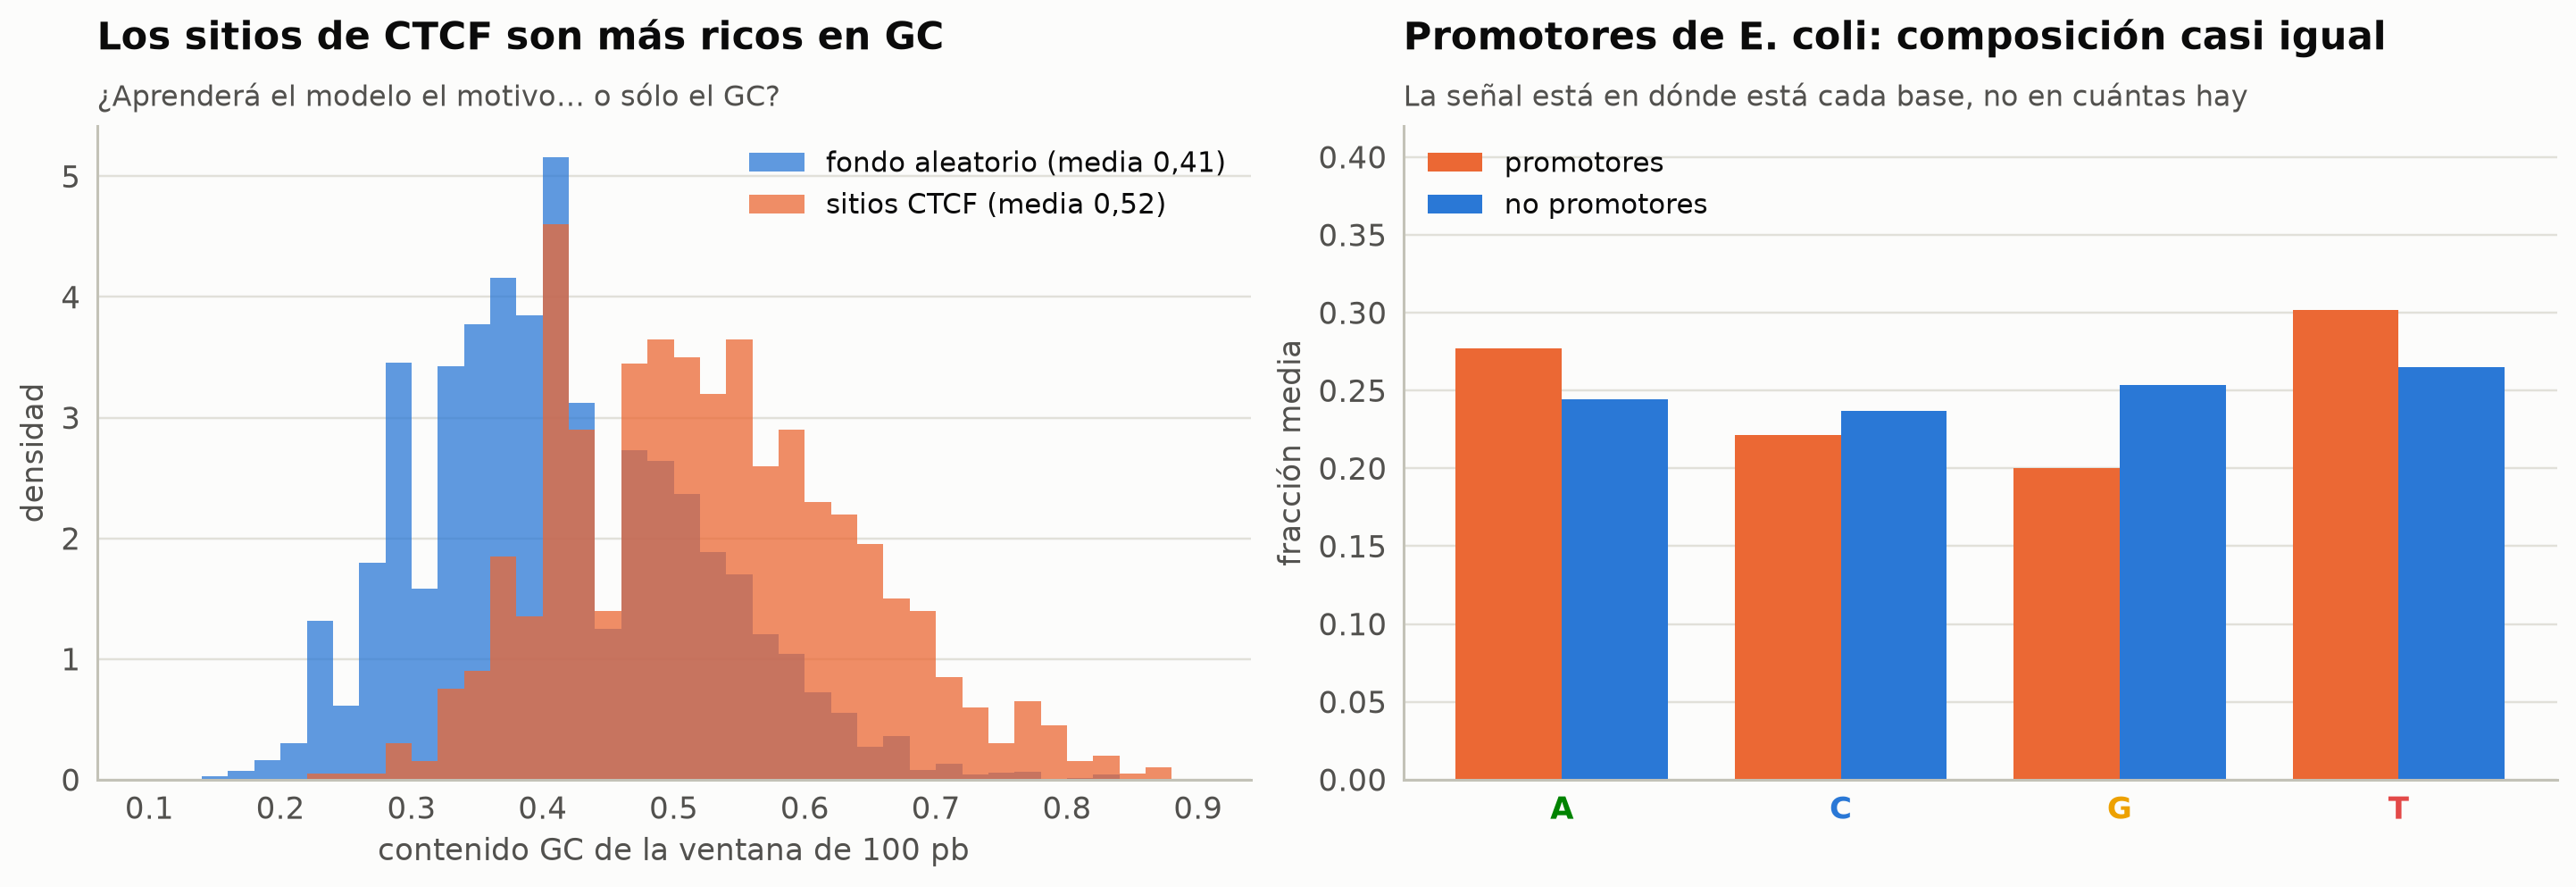

In [3]:
def gc_content(s):
    return (s.count("G") + s.count("C")) / len(s)

def cpg_oe(s):
    """Razón CpG observada/esperada: #CG · L / (#C · #G)."""
    c, g = s.count("C"), s.count("G")
    cg = sum(s[i:i + 2] == "CG" for i in range(len(s) - 1))
    return cg * len(s) / (c * g) if c * g > 0 else 0.0

gc_p = np.array([gc_content(s) for s in ctcf_pos]); gc_n = np.array([gc_content(s) for s in ctcf_neg])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ax = axes[0]
bins = np.linspace(0.1, 0.9, 41)
ax.hist(gc_n, bins, color=ec.BLUE, alpha=0.75, density=True, label=f"fondo aleatorio (media {fmt(gc_n.mean(), 2)})")
ax.hist(gc_p, bins, color=ec.ORANGE, alpha=0.75, density=True, label=f"sitios CTCF (media {fmt(gc_p.mean(), 2)})")
ax.set_xlabel("contenido GC de la ventana de 100 pb"); ax.set_ylabel("densidad")
ax.legend(frameon=False, loc="upper right")
ec.title(ax, "Los sitios de CTCF son más ricos en GC", "¿Aprenderá el modelo el motivo… o sólo el GC?")
ax = axes[1]
frac = np.array([[s.count(b) / len(s) for b in "ACGT"] for s in prom_seqs])
xb = np.arange(4)
for j, (lab, col) in enumerate([("promotores", ec.ORANGE), ("no promotores", ec.BLUE)]):
    m = frac[y_prom == 1 - j].mean(0)
    ax.bar(xb + (j - 0.5) * 0.38, m, 0.38, color=col, label=lab)
ax.set_xticks(xb, list("ACGT")); ax.set_ylabel("fracción media")
for t, b in zip(ax.get_xticklabels(), "ACGT"):
    t.set_color(ec.NUC_COLORS[b]); t.set_fontweight("bold")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, 1.0))
ax.set_ylim(0, 0.42)
ec.title(ax, "Promotores de E. coli: composición casi igual", "La señal está en dónde está cada base, no en cuántas hay")
plt.show()

> 🔎 **Qué observamos.** Los dos problemas son distintos desde el primer vistazo. En CTCF, el contenido de GC por sí
> solo ya separa parcialmente las clases: un modelo perezoso puede aprender «rico en GC ⇒ CTCF» y parecer bueno sin saber
> nada del motivo. En los promotores, la composición global apenas cambia (los promotores son algo más ricos en A/T):
> la información está en la **posición** de las bases. Volveremos a ambas observaciones.

## 2. Representar una secuencia como vector

Los algoritmos de ML trabajan con vectores de números, no con cadenas de letras. Es como pedirle a una balanza que
compare dos recetas: primero hay que traducir «una pizca de sal» a gramos. La elección de la representación, la
**ingeniería de atributos**, decide en buena medida qué puede aprender el modelo.

### 2.1 Codificación *one-hot*

La representación más fiel asigna a cada posición un vector indicador de longitud 4 (ecuación 17.2 del libro):

$$
X_{c,i} = \mathbb{1}\left[x_i = c\right],\qquad c\in\{\texttt{A},\texttt{C},\texttt{G},\texttt{T}\},\quad i=1,\dots,L.
$$

| Símbolo | Significado |
|---|---|
| $X$ | Matriz *one-hot* de tamaño $4\times L$; cada columna tiene un único 1 |
| $x_i$ | Base en la posición $i$ de la secuencia |
| $L$ | Longitud de la secuencia |
| $\mathbb{1}[\cdot]$ | Indicadora: vale 1 si la condición se cumple y 0 si no |

**A mano.** Para `GAT`: la columna 1 es $(0,0,1,0)^\top$ (G), la 2 es $(1,0,0,0)^\top$ (A) y la 3 es $(0,0,0,1)^\top$ (T).

No introduce ningún orden artificial entre las bases: codificar `A`=1, `C`=2, `G`=3, `T`=4 haría creer al modelo que
`T` es «más» que `A`, o que `C` está «entre» `A` y `G`. Y conserva la posición exacta de cada nucleótido. Su
inconveniente es que un motivo desplazado una base produce un vector completamente distinto: un clasificador lineal
sobre *one-hot* no reconoce un motivo que aparece en posiciones variables (las redes convolucionales de la Lección 17.2
resuelven exactamente eso).

### 2.2 Espectro de $k$-mers

La alternativa clásica renuncia a la posición y **cuenta palabras**, como quien resume un libro por la frecuencia de
sus palabras sin importar la página (ecuación 17.3):

$$
\Phi_k(x) = \big(\phi_u(x)\big)_{u\in\mathcal{A}^k},\qquad \phi_u(x) = \#\{\,i : x_{i}x_{i+1}\cdots x_{i+k-1} = u\,\}.
$$

| Símbolo | Significado |
|---|---|
| $\Phi_k(x)$ | Vector de conteos de $k$-mers de la secuencia $x$ (dimensión $4^k$ en ADN, $20^k$ en proteínas) |
| $\phi_u(x)$ | Número de apariciones (solapadas) de la palabra $u$ en $x$ |
| $\mathcal{A}^k$ | Conjunto de todas las palabras de longitud $k$ sobre el alfabeto $\mathcal{A}$ |

El espectro es invariante a desplazamientos y permite comparar secuencias de longitudes distintas. A cambio pierde el
orden de las palabras y crece exponencialmente con $k$: con $k=6$ hay 4 096 dimensiones para ADN, y con $k=3$ ya hay
8 000 para proteínas, casi todas con conteo cero en una secuencia concreta.

> 🤔 **Antes de ejecutar, prediga.** En `GATTACAGAT` ($L=10$) hay $L-k+1=9$ palabras de 2 letras solapadas. ¿Cuáles
> aparecen dos veces?

one-hot de GATTACAGAT
   1   2   3   4   5   6   7   8   9   10
A   0   1   0   0   1   0   1   0   1   0
C   0   0   0   0   0   1   0   0   0   0
G   1   0   0   0   0   0   0   1   0   0
T   0   0   1   1   0   0   0   0   0   1

Φ2(x) no nulos: {'AC': 1, 'AG': 1, 'AT': 2, 'CA': 1, 'GA': 2, 'TA': 1, 'TT': 1}


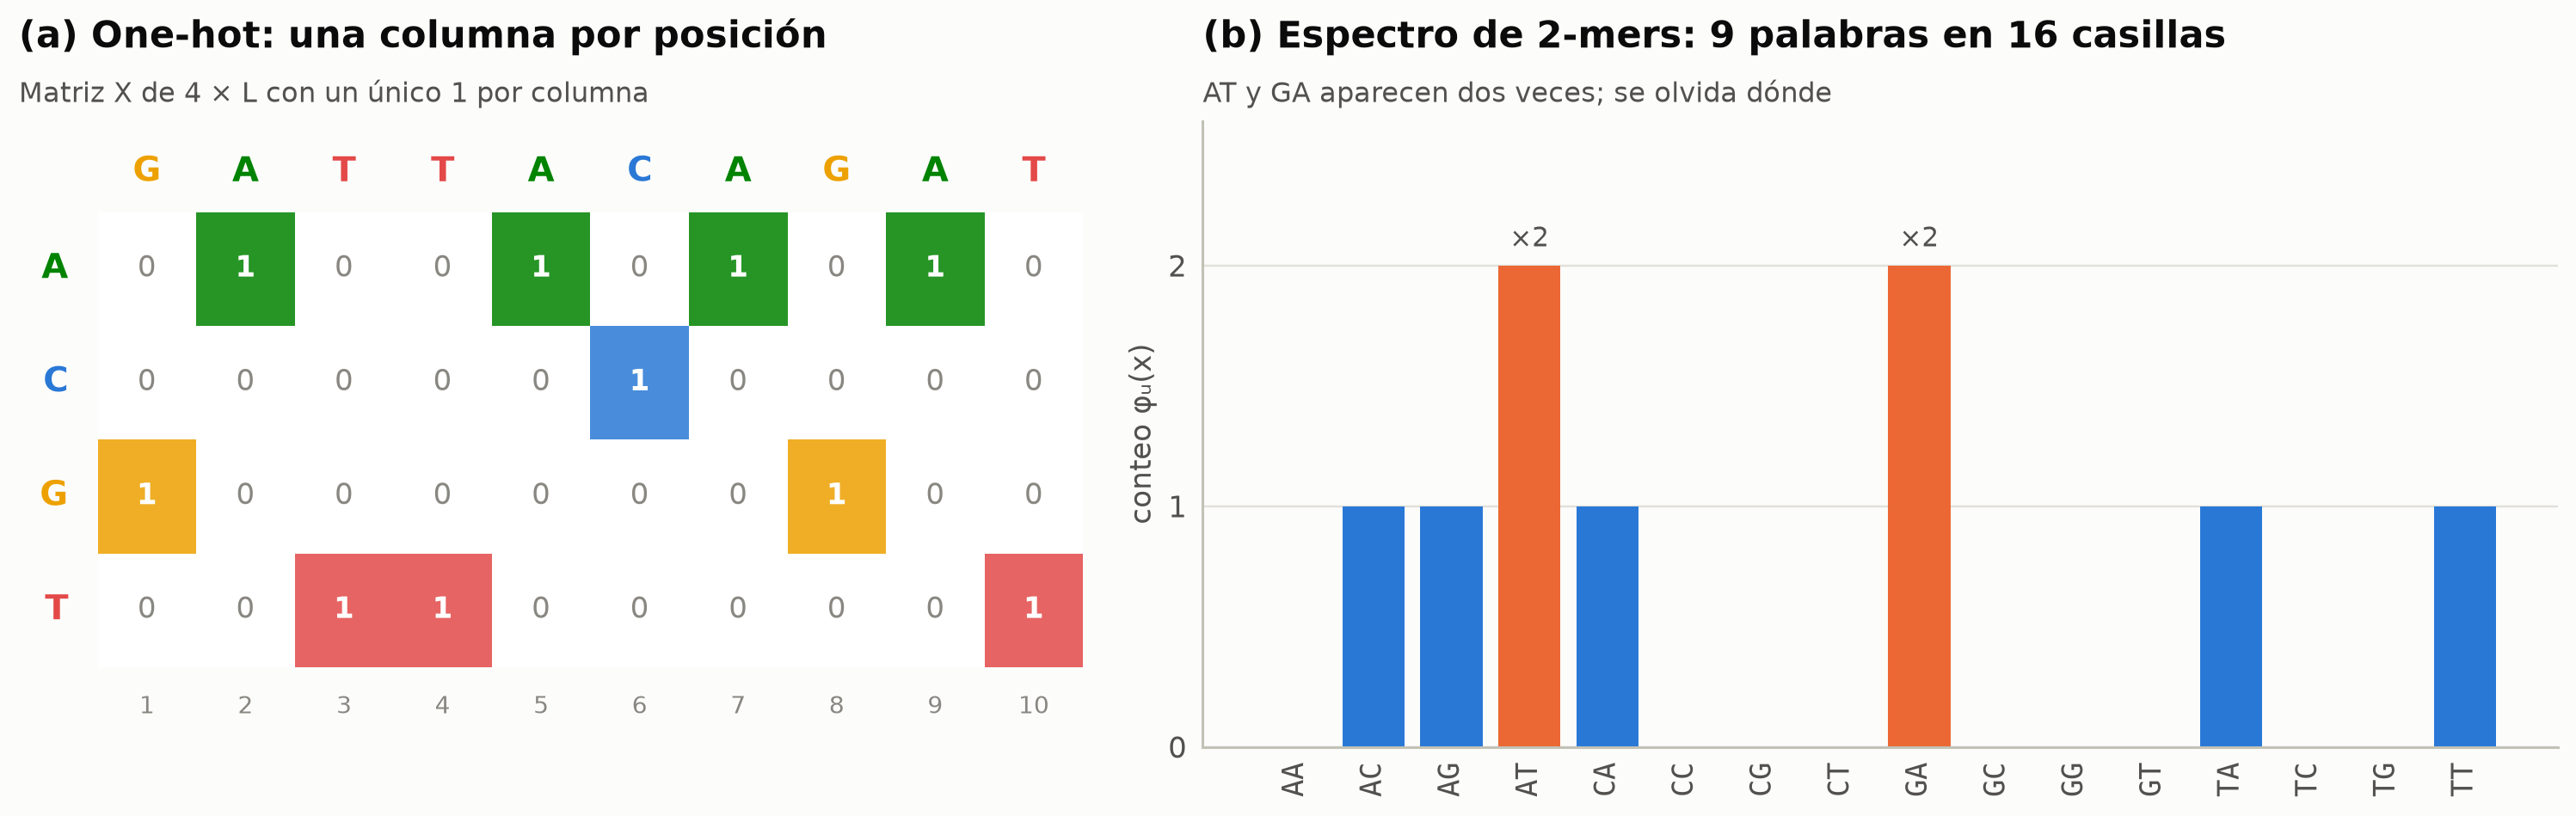

In [4]:
x_seq, y_seq = "GATTACAGAT", "TACAGATTAC"      # las secuencias del libro
Xoh = np.array([[b == c for b in x_seq] for c in "ACGT"], int)
fx, fy = spectrum(x_seq, 2), spectrum(y_seq, 2)
print("one-hot de", x_seq); print(pd.DataFrame(Xoh, index=list("ACGT"), columns=range(1, 11)))
print("\nΦ2(x) no nulos:", {u: int(c) for u, c in zip(kmers(2), fx) if c})

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2), gridspec_kw=dict(width_ratios=[1, 1.25]))
ax = axes[0]
for r, base in enumerate("ACGT"):
    for i, b in enumerate(x_seq):
        on = b == base
        ax.add_patch(Rectangle((i, 3 - r), 1, 1, facecolor=ec.NUC_COLORS[base] if on else "white",
                               edgecolor=ec.GRID, alpha=0.85 if on else 1))
        ax.text(i + 0.5, 3.5 - r, "1" if on else "0", ha="center", va="center",
                color="white" if on else ec.MUTED, fontweight="bold" if on else "normal")
    ax.text(-0.3, 3.5 - r, base, ha="right", va="center", fontweight="bold", color=ec.NUC_COLORS[base], fontsize=13)
for i, b in enumerate(x_seq):
    ax.text(i + 0.5, 4.35, b, ha="center", va="center", fontweight="bold", color=ec.NUC_COLORS[b], fontsize=13)
    ax.text(i + 0.5, -0.35, str(i + 1), ha="center", va="center", color=ec.MUTED, fontsize=9)
ax.set_xlim(-0.8, 10.2); ax.set_ylim(-0.7, 4.8); ax.axis("off")
ec.title(ax, "(a) One-hot: una columna por posición", "Matriz X de 4 × L con un único 1 por columna")
ax = axes[1]
cols = [ec.ORANGE if c == 2 else ec.BLUE for c in fx]
ax.bar(range(16), fx, color=cols)
ax.set_xticks(range(16), kmers(2), rotation=90, family="monospace")
ax.set_ylabel("conteo φᵤ(x)"); ax.set_yticks([0, 1, 2]); ax.set_ylim(0, 2.6)
for i, c in enumerate(fx):
    if c == 2:
        ax.text(i, c + 0.08, "×2", ha="center", fontsize=10, color=ec.INK_2)
ec.title(ax, "(b) Espectro de 2-mers: 9 palabras en 16 casillas", "AT y GA aparecen dos veces; se olvida dónde")
plt.show()

> 🔎 **Qué observamos.** Es la figura 17.1 del libro. La matriz *one-hot* sabe que la `T` está en las posiciones 3, 4
> y 10; el espectro sólo sabe que `AT` aparece dos veces. Por eso dos secuencias que son permutaciones de bloques pueden
> tener espectros casi idénticos, como veremos enseguida.

### 2.3 Las dos representaciones en los datos reales

En los promotores de *E. coli*, todas las secuencias están alineadas en el inicio de la transcripción (+1). Si
promediamos la matriz *one-hot* de los promotores y le restamos la de los no promotores, cada casilla dice «cuánto
más frecuente es esta base en esta posición en un promotor». Es la misma idea que las matrices de pesos posicionales
(PWM) del Módulo 4.

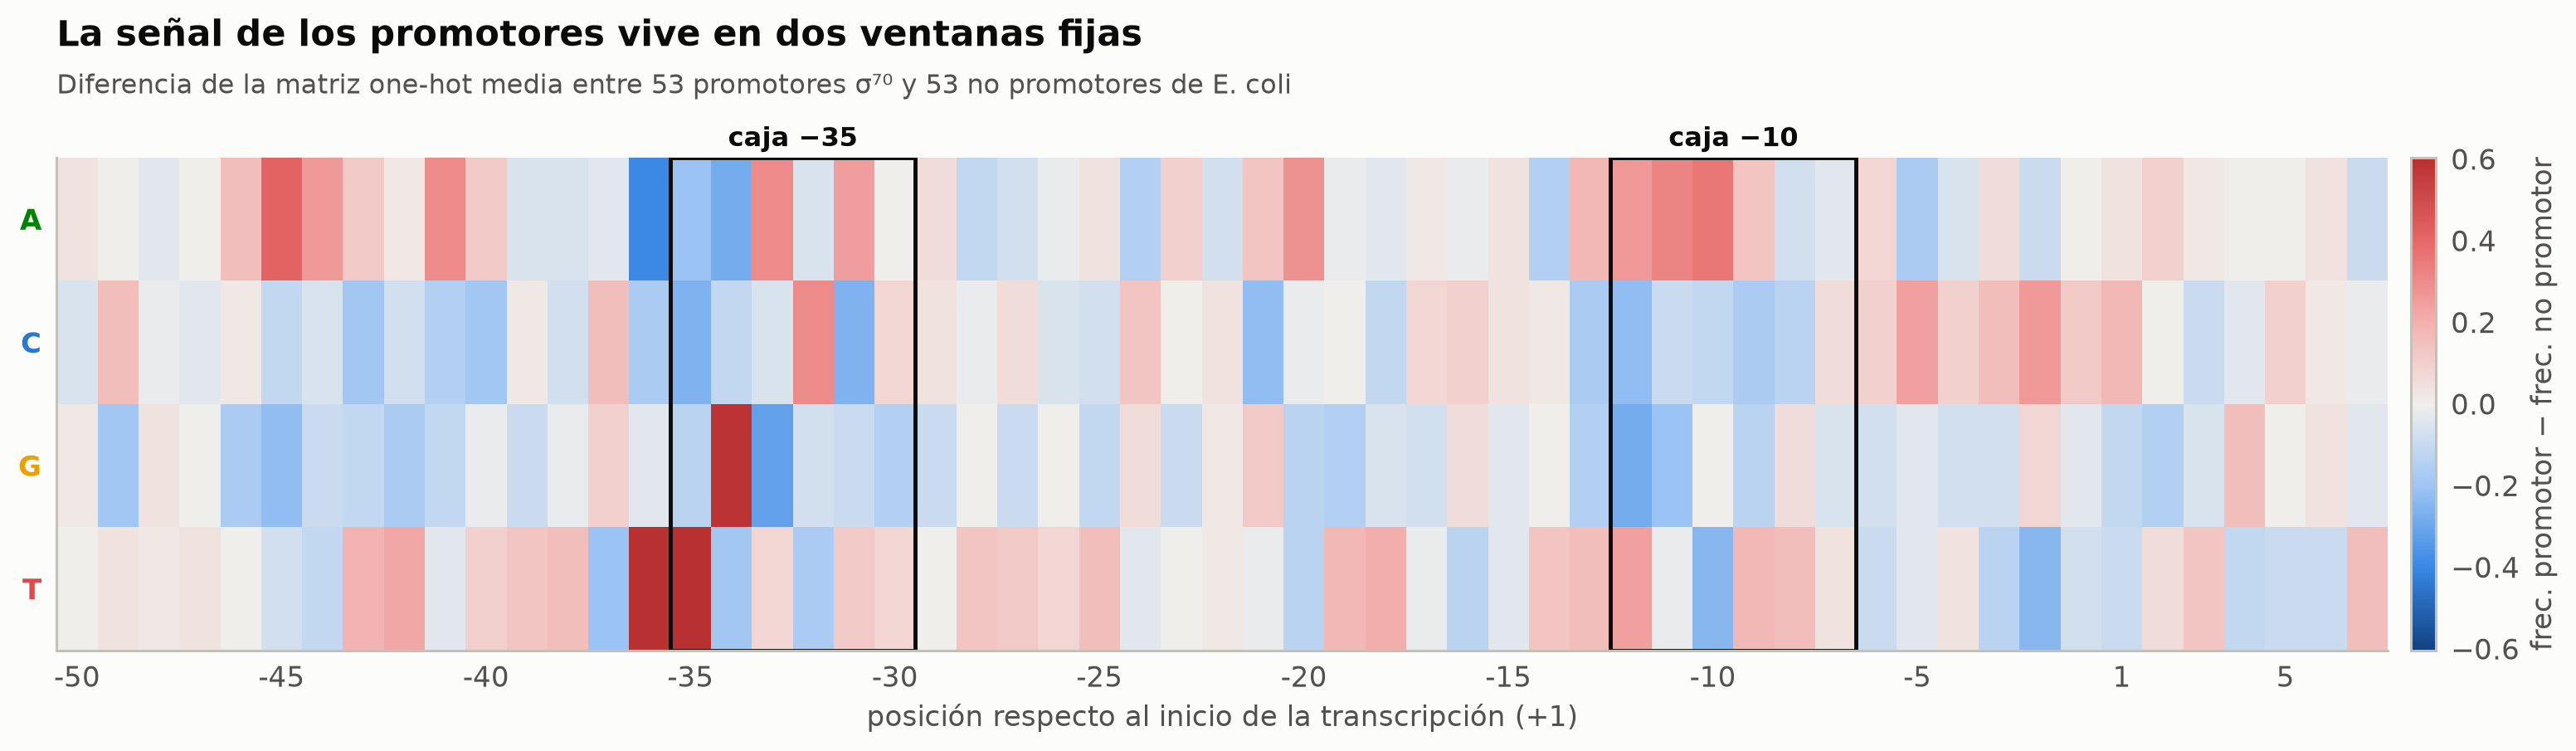

In [5]:
def onehot(s):
    return np.array([[c == b for c in s] for b in "ACGT"], float)

OH = np.array([onehot(s) for s in prom_seqs])                 # (106, 4, 57)
diff = OH[y_prom == 1].mean(0) - OH[y_prom == 0].mean(0)
fig, ax = plt.subplots(figsize=(14, 4.0))
lim = np.abs(diff).max()
im = ax.imshow(diff, cmap=ec.CMAP_DIV, vmin=-lim, vmax=lim, aspect="auto")
ax.set_yticks(range(4), list("ACGT"))
for t, b in zip(ax.get_yticklabels(), "ACGT"):
    t.set_color(ec.NUC_COLORS[b]); t.set_fontweight("bold")
ticks = [i for i, p in enumerate(POS_PROM) if p % 5 == 0 or p == 1]
ax.set_xticks(ticks, [str(POS_PROM[i]) for i in ticks])
ax.set_xlabel("posición respecto al inicio de la transcripción (+1)")
for lo, hi, lab in ((-35, -30, "caja −35"), (-12, -7, "caja −10")):
    i0, i1 = np.where(POS_PROM == lo)[0][0], np.where(POS_PROM == hi)[0][0]
    ax.add_patch(Rectangle((i0 - 0.5, -0.5), i1 - i0 + 1, 4, fill=False, ec=ec.INK, lw=1.6))
    ax.text((i0 + i1) / 2, 1.01, lab, ha="center", va="bottom", fontsize=10.5, fontweight="bold",
            transform=mpl.transforms.blended_transform_factory(ax.transData, ax.transAxes))
cb = plt.colorbar(im, ax=ax, pad=0.01); cb.set_label("frec. promotor − frec. no promotor")
ax.grid(False)
ax.set_title("La señal de los promotores vive en dos ventanas fijas", loc="left", pad=44)
ax.text(0, 1.13, "Diferencia de la matriz one-hot media entre 53 promotores σ⁷⁰ y 53 no promotores de E. coli",
        transform=ax.transAxes, fontsize=10.5, color=ec.INK_2)
plt.show()

> 🔎 **Qué observamos.** Dos bloques rojos saltan a la vista: `TTG` en −35/−33 y `TA…T` hacia −12/−7, las cajas −35 y
> −10 que reconoce la subunidad σ⁷⁰. Nadie le dijo al cálculo dónde buscar: bastó con alinear y promediar. Esta es la
> razón por la que la codificación *one-hot* funciona tan bien aquí, y fallaría con CTCF, cuyo motivo aparece en
> cualquier lugar de la ventana.

> ✅ **Compruebe su comprensión.** Si desplazáramos al azar cada promotor entre 0 y 5 posiciones, ¿qué pasaría con los
> dos bloques de la figura? ¿Y con el espectro de 3-mers de cada secuencia? (Los bloques se difuminarían, porque la
> caja caería en columnas distintas; el espectro apenas cambiaría, porque sólo cuenta palabras.)

## 3. El núcleo de espectro

Muchos algoritmos sólo necesitan saber **cuánto se parecen** dos secuencias, no sus coordenadas. Leslie, Eskin y
Noble (2002) definieron el **núcleo de espectro** como el producto interno de los espectros (ecuación 17.4):

$$
K_k(x,y) = \big\langle \Phi_k(x), \Phi_k(y)\big\rangle = \sum_{u\in\mathcal{A}^k} \phi_u(x)\,\phi_u(y),
\qquad
\tilde K_k(x,y) = \frac{K_k(x,y)}{\sqrt{K_k(x,x)\,K_k(y,y)}}.
$$

| Símbolo | Significado |
|---|---|
| $K_k(x,y)$ | Similitud entre $x$ e $y$: número de pares de $k$-mers idénticos que comparten |
| $\tilde K_k$ | Versión normalizada (coseno), entre 0 y 1; elimina el efecto de la longitud |

Su gracia computacional es que se calcula en tiempo lineal en la longitud recorriendo sólo los $k$-mers presentes (con
un árbol de sufijos o una tabla *hash*), sin construir nunca los vectores de dimensión $|\mathcal{A}|^k$. Combinado con
una SVM, obtuvo en la detección de homología remota de proteínas (SCOP) resultados comparables a métodos mucho más
costosos.

### Ejemplo del libro: «Núcleo de espectro a mano»

Sean $x=$ `GATTACAGAT` e $y=$ `TACAGATTAC`, con $k=2$. Los espectros (sólo componentes no nulas) son

| | AC | AG | AT | CA | GA | TA | TT |
|---|---|---|---|---|---|---|---|
| $\Phi_2(x)$ | 1 | 1 | 2 | 1 | 2 | 1 | 1 |
| $\Phi_2(y)$ | 2 | 1 | 1 | 1 | 1 | 2 | 1 |
| producto | 2 | 1 | 2 | 1 | 2 | 2 | 1 |

El producto interno es $K_2(x,y)=1\cdot2+1\cdot1+2\cdot1+1\cdot1+2\cdot1+1\cdot2+1\cdot1=11$, y como
$K_2(x,x)=K_2(y,y)=13$, el núcleo normalizado vale $\tilde K_2 = 11/13 \approx 0{,}846$. Sin embargo, $x$ e $y$ alineadas
sin huecos coinciden en sólo 2 de 10 posiciones: el núcleo de espectro ve que ambas están hechas de los mismos
«ladrillos» (`TACAGAT` aparece en las dos), aunque desplazados.

> 🤔 **Antes de ejecutar, prediga.** ¿Cuánto vale $K_2(x,x)$? Pista: es la suma de los cuadrados de los conteos.

In [6]:
Kxy, Kxx, Kyy = fx @ fy, fx @ fx, fy @ fy
Kn = Kxy / math.sqrt(Kxx * Kyy)
ident = sum(a == b for a, b in zip(x_seq, y_seq))
print(f"K2(x,y) = {Kxy:.0f}   [libro: 11]")
print(f"K2(x,x) = {Kxx:.0f}, K2(y,y) = {Kyy:.0f}   [libro: 13, 13]")
print(f"K2 normalizado = {fmt(Kn, 4)}   [libro: 0,846]")
print(f"Posiciones idénticas sin desplazar: {ident} de {len(x_seq)}   [libro: 2 de 10]")

# El mismo cálculo sin construir el vector de 4^k componentes: diccionarios (tabla hash)
from collections import Counter
def spectrum_kernel(a, b, k):
    ca = Counter(a[i:i + k] for i in range(len(a) - k + 1))
    cb = Counter(b[i:i + k] for i in range(len(b) - k + 1))
    return sum(v * cb[u] for u, v in ca.items())
for k in (1, 2, 3, 4, 5):
    kn = spectrum_kernel(x_seq, y_seq, k) / math.sqrt(spectrum_kernel(x_seq, x_seq, k) * spectrum_kernel(y_seq, y_seq, k))
    print(f"k = {k}:  K normalizado = {fmt(kn)}")

K2(x,y) = 11   [libro: 11]
K2(x,x) = 13, K2(y,y) = 13   [libro: 13, 13]
K2 normalizado = 0,8462   [libro: 0,846]
Posiciones idénticas sin desplazar: 2 de 10   [libro: 2 de 10]
k = 1:  K normalizado = 0,967
k = 2:  K normalizado = 0,846
k = 3:  K normalizado = 0,900
k = 4:  K normalizado = 1,000
k = 5:  K normalizado = 0,833


> 🔎 **Qué observamos.** Con $k=1$ el núcleo sólo compara composición (0,967: las dos secuencias tienen casi las mismas
> bases). Y aparece una sorpresa: con $k=4$ el núcleo vale **exactamente 1**. Las dos secuencias tienen el mismo
> espectro de 4-mers (`ACAG`, `AGAT`, `ATTA`, `CAGA`, `GATT`, `TACA`, `TTAC`) aunque son distintas: son permutaciones de
> los mismos bloques, justo la debilidad que anunciaba la figura. Con $k=5$ vuelve a bajar porque ya hay palabras que
> cruzan el punto de corte. $k$ es un hiperparámetro: demasiado pequeño y todo se parece; demasiado grande y nada se
> parece.

### El núcleo de espectro en CTCF

¿Se parecen más entre sí dos sitios de CTCF que un sitio y una ventana de fondo? Calculemos $\tilde K_6$ entre 300
sitios y 300 ventanas de fondo con `CountVectorizer` (que construye el espectro de forma dispersa) y una normalización
por filas: el producto de dos filas normalizadas es exactamente $\tilde K_k$.

dimensión del espectro de 6-mers: 3990 palabras presentes de 4^6 = 4096
media K~6  sitio-sitio = 0,035, fondo-fondo = 0,034, sitio-fondo = 0,029


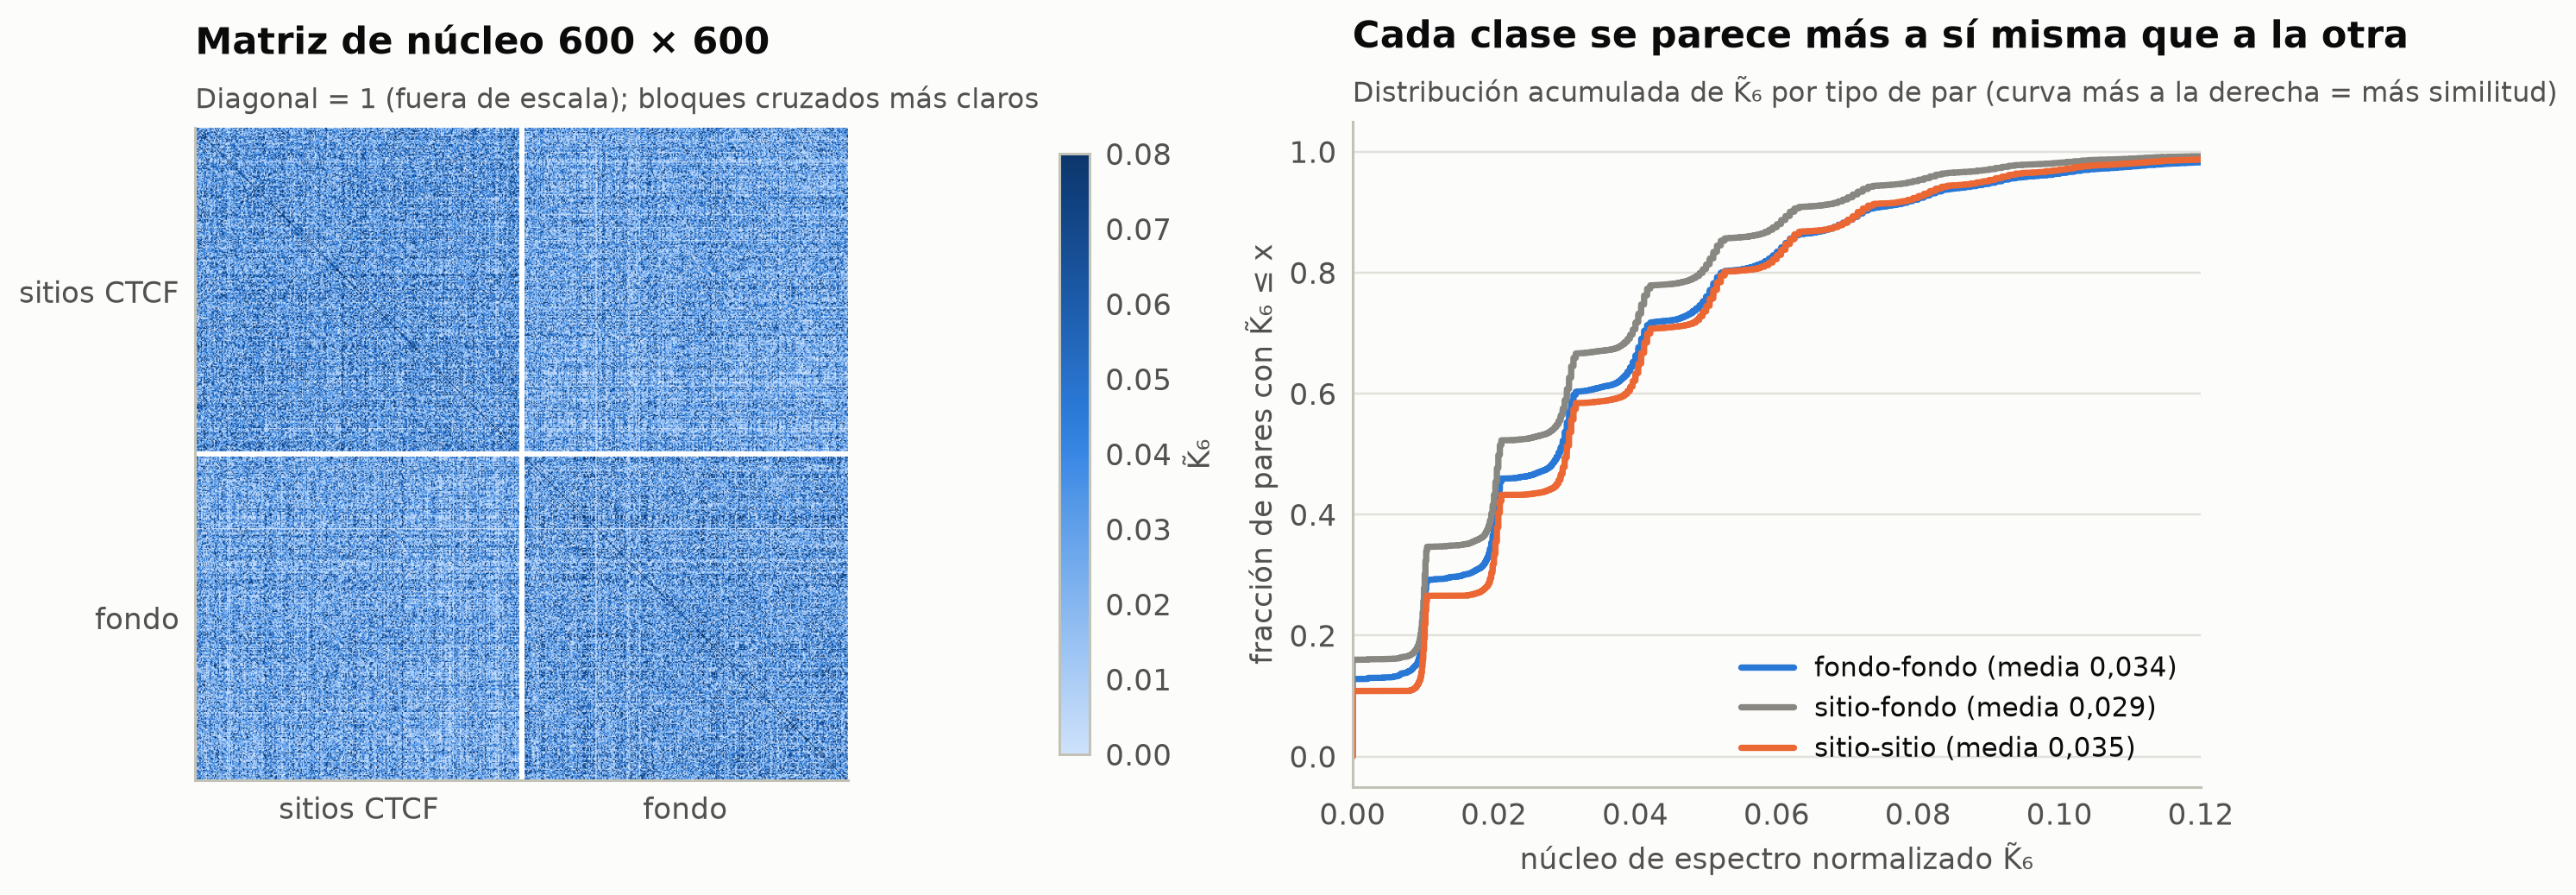

In [7]:
rng = np.random.default_rng(171)                  # semilla propia de la lección (no la del libro)
ip = rng.choice(len(ctcf_pos), 300, replace=False); ineg = rng.choice(len(ctcf_neg), 300, replace=False)
sub = [ctcf_pos[i] for i in ip] + [ctcf_neg[i] for i in ineg]
Phi6 = CountVectorizer(analyzer="char", ngram_range=(6, 6), lowercase=False).fit_transform(sub)
Kt = (normalize(Phi6.astype(float)) @ normalize(Phi6.astype(float)).T).toarray()
iu = np.triu_indices(300, 1)
pp, nn_ = Kt[:300, :300][iu], Kt[300:, 300:][iu]; pn = Kt[:300, 300:].ravel()
print(f"dimensión del espectro de 6-mers: {Phi6.shape[1]} palabras presentes de 4^6 = 4096")
print(f"media K~6  sitio-sitio = {fmt(pp.mean())}, fondo-fondo = {fmt(nn_.mean())}, sitio-fondo = {fmt(pn.mean())}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw=dict(width_ratios=[1, 1.3]))
ax = axes[0]
im = ax.imshow(Kt, cmap=ec.CMAP_SEQ, vmin=0, vmax=0.08); ax.grid(False)
ax.axhline(299.5, color="white", lw=2); ax.axvline(299.5, color="white", lw=2)
ax.set_xticks([150, 450], ["sitios CTCF", "fondo"]); ax.set_yticks([150, 450], ["sitios CTCF", "fondo"])
plt.colorbar(im, ax=ax, fraction=0.046, label="K̃₆")
ec.title(ax, "Matriz de núcleo 600 × 600", "Diagonal = 1 (fuera de escala); bloques cruzados más claros")
ax = axes[1]
for v, lab, col in ((nn_, "fondo-fondo", ec.BLUE), (pn, "sitio-fondo", ec.MUTED), (pp, "sitio-sitio", ec.ORANGE)):
    vs = np.sort(v)
    ax.plot(vs, np.arange(1, len(vs) + 1) / len(vs), color=col, lw=2.4, label=f"{lab} (media {fmt(v.mean())})")
ax.set_xlim(0, 0.12)
ax.set_xlabel("núcleo de espectro normalizado K̃₆"); ax.set_ylabel("fracción de pares con K̃₆ ≤ x")
ax.legend(frameon=False, loc="lower right")
ec.title(ax, "Cada clase se parece más a sí misma que a la otra",
         "Distribución acumulada de K̃₆ por tipo de par (curva más a la derecha = más similitud)")
plt.show()

> 🔎 **Qué observamos.** Los pares sitio-sitio y fondo-fondo se parecen más entre sí que los pares mixtos sitio-fondo:
> cada clase tiene sus propios «ladrillos» (los sitios, trozos del motivo `CCGCGNGGNGGCAG` y un entorno rico en GC; el
> fondo, palabras ricas en A/T y repeticiones). La diferencia es modesta, porque de las 95 palabras de cada ventana sólo
> una docena caen en el motivo, y la mayoría de los pares no comparte casi nada. Un clasificador que use esta similitud,
> como la SVM de la sección 5, tendrá que aprovechar diferencias sutiles pero sistemáticas.

## 4. Regresión logística: el clasificador lineal probabilístico

### 4.1 Intuición: una suma de votos que se convierte en probabilidad

Imagine a un médico que decide si un lunar es sospechoso sumando puntos: +2 si es asimétrico, +1 si tiene bordes
irregulares, −1 si es pequeño. La suma puede ser cualquier número; para convertirla en una probabilidad hace falta
«aplastarla» al intervalo $(0,1)$. La regresión logística hace exactamente eso con la función **sigmoide**
(ecuación 17.5):

$$
p(\mathbf{x}) = \Pr(y=1\mid\mathbf{x}) = \sigma(\mathbf{w}^{\top}\mathbf{x}+b),\qquad \sigma(z)=\frac{1}{1+e^{-z}}.
$$

| Símbolo | Significado |
|---|---|
| $\mathbf{w},\ b$ | Vector de pesos (uno por atributo) y término independiente (sesgo) |
| $z=\mathbf{w}^{\top}\mathbf{x}+b$ | Puntuación lineal o *logit*; vale $\log\frac{p}{1-p}$, el logaritmo de las probabilidades a favor |
| $\sigma(z)$ | Sigmoide logística: convierte cualquier real en una probabilidad |

**A mano.** $\sigma(0)=0{,}5$; $\sigma(\ln 9)=9/10=0{,}9$; $\sigma(-\ln 9)=0{,}1$. Cada unidad de $z$ multiplica las
probabilidades a favor ($p/(1-p)$) por $e\approx2{,}72$.

El *logit* conecta con algo conocido: $z$ es un logaritmo de razón de probabilidades, igual que las puntuaciones de las
matrices de sustitución (Módulo 3) o de las PWM (Módulo 4). Cada peso $w_j$ dice cuánto aumenta el logaritmo de las
probabilidades a favor de la clase 1 por cada unidad adicional del atributo $j$.

### 4.2 De la verosimilitud a la entropía cruzada

Si las etiquetas son independientes y cada una sigue una Bernoulli con parámetro $p_i=p(\mathbf{x}_i)$, la verosimilitud
es $\prod_i p_i^{y_i}(1-p_i)^{1-y_i}$. Maximizarla equivale a minimizar el negativo de su logaritmo promediado, la
**entropía cruzada binaria** (ecuación 17.6):

$$
\mathcal{L}(\mathbf{w},b) = -\frac{1}{n}\sum_{i=1}^{n}\Big[\,y_i\log p_i + (1-y_i)\log(1-p_i)\,\Big].
$$

| Símbolo | Significado |
|---|---|
| $\mathcal{L}$ | Pérdida media (en nats); vale $\ln 2\approx0{,}693$ para un clasificador que siempre dice $p=0{,}5$ |
| $p_i$ | Probabilidad predicha para la secuencia $i$ |

La entropía cruzada castiga con dureza la **confianza equivocada**: decir $p=0{,}01$ a un positivo cuesta
$-\ln 0{,}01\approx4{,}6$ nats, mientras que decir $p=0{,}5$ cuesta sólo 0,69.

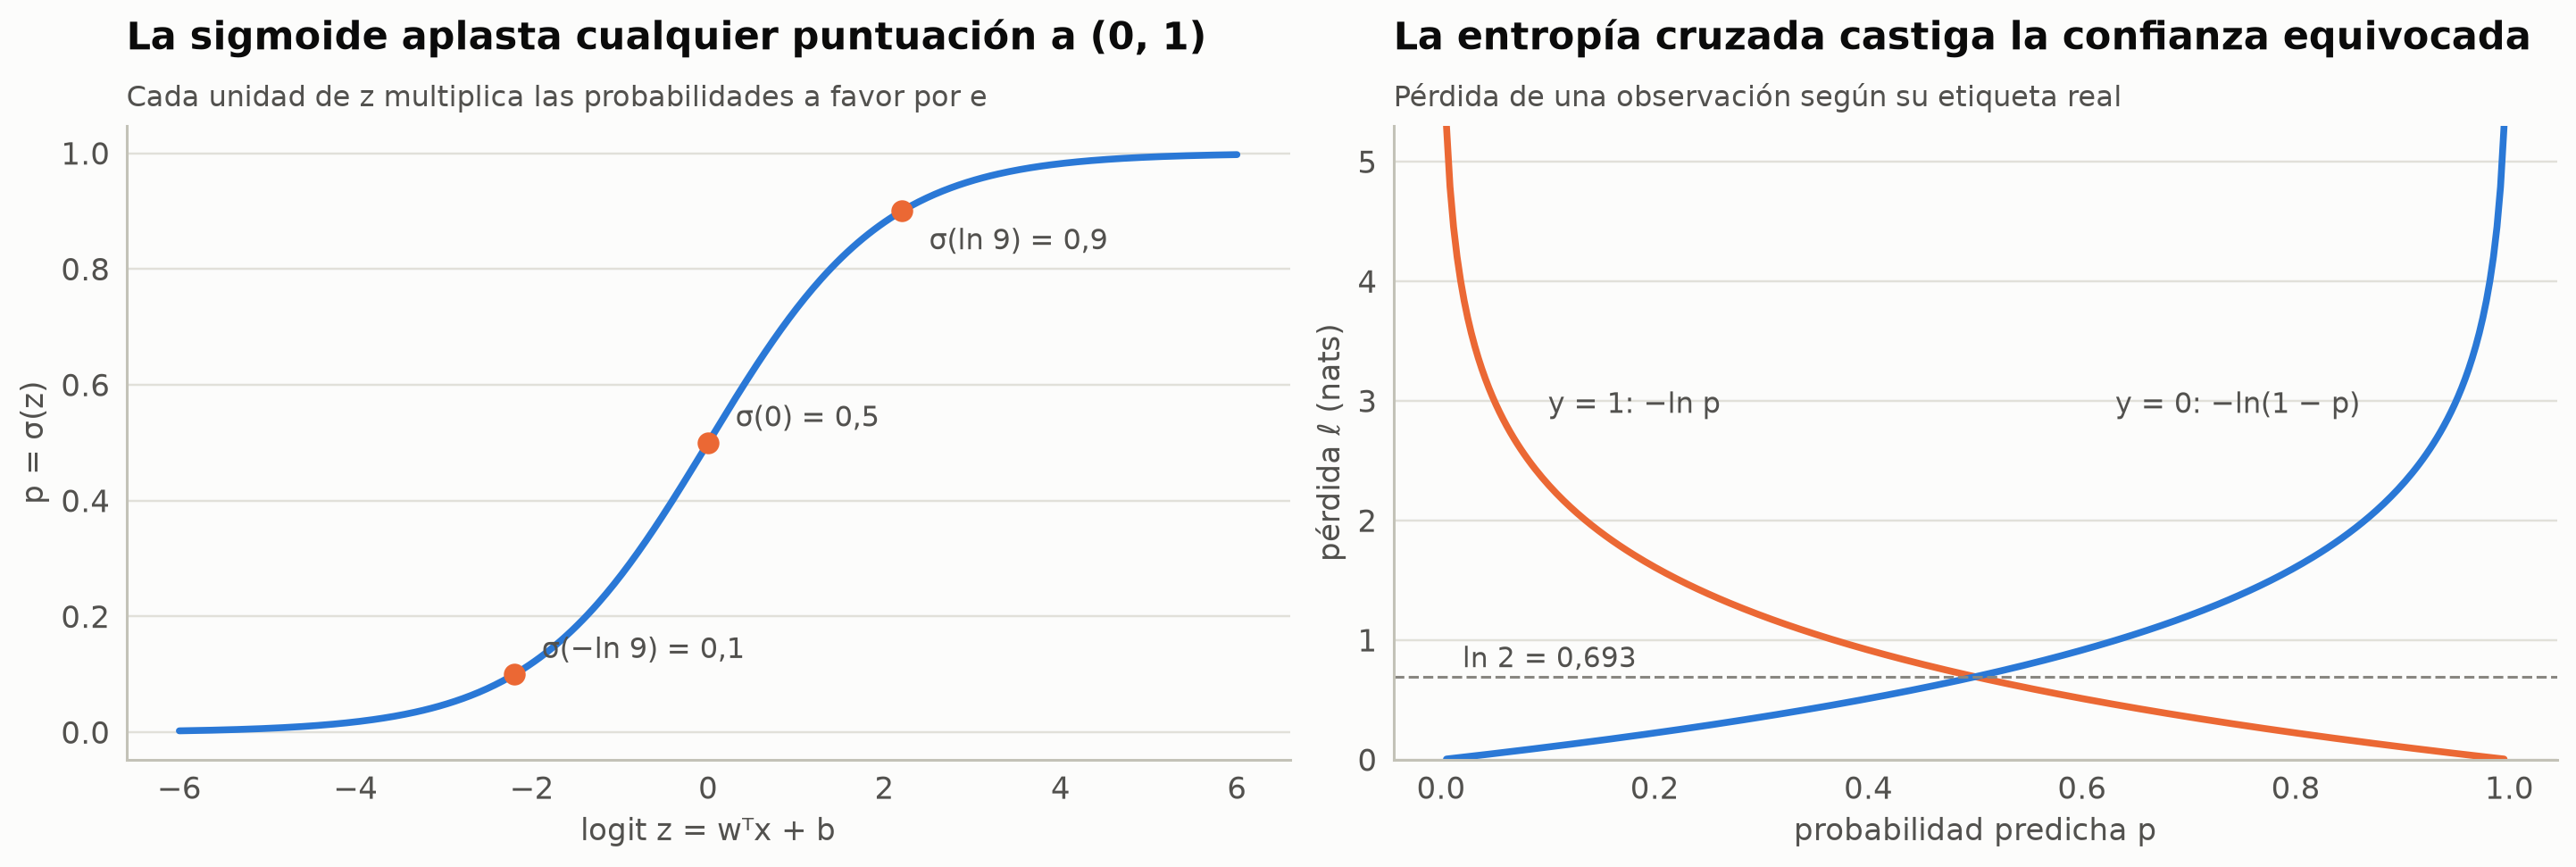

In [8]:
z = np.linspace(-6, 6, 400)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
ax = axes[0]
ax.plot(z, sig(z), color=ec.BLUE, lw=2.5)
for zz, lab in ((0, "σ(0) = 0,5"), (np.log(9), "σ(ln 9) = 0,9"), (-np.log(9), "σ(−ln 9) = 0,1")):
    ax.plot(zz, sig(zz), "o", color=ec.ORANGE, ms=7)
    ax.annotate(lab, (zz, sig(zz)), xytext=(10, -14 if zz > 0 else 6), textcoords="offset points", fontsize=10.5,
                color=ec.INK_2)
ax.set_xlabel("logit z = wᵀx + b"); ax.set_ylabel("p = σ(z)")
ec.title(ax, "La sigmoide aplasta cualquier puntuación a (0, 1)", "Cada unidad de z multiplica las probabilidades a favor por e")
ax = axes[1]
p = np.linspace(0.005, 0.995, 300)
ax.plot(p, -np.log(p), color=ec.ORANGE, lw=2.5); ax.plot(p, -np.log(1 - p), color=ec.BLUE, lw=2.5)
ax.text(0.1, 2.9, "y = 1: −ln p", fontsize=10.5, color=ec.INK_2)
ax.text(0.86, 2.9, "y = 0: −ln(1 − p)", ha="right", fontsize=10.5, color=ec.INK_2)
ax.axhline(np.log(2), color=ec.MUTED, ls="--", lw=1); ax.text(0.02, np.log(2) + 0.08, "ln 2 = 0,693", ha="left",
                                                               fontsize=10, color=ec.INK_2)
ax.set_xlabel("probabilidad predicha p"); ax.set_ylabel("pérdida ℓ (nats)"); ax.set_ylim(0, 5.3)
ec.title(ax, "La entropía cruzada castiga la confianza equivocada", "Pérdida de una observación según su etiqueta real")
plt.show()

### 4.3 Derivación del gradiente

No existe una fórmula cerrada para el mínimo de $\mathcal{L}$, pero su gradiente es sorprendentemente simple. Tomemos
una sola observación, $\ell = -[y\log p + (1-y)\log(1-p)]$ con $p=\sigma(z)$ y $z=\mathbf{w}^\top\mathbf{x}+b$. Por la
regla de la cadena,

$$
\frac{\partial \ell}{\partial w_j} = \frac{\partial \ell}{\partial p}\cdot\frac{\partial p}{\partial z}\cdot\frac{\partial z}{\partial w_j}.
$$

Los tres factores son:

1. $\dfrac{\partial\ell}{\partial p} = -\dfrac{y}{p} + \dfrac{1-y}{1-p} = \dfrac{p-y}{p(1-p)}$;
2. la derivada de la sigmoide, que cumple la identidad $\sigma'(z)=\sigma(z)\,[1-\sigma(z)] = p(1-p)$;
3. $\dfrac{\partial z}{\partial w_j} = x_j$.

Al multiplicarlos, el factor $p(1-p)$ **se cancela**. Resultado (teorema 17.1 del libro, ecuación 17.7):

$$
\nabla_{\mathbf{w}}\mathcal{L} = \frac{1}{n}\sum_{i=1}^{n}(p_i - y_i)\,\mathbf{x}_i,\qquad
\frac{\partial\mathcal{L}}{\partial b} = \frac{1}{n}\sum_{i=1}^{n}(p_i-y_i).
$$

Además $\mathcal{L}$ es **convexa** en $(\mathbf{w},b)$: cualquier mínimo local es global, como un cuenco sin
hondonadas falsas.

| Símbolo | Significado |
|---|---|
| $p_i-y_i$ | Error de predicción (residuo) de la observación $i$: positivo si el modelo sobreestima |
| $\nabla_{\mathbf{w}}\mathcal{L}$ | Vector de derivadas parciales de la pérdida respecto a cada peso |

Cada observación «empuja» los pesos en la dirección de sus atributos, con una fuerza proporcional a cuánto se
equivocó; las secuencias bien clasificadas ($p_i\approx y_i$) casi no contribuyen. El **descenso por gradiente** itera
(ecuación 17.8)

$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta\,\nabla_{\mathbf{w}}\mathcal{L}\big(\mathbf{w}^{(t)}\big),
$$

| Símbolo | Significado |
|---|---|
| $\eta$ | Tasa de aprendizaje (tamaño del paso) |
| $t$ | Número de iteración |

y, en la práctica, se añade una penalización $\Omega=\tfrac12\|\mathbf{w}\|^2$ (regularización $L_2$) que evita que los
pesos crezcan sin límite cuando los datos son separables y, con miles de $k$-mers como atributos, reduce el
sobreajuste. El gradiente simplemente gana un término $\lambda\mathbf{w}$.

### 4.4 Ejemplo del libro: «Un paso de descenso por gradiente»

Cuatro secuencias se describen con dos atributos: $x_1$, número de copias de un motivo, y $x_2$, número de
dinucleótidos CpG. Los datos son $(2,1)$, $(1,0)$, $(0,1)$ y $(0,0)$, con etiquetas $1, 1, 0, 0$. Partimos de
$\mathbf{w}=\mathbf{0}$, $b=0$, así que $p_i=\sigma(0)=0{,}5$ para todas y $\mathcal{L}=\ln 2 = 0{,}6931$. Los residuos
son $p-y=(-0{,}5,\,-0{,}5,\,0{,}5,\,0{,}5)$ y

$$
\frac{\partial\mathcal{L}}{\partial w_1} = \tfrac14\big[(-0{,}5)(2)+(-0{,}5)(1)+0+0\big] = -0{,}375,\qquad
\frac{\partial\mathcal{L}}{\partial w_2} = \tfrac14\big[(-0{,}5)(1)+0+(0{,}5)(1)+0\big] = 0,\qquad
\frac{\partial\mathcal{L}}{\partial b} = 0.
$$

Con $\eta=1$, los nuevos parámetros son $w_1=0{,}375$, $w_2=0$, $b=0$. Las probabilidades pasan a
$\sigma(0{,}75)=0{,}679$, $\sigma(0{,}375)=0{,}593$, $0{,}5$ y $0{,}5$, y la pérdida baja a $0{,}5741$. El modelo aprendió
en un paso que el motivo discrimina y que los CpG, en este ejemplo, no aportan nada: aparecen igual en una secuencia
positiva y en una negativa.

> 🤔 **Antes de ejecutar, prediga.** Si diéramos un segundo paso, ¿seguiría $w_2$ en cero? (Piense en los nuevos
> residuos de las secuencias $(2,1)$ y $(0,1)$.)

In [9]:
Xs = np.array([[2, 1], [1, 0], [0, 1], [0, 0]], float)       # (motivos, CpG)
ys = np.array([1, 1, 0, 0], float)
Xb = np.c_[np.ones(4), Xs]                                    # columna de unos para b
wv = np.zeros(3)                                              # (b, w1, w2)
p0 = sig(Xb @ wv)
L0 = -np.mean(ys * np.log(p0) + (1 - ys) * np.log(1 - p0))
g = Xb.T @ (p0 - ys) / 4
w1 = wv - 1.0 * g
p1 = sig(Xb @ w1)
L1 = -np.mean(ys * np.log(p1) + (1 - ys) * np.log(1 - p1))
print("gradiente (b, w1, w2):", g.round(4), "  [libro: (0, −0,375, 0)]")
print("parámetros tras un paso:", w1.round(4), "  [libro: (0, 0,375, 0)]")
print("probabilidades:", p1.round(3), "  [libro: 0,679 0,593 0,5 0,5]")
print(f"pérdida: {fmt(L0, 4)} → {fmt(L1, 4)}   [libro: 0,6931 → 0,5741]")

# segundo paso (respuesta a la predicción)
g2 = Xb.T @ (p1 - ys) / 4
print("\nsegundo gradiente (b, w1, w2):", g2.round(4), "→ w2 deja de ser cero:", (w1 - g2).round(4))

gradiente (b, w1, w2): [ 0.    -0.375  0.   ]   [libro: (0, −0,375, 0)]
parámetros tras un paso: [0.    0.375 0.   ]   [libro: (0, 0,375, 0)]
probabilidades: [0.679 0.593 0.5   0.5  ]   [libro: 0,679 0,593 0,5 0,5]
pérdida: 0,6931 → 0,5741   [libro: 0,6931 → 0,5741]

segundo gradiente (b, w1, w2): [ 0.068  -0.2622  0.0448] → w2 deja de ser cero: [-0.068   0.6372 -0.0448]


> 🔎 **Qué observamos.** Las cifras coinciden con el libro. En el segundo paso $w_2$ ya no es cero: la secuencia
> positiva $(2,1)$ está mejor predicha ($p=0{,}679$) que la negativa $(0,1)$ ($p=0{,}5$), así que sus empujones sobre
> $w_2$ ya no se cancelan y el modelo empieza a asignar un peso **negativo** a los CpG. El gradiente sólo mira residuos.

### 4.5 Descenso por gradiente en movimiento

Ahora programamos el algoritmo completo y lo aplicamos a los datos de la figura de fronteras del libro: 70 regiones
«de fondo» y 70 promotores con isla CpG, descritos por su contenido de GC y su razón CpG observada/esperada. Usamos la
misma semilla del libro (`default_rng(17)`), cuyo generador reservamos sólo para reproducir sus figuras en el mismo
orden que `generar.py`. Estandarizamos los atributos (media 0, desviación 1), lo que hace que el cuenco de la pérdida
sea redondo y el descenso avance sin zigzaguear.

In [10]:
rng_libro = np.random.default_rng(17)     # generador del libro: frontera → fuga → ROC/PR, en ese orden
n = 70
gc0 = rng_libro.normal(0.44, 0.055, n); oe0 = rng_libro.normal(0.36, 0.12, n)
gc1 = rng_libro.normal(0.56, 0.055, n); oe1 = rng_libro.normal(0.66, 0.14, n)
F = np.c_[np.r_[gc0, gc1], np.r_[oe0, oe1]]
yF = np.r_[np.zeros(n), np.ones(n)].astype(int)
mu, sd = F.mean(0), F.std(0)
Z = (F - mu) / sd

def raw_line(wz, bz, level, x1):
    """Recta wᵀz + b = level (en unidades estandarizadas) expresada en unidades originales (función del libro)."""
    a = wz / sd
    c = bz - np.sum(wz * mu / sd)
    return (level - c - a[0] * x1) / a[1]

def gd_logistic(X, y, eta=0.5, steps=200, lam=0.0):
    """Descenso por gradiente de la regresión logística (ecs. 17.7 y 17.8), con L2 opcional."""
    w, b = np.zeros(X.shape[1]), 0.0
    hist = []
    for t in range(steps + 1):
        p = sig(X @ w + b)
        loss = -np.mean(y * np.log(p + 1e-12) + (1 - y) * np.log(1 - p + 1e-12)) + lam / 2 * w @ w
        hist.append((t, w.copy(), b, loss, np.mean((p > 0.5) == y)))
        gw = X.T @ (p - y) / len(y) + lam * w
        gb = np.mean(p - y)
        w, b = w - eta * gw, b - eta * gb
    return hist

hist = gd_logistic(Z, yF, eta=0.5, steps=300)
lr_sk = LogisticRegression(C=1e6, max_iter=10000).fit(Z, yF)      # prácticamente sin regularizar
print("t = 300 (nuestro GD):", hist[-1][1].round(3), round(hist[-1][2], 3), " pérdida", fmt(hist[-1][3], 4))
print("scikit-learn (C=1e6):", lr_sk.coef_[0].round(3), round(lr_sk.intercept_[0], 3))

t = 300 (nuestro GD): [3.109 3.079] 0.177  pérdida 0,1438
scikit-learn (C=1e6): [3.599 3.577] 0.248


![Vista previa: cada paso de descenso por gradiente gira y desplaza la frontera p = 0,5 (línea negra) y estrecha la franja de incertidumbre entre p = 0,1 y p = 0,9, mientras la pérdida baja desde ln 2.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-17-machine-learning/17.1_descenso_frontera.gif)

*Vista previa: cada paso de descenso por gradiente gira y desplaza la frontera p = 0,5 (línea negra) y estrecha la franja de incertidumbre entre p = 0,1 y p = 0,9, mientras la pérdida baja desde ln 2.*

In [11]:
steps_show = sorted(set([0, 1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 18, 22, 26, 30, 35, 40, 50, 60, 75, 90, 110, 130,
                         160, 200, 250, 300]))
frames = steps_show + [300] * 5
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5), gridspec_kw=dict(width_ratios=[1.25, 1]))
ax = axes[0]
ax.scatter(gc0, oe0, s=22, color=ec.BLUE, alpha=0.8, label="fondo")
ax.scatter(gc1, oe1, s=30, marker="^", color=ec.ORANGE, alpha=0.85, label="promotor con isla CpG")
ax.set_xlim(0.28, 0.72); ax.set_ylim(0, 1.1)
ax.set_xlabel("contenido GC"); ax.set_ylabel("razón CpG obs./esp.")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, 0.92))
xs_ = np.array([0.28, 0.72])
l0, = ax.plot([], [], color=ec.INK, lw=2.4)
l1, = ax.plot([], [], color=ec.INK_2, lw=1.2, ls="--")
l2, = ax.plot([], [], color=ec.INK_2, lw=1.2, ls="--")
info = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top", fontsize=11.5, fontweight="bold")
ax.set_title("El descenso por gradiente gira la frontera", loc="left")
ax2 = axes[1]
tt = [h[0] for h in hist]; LL = [h[3] for h in hist]
ax2.plot(tt, LL, color=ec.GRID, lw=2)
trail, = ax2.plot([], [], color=ec.BLUE, lw=2.5)
dot, = ax2.plot([], [], "o", color=ec.ORANGE, ms=8)
ax2.axhline(np.log(2), color=ec.MUTED, ls=":", lw=1); ax2.text(300, np.log(2) + 0.01, "ln 2", ha="right", color=ec.INK_2)
ax2.set_xlabel("iteración t"); ax2.set_ylabel("pérdida ℒ (nats)"); ax2.set_ylim(0, 0.75)
ax2.set_title("…mientras la pérdida baja", loc="left")

def update(f):
    t = frames[f]
    _, w, b, loss, acc = hist[t]
    if np.abs(w[1]) < 1e-9:
        for l in (l0, l1, l2):
            l.set_data([], [])
    else:
        l0.set_data(xs_, raw_line(w, b, 0, xs_))
        l1.set_data(xs_, raw_line(w, b, np.log(9), xs_))
        l2.set_data(xs_, raw_line(w, b, -np.log(9), xs_))
    info.set_text(f"t = {t}   ·   ℒ = {loss:.3f}   ·   exactitud = {acc:.0%}".replace(".", ","))
    trail.set_data(tt[:t + 1], LL[:t + 1]); dot.set_data([t], [loss])
    return l0, l1, l2, info, trail, dot

update(0)
ec.animate(fig, update, frames=len(frames), interval=260, name="17.1_descenso_frontera")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** En $t=0$ no hay frontera: todos los puntos tienen $p=0{,}5$. El primer paso ya orienta la
> recta en la dirección correcta (casi todo el trabajo lo hace el gradiente inicial, igual que en el ejemplo de cuatro
> secuencias). Después la frontera apenas se mueve y lo que cambia es la **franja de incertidumbre** (trazos, $p=0{,}9$
> y $p=0{,}1$): a medida que los pesos crecen, la sigmoide se vuelve más empinada y el modelo más seguro. Sin
> regularización y con datos separables, esa franja se estrecharía sin fin; la penalización $L_2$ lo impide.

### 4.6 Caso real: los promotores de *E. coli* con *one-hot* y regresión logística

Con la matriz *one-hot* aplanada ($4\times57=228$ atributos), cada peso $w_{c,i}$ dice cuánto sube el *logit* por
tener la base $c$ en la posición $i$. Es una PWM **aprendida discriminativamente**. Con 106 secuencias y 228 atributos
la regularización es imprescindible. scikit-learn minimiza $C\sum_i\ell_i+\tfrac12\|\mathbf{w}\|^2$, que equivale a
nuestra pérdida media más $\tfrac{\lambda}{2}\|\mathbf{w}\|^2$ con $\lambda=1/(Cn)$. Comprobemos que nuestro descenso por
gradiente y scikit-learn llegan a los mismos pesos, y evaluemos con validación **dejando uno fuera** (LOO), como hicieron
Towell, Shavlik y Noordewier (1990) con este mismo conjunto.

In [12]:
X_prom = OH.reshape(len(prom_seqs), -1)            # orden: A(57) C(57) G(57) T(57)
C_prom = 0.1
lam = 1 / (C_prom * len(y_prom))
h_prom = gd_logistic(X_prom, y_prom, eta=2.0, steps=3000, lam=lam)
w_gd = h_prom[-1][1]
lr_prom = LogisticRegression(C=C_prom, max_iter=5000).fit(X_prom, y_prom)
print(f"correlación pesos GD vs scikit-learn: {np.corrcoef(w_gd, lr_prom.coef_[0])[0, 1]:.4f}")

t0 = time.time()
loo = cross_val_score(LogisticRegression(C=C_prom, max_iter=5000), X_prom, y_prom, cv=LeaveOneOut())
err = int(round(len(y_prom) * (1 - loo.mean())))
print(f"LOO: exactitud {fmt(loo.mean())} → {err}/106 errores  ({time.time() - t0:.1f} s)")
tabla = pd.DataFrame({"método": ["KBANN (red + reglas)", "retropropagación", "O'Neill (reglas de la literatura)",
                                 "3 vecinos más cercanos", "ID3 (árbol)", "regresión logística one-hot (esta lección)"],
                      "errores LOO de 106": [4, 8, 12, 13, 19, err]})
tabla

correlación pesos GD vs scikit-learn: 0.9821
LOO: exactitud 0,925 → 8/106 errores  (0.2 s)


,método,errores LOO de 106
0,KBANN (red + reglas),4
1,retropropagación,8
2,O'Neill (reglas de la literatura),12
3,3 vecinos más cercanos,13
4,ID3 (árbol),19
5,regresión logística one-hot (esta lección),8


> 🔎 **Qué observamos.** Nuestro descenso por gradiente de veinte líneas y scikit-learn encuentran prácticamente los
> mismos pesos (correlación ≈ 0,98; la pequeña diferencia se debe a que 3 000 pasos no bastan para converger del todo). Una regresión logística regularizada comete tantos errores como la red neuronal de 1990 y menos que
> las reglas escritas a mano por expertos. (Los errores de otros métodos son los que declaran los autores del conjunto
> en su documentación del repositorio UCI.) Ahora abramos la caja: ¿qué aprendió?

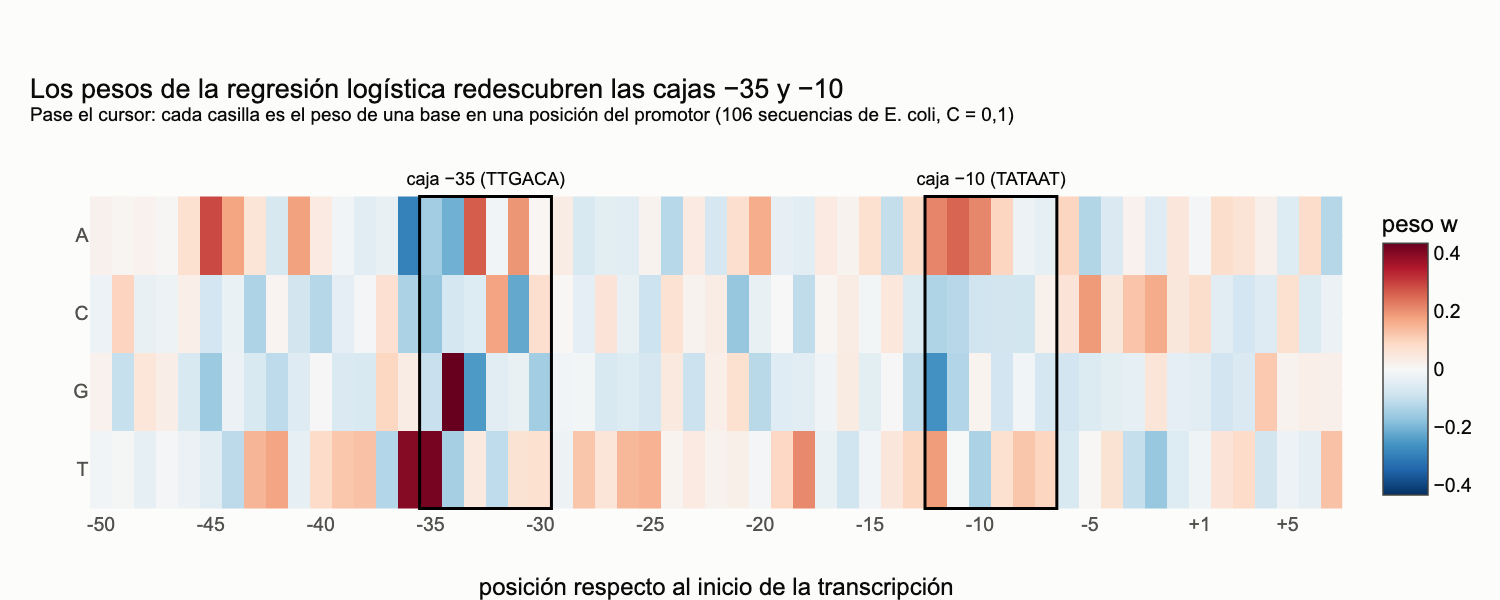

In [13]:
Wp = lr_prom.coef_[0].reshape(4, 57)
hover = []
for r, base in enumerate("ACGT"):
    row = []
    for i, pos_ in enumerate(POS_PROM):
        wv_ = Wp[r, i]
        caja = " (caja −35)" if -35 <= pos_ <= -30 else (" (caja −10)" if -12 <= pos_ <= -7 else "")
        row.append(f"<b>{base} en la posición {pos_:+d}</b>{caja}<br>peso w = {wv_:+.3f}<br>"
                   f"tener esta base multiplica las probabilidades<br>a favor de «promotor» por e^w = {np.exp(wv_):.2f}")
    hover.append(row)
figw = go.Figure(go.Heatmap(z=Wp, x=np.arange(57), y=list("ACGT"), text=hover,
                            hovertemplate="%{text}<extra></extra>", colorscale="RdBu_r", zmid=0,
                            colorbar=dict(title="peso w")))
for lo, hi, lab in ((-35, -30, "caja −35 (TTGACA)"), (-12, -7, "caja −10 (TATAAT)")):
    i0, i1 = np.where(POS_PROM == lo)[0][0], np.where(POS_PROM == hi)[0][0]
    figw.add_shape(type="rect", x0=i0 - 0.5, x1=i1 + 0.5, y0=-0.5, y1=3.5, line=dict(color="black", width=2))
    figw.add_annotation(x=(i0 + i1) / 2, y=-0.5, text=lab, showarrow=False, yshift=12, font=dict(size=12))
figw.update_layout(title="Los pesos de la regresión logística redescubren las cajas −35 y −10"
                         "<br><sup>Pase el cursor: cada casilla es el peso de una base en una posición del promotor "
                         "(106 secuencias de E. coli, C = 0,1)</sup>",
                   height=400, margin=dict(t=130, l=60, r=30, b=60), xaxis=dict(title="posición respecto al inicio de la transcripción", tickangle=0,
                              tickvals=[i for i, p in enumerate(POS_PROM) if p % 5 == 0 or p == 1],
                              ticktext=[f"{p:+d}" for p in POS_PROM if p % 5 == 0 or p == 1]),
                   yaxis=dict(autorange="reversed"))
figw.show()

> 🔎 **Qué observamos.** Los pesos positivos más grandes se concentran en `TTG` de la caja −35 y en las `A`/`T` de la
> caja −10: exactamente los hexámeros que la biología molecular identificó a mano durante décadas. El modelo también
> penaliza (azul) algunas bases en esas posiciones, por ejemplo `C` o `G` donde el consenso pide `T`. Pase el cursor por
> −35 `T`: el peso positivo indica cuántas veces se multiplican las probabilidades a favor de «promotor».

> ✅ **Compruebe su comprensión.** Si un peso vale $w=+0{,}7$, ¿por cuánto se multiplican las probabilidades a favor?
> ¿Y la probabilidad si partíamos de $p=0{,}5$? (Por $e^{0{,}7}\approx2{,}0$; $p$ pasa de 0,5 a $2/3\approx0{,}67$.)

## 5. Máquinas de vectores de soporte

### 5.1 Intuición: la carretera más ancha

La regresión logística traza **una** frontera lineal, la que maximiza la verosimilitud. Cuando las clases son
separables hay infinitas rectas que separan perfectamente los datos de entrenamiento; ¿cuál elegir? Cortes y Vapnik
(1995) propusieron la que deja el mayor **margen**: piense en trazar una carretera entre dos pueblos y hacerla tan ancha
como se pueda sin derribar ninguna casa. Una frontera alejada de todos los ejemplos es más robusta ante secuencias
nuevas ligeramente distintas.

Con etiquetas $y_i\in\{-1,+1\}$, la anchura del margen de la frontera $\mathbf{w}^\top\mathbf{x}+b=0$ es
$2/\|\mathbf{w}\|$. Permitiendo que algunos puntos violen el margen (datos no separables), el problema de la **SVM de
margen blando** es (ecuación 17.9)

$$
\min_{\mathbf{w},b,\boldsymbol\xi}\; \frac12\|\mathbf{w}\|^2 + C\sum_{i=1}^{n}\xi_i
\quad\text{sujeto a}\quad y_i(\mathbf{w}^\top\mathbf{x}_i+b)\ge 1-\xi_i,\;\; \xi_i\ge 0.
$$

| Símbolo | Significado |
|---|---|
| $\|\mathbf{w}\|$ | Norma de los pesos; minimizarla ensancha el margen |
| $\xi_i$ | Holgura: cuánto invade el punto $i$ el margen o cruza la frontera |
| $C$ | Compromiso entre margen ancho ($C$ pequeño) y pocos errores de entrenamiento ($C$ grande) |

**A mano.** Si $\mathbf{w}=(3,4)$, entonces $\|\mathbf{w}\|=5$ y la carretera mide $2/5=0{,}4$ unidades. Un punto con
$y_i=+1$ y $f(\mathbf{x}_i)=0{,}6$ está bien clasificado pero dentro del margen: su holgura es $\xi_i=1-0{,}6=0{,}4$.

Eliminando las holguras, el problema equivale a minimizar $\sum_i\max\{0,\,1-y_if(\mathbf{x}_i)\} +
\frac{1}{2C}\|\mathbf{w}\|^2$: la pérdida **hinge** con regularización $L_2$. A diferencia de la logística, la *hinge* es
**exactamente cero** para los puntos bien clasificados fuera del margen. Por eso, al resolver el problema dual, la
solución depende sólo de los puntos que tocan o invaden el margen, los **vectores de soporte** (ecuación 17.10):

$$
f(\mathbf{x}) = \sum_{i\in\mathcal{S}} \alpha_i\,y_i\,K(\mathbf{x}_i,\mathbf{x}) + b,\qquad 0<\alpha_i\le C.
$$

| Símbolo | Significado |
|---|---|
| $\mathcal{S}$ | Conjunto de vectores de soporte (los $\alpha_i$ no nulos) |
| $\alpha_i$ | Multiplicadores de Lagrange obtenidos del problema dual |
| $K(\mathbf{x}_i,\mathbf{x})$ | Núcleo: producto interno, quizá en un espacio de atributos implícito |

Esta ecuación contiene el famoso **truco del núcleo**: los datos sólo aparecen a través de productos internos, de modo
que podemos sustituir $\mathbf{x}_i^\top\mathbf{x}$ por cualquier núcleo válido, como el de espectro, y obtener una SVM
que trabaja en el espacio de $4^k$ dimensiones sin construirlo nunca.

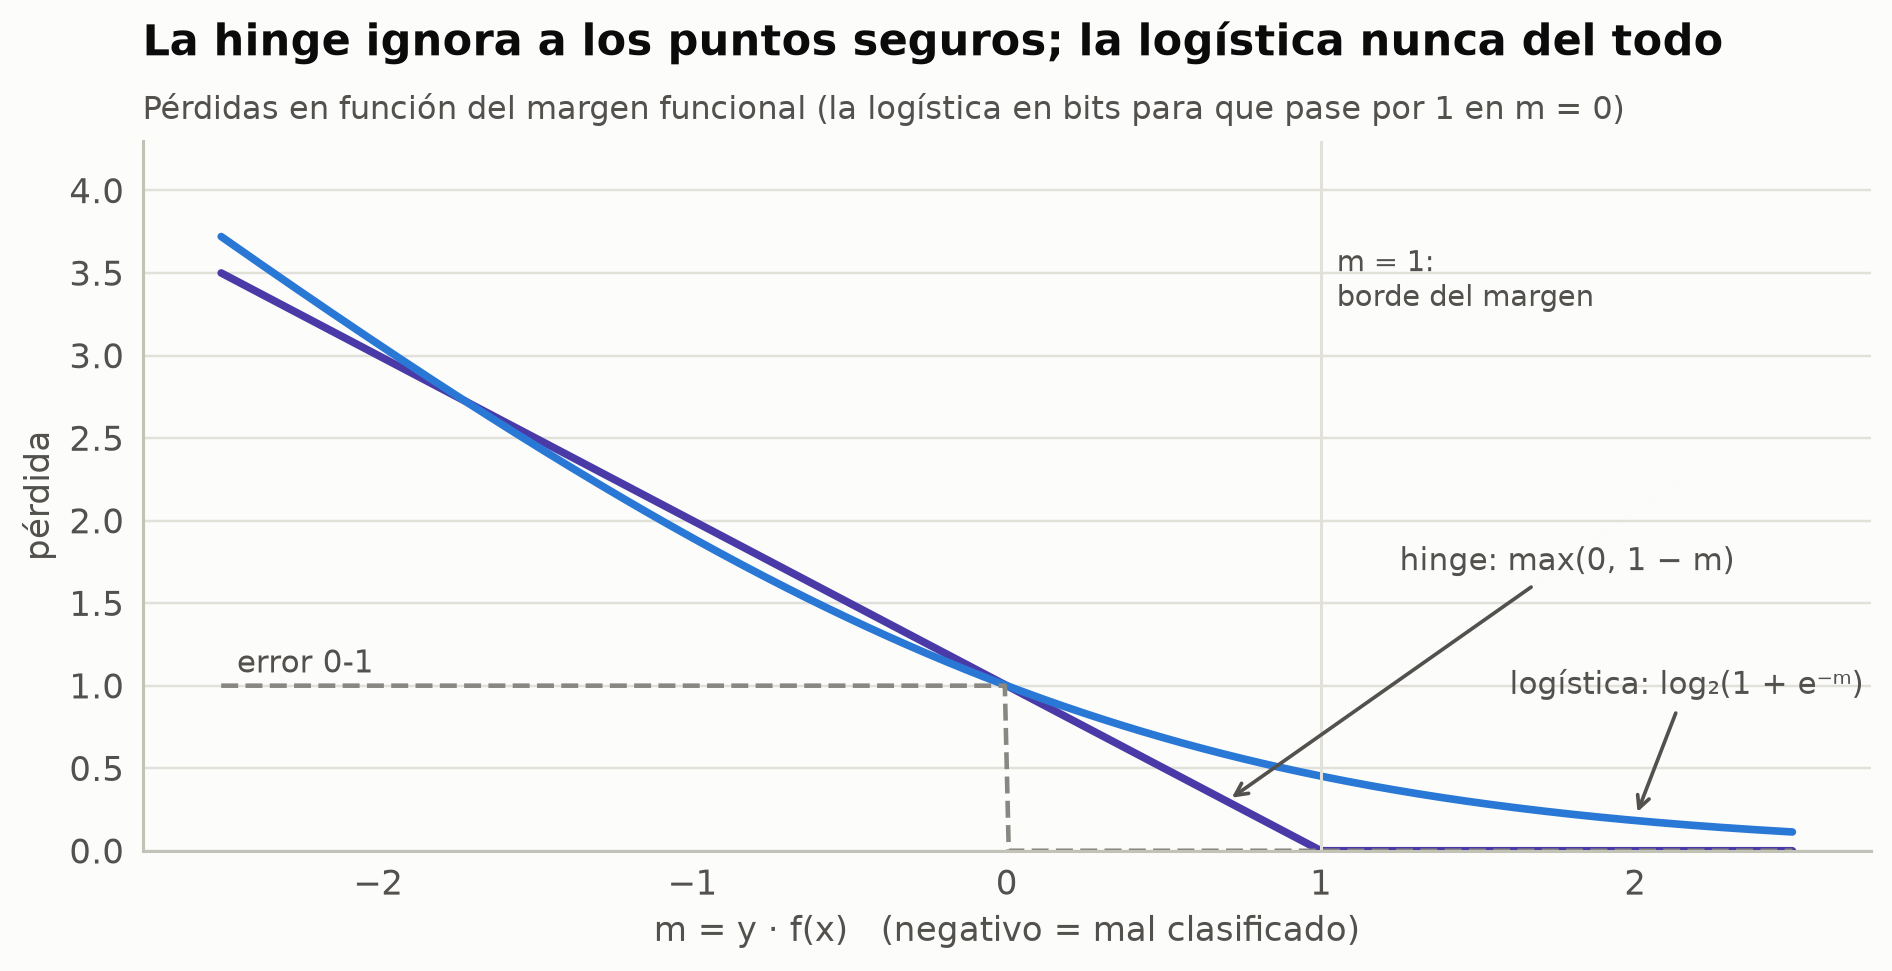

In [14]:
m = np.linspace(-2.5, 2.5, 400)                    # m = y·f(x), el «margen funcional»
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(m, np.maximum(0, 1 - m), color=ec.VIOLET, lw=2.5)
ax.plot(m, np.log2(1 + np.exp(-m)), color=ec.BLUE, lw=2.5)
ax.plot(m, (m < 0).astype(float), color=ec.MUTED, lw=1.5, ls="--")
ax.annotate("hinge: max(0, 1 − m)", (0.7, 0.3), xytext=(1.25, 1.7), fontsize=10, color=ec.INK_2,
            arrowprops=dict(arrowstyle="->", color=ec.INK_2, lw=1.2))
ax.annotate("logística: log₂(1 + e⁻ᵐ)", (2.0, 0.2), xytext=(1.6, 0.95), fontsize=10, color=ec.INK_2,
            arrowprops=dict(arrowstyle="->", color=ec.INK_2, lw=1.2))
ax.text(-2.45, 1.08, "error 0-1", fontsize=10, color=ec.INK_2)
ax.axvline(1, color=ec.GRID, lw=1); ax.text(1.05, 3.3, "m = 1:\nborde del margen", fontsize=9.5, color=ec.INK_2)
ax.set_xlabel("m = y · f(x)   (negativo = mal clasificado)"); ax.set_ylabel("pérdida"); ax.set_ylim(0, 4.3)
ec.title(ax, "La hinge ignora a los puntos seguros; la logística nunca del todo",
         "Pérdidas en función del margen funcional (la logística en bits para que pase por 1 en m = 0)")
plt.show()

> 🔎 **Qué observamos.** Para $m>1$ (bien clasificado y fuera del margen) la *hinge* vale cero: esos puntos no influyen
> en la solución. La logística sigue dando un empujón pequeño a todos. Por eso la SVM es «dispersa» en los ejemplos y la
> logística no.

### 5.2 La figura de fronteras del libro

Sobre los mismos 140 puntos de la animación, ajustamos una regresión logística ($C=1$) y una SVM lineal ($C=0{,}5$)
con los atributos estandarizados, y transformamos las rectas de vuelta a las unidades originales. Cifras del libro:
exactitud de entrenamiento 95 % (logística) y 95,7 % (SVM), con **31** vectores de soporte.

exactitud entrenamiento LR  = 0,950   [libro: 0,95]
exactitud entrenamiento SVM = 0,957   [libro: 0,957]
vectores de soporte = 31   [libro: 31]
CV10: LR 0,950  SVM 0,936   [libro: 0,95 / 0,936]


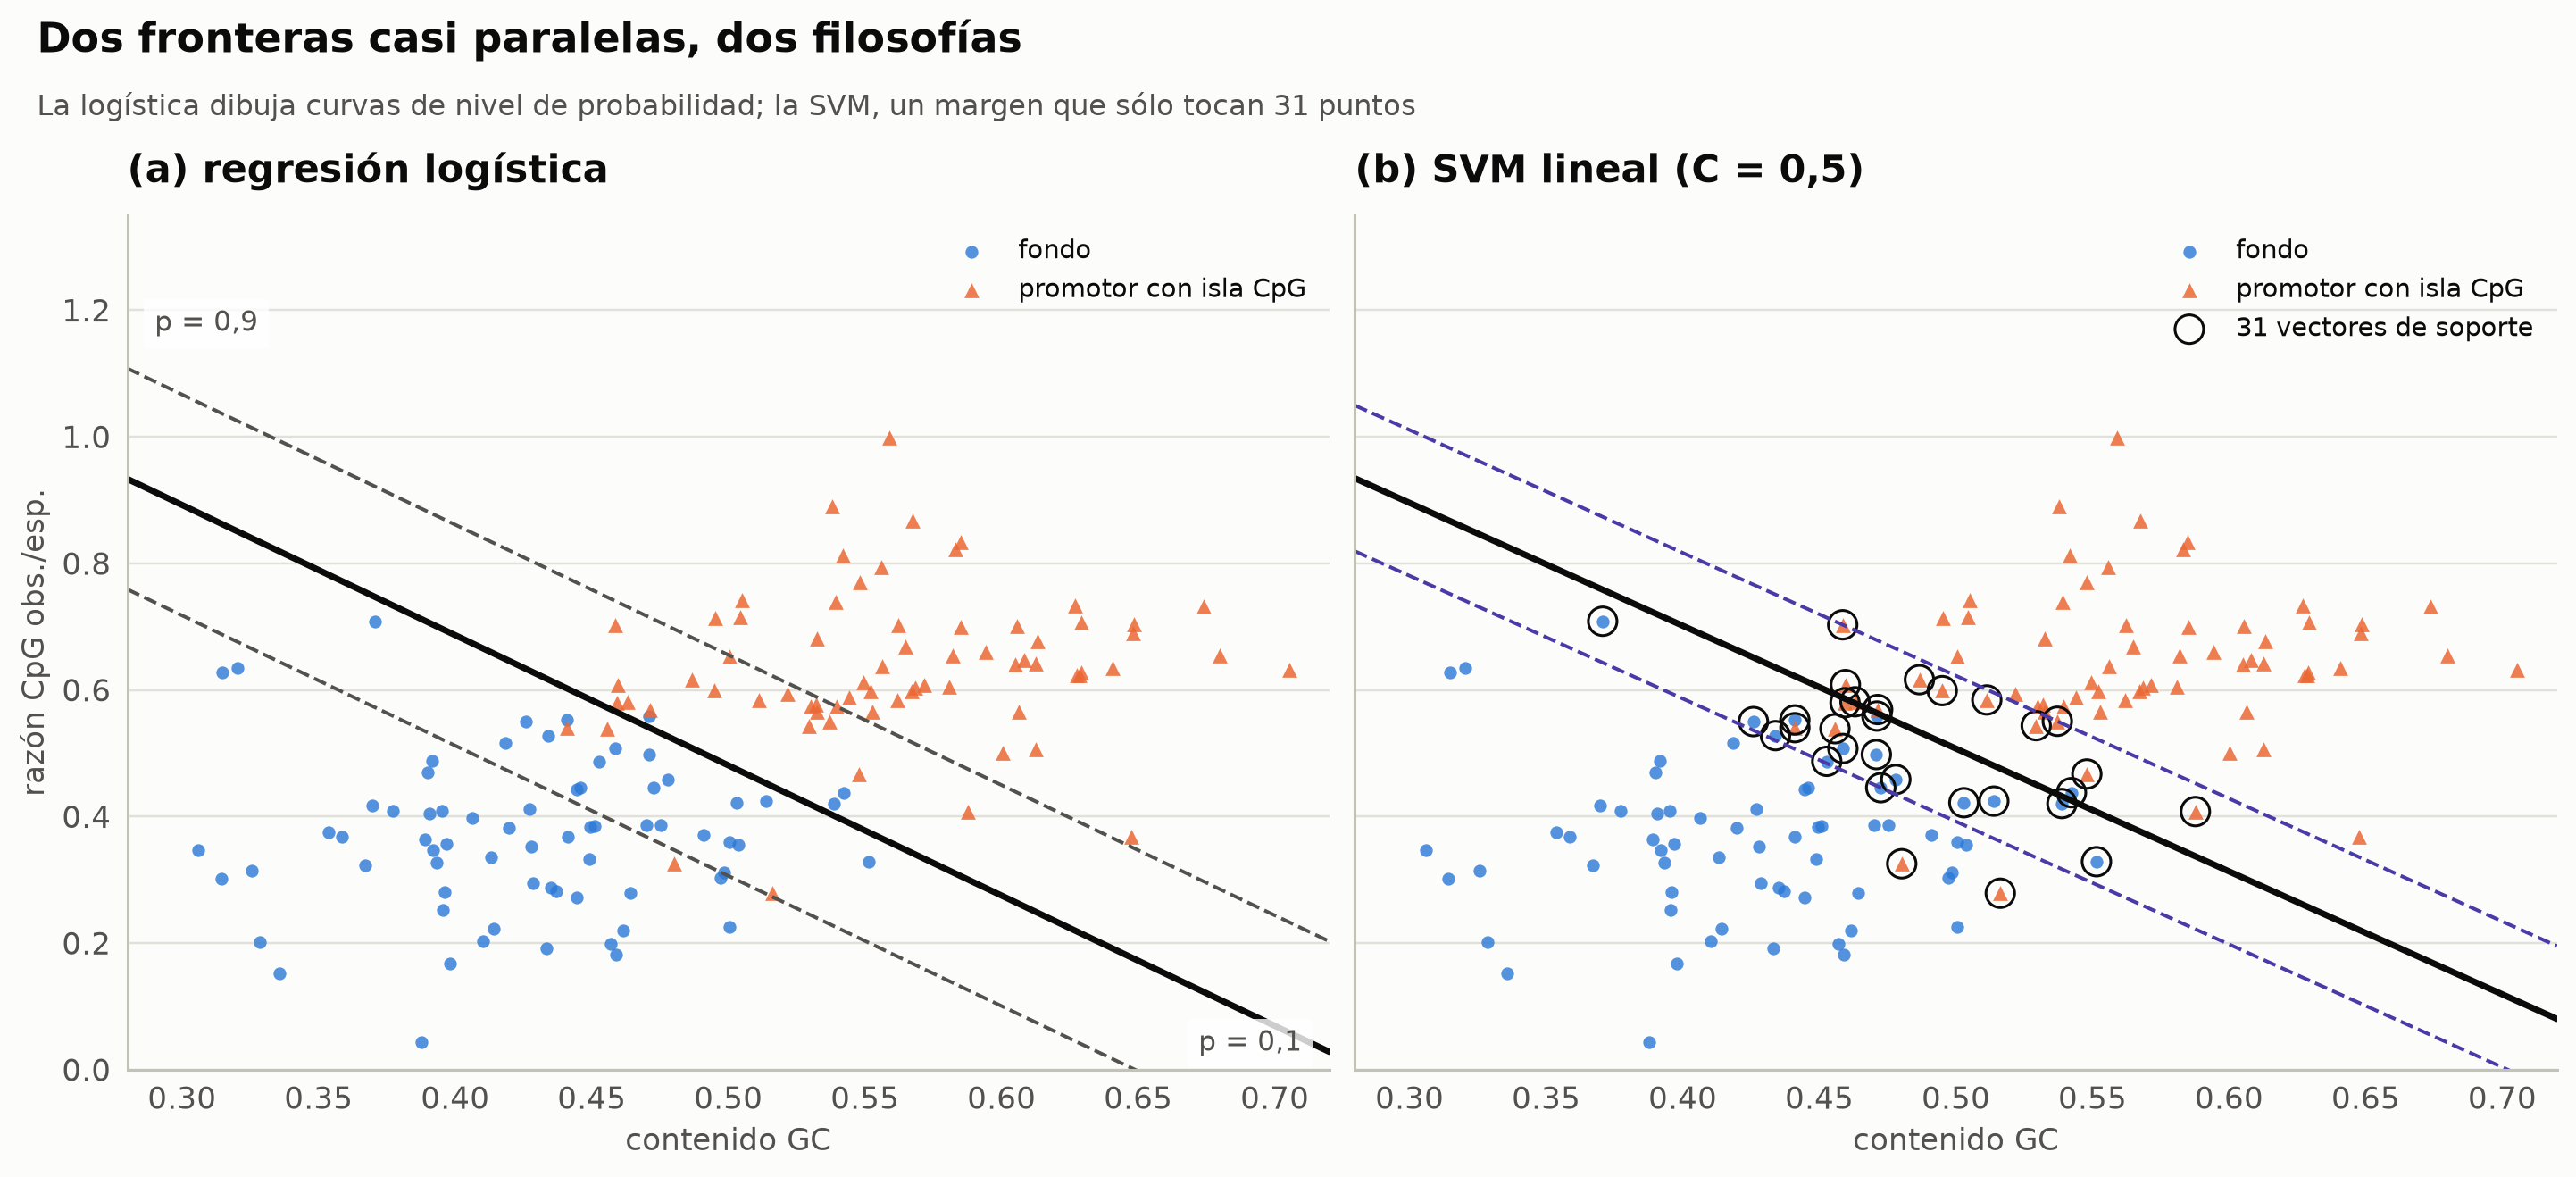

In [15]:
lr = LogisticRegression(C=1.0).fit(Z, yF)
svm = SVC(kernel="linear", C=0.5).fit(Z, yF)
print(f"exactitud entrenamiento LR  = {fmt(lr.score(Z, yF))}   [libro: 0,95]")
print(f"exactitud entrenamiento SVM = {fmt(svm.score(Z, yF))}   [libro: 0,957]")
print(f"vectores de soporte = {len(svm.support_)}   [libro: 31]")
print(f"CV10: LR {fmt(cross_val_score(LogisticRegression(), Z, yF, cv=10).mean())}  "
      f"SVM {fmt(cross_val_score(SVC(kernel='linear', C=0.5), Z, yF, cv=10).mean())}   [libro: 0,95 / 0,936]")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
for ax, (lab, mdl, levels, colm) in zip(axes, [("(a) regresión logística", lr, [0, np.log(9), -np.log(9)], ec.INK_2),
                                                ("(b) SVM lineal (C = 0,5)", svm, [0, 1, -1], ec.VIOLET)]):
    ax.scatter(gc0, oe0, s=22, color=ec.BLUE, alpha=0.8, label="fondo")
    ax.scatter(gc1, oe1, s=30, marker="^", color=ec.ORANGE, alpha=0.85, label="promotor con isla CpG")
    wz, bz = mdl.coef_[0], mdl.intercept_[0]
    for j, lev in enumerate(levels):
        ax.plot(xs_, raw_line(wz, bz, lev, xs_), color=ec.INK if j == 0 else colm, lw=2.3 if j == 0 else 1.3,
                ls="-" if j == 0 else "--")
    ax.set_xlim(0.28, 0.72); ax.set_ylim(0, 1.35); ax.set_xlabel("contenido GC")
    ax.set_title(lab, loc="left")
axes[0].set_ylabel("razón CpG obs./esp.")
axes[0].text(0.29, 1.2, "p = 0,9", va="top", fontsize=10, color=ec.INK_2, bbox=dict(fc="white", ec="none", alpha=0.8))
axes[0].text(0.71, 0.03, "p = 0,1", ha="right", fontsize=10, color=ec.INK_2, bbox=dict(fc="white", ec="none", alpha=0.8))
sv = svm.support_
axes[1].scatter(F[sv, 0], F[sv, 1], s=110, facecolors="none", edgecolors=ec.INK, lw=1, label=f"{len(sv)} vectores de soporte")
axes[1].legend(frameon=False, loc="upper right", fontsize=9.5)
axes[0].legend(frameon=False, loc="upper right", fontsize=9.5)
ec.fig_title(fig, "Dos fronteras casi paralelas, dos filosofías",
             "La logística dibuja curvas de nivel de probabilidad; la SVM, un margen que sólo tocan 31 puntos")
plt.show()

> 🔎 **Qué observamos.** Es la figura 17.2 del libro. Las dos rectas continuas casi coinciden. La franja entre
> $p=0{,}9$ y $p=0{,}1$ de la logística es una zona de incertidumbre; los trazos violetas de la SVM ($f=\pm1$) delimitan
> el margen, y sólo los puntos rodeados lo determinan: mover cualquier otro sin cruzar el margen no cambia nada.

### 5.3 Caso real: la misma figura con 2 000 ventanas del genoma humano

¿Se comportan igual los datos reales? Calculamos los mismos dos atributos (GC y CpG obs./esp.) para 1 000 sitios de
CTCF y 1 000 ventanas de fondo, ajustamos una regresión logística y dibujamos su mapa de probabilidad. Pase el cursor
por los puntos: verá las coordenadas genómicas, los atributos y la probabilidad asignada.

AUC (CV 5) con sólo GC y CpG o/e: 0,763


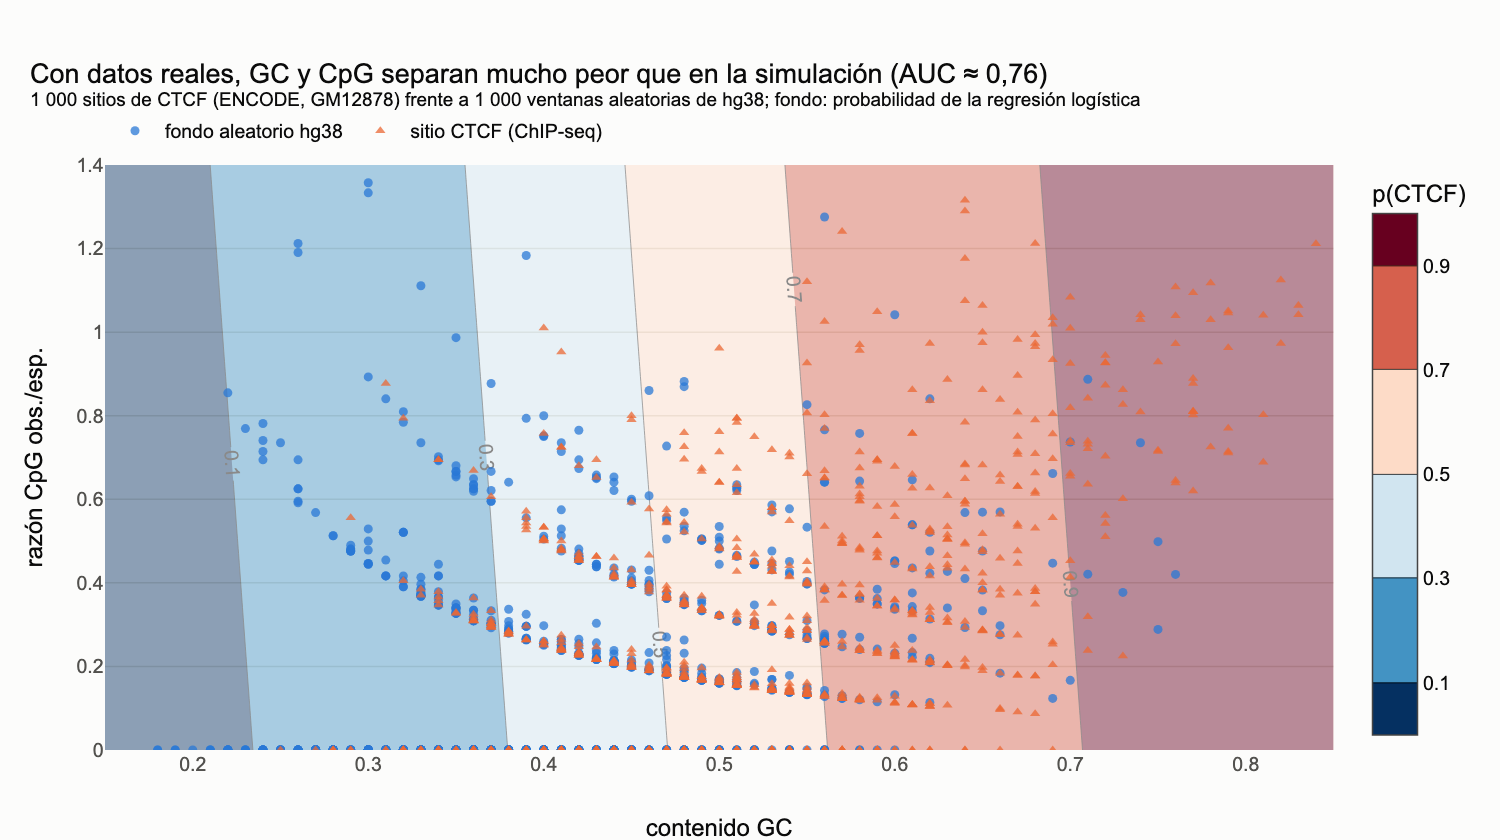

In [16]:
idx_neg = rng.choice(len(ctcf_neg), 1000, replace=False)
seqs_bal = ctcf_pos + [ctcf_neg[i] for i in idx_neg]
y_bal = np.r_[np.ones(1000), np.zeros(1000)].astype(int)
chr_bal = np.r_[chr_pos, chr_neg[idx_neg]]
names_bal = [h.split()[0] for h, s in peaks] + [bg[i][0] for i in idx_neg]
F2 = np.array([(gc_content(s), cpg_oe(s)) for s in seqs_bal])
pipe2 = make_pipeline(StandardScaler(), LogisticRegression())
auc2 = cross_val_score(pipe2, F2, y_bal, cv=StratifiedKFold(5, shuffle=True, random_state=0), scoring="roc_auc").mean()
pipe2.fit(F2, y_bal)
prob2 = pipe2.predict_proba(F2)[:, 1]
print(f"AUC (CV 5) con sólo GC y CpG o/e: {fmt(auc2)}")

gx, gy = np.linspace(0.15, 0.85, 120), np.linspace(0, 1.4, 120)
GX, GY = np.meshgrid(gx, gy)
PG = pipe2.predict_proba(np.c_[GX.ravel(), GY.ravel()])[:, 1].reshape(GX.shape)
figb = go.Figure(go.Contour(x=gx, y=gy, z=PG, colorscale="RdBu_r", zmin=0, zmax=1, opacity=0.45,
                            contours=dict(start=0.1, end=0.9, size=0.2, showlabels=True),
                            colorbar=dict(title="p(CTCF)"), hoverinfo="skip"))
for cls, nm, col, sym in ((0, "fondo aleatorio hg38", ec.BLUE, "circle"), (1, "sitio CTCF (ChIP-seq)", ec.ORANGE, "triangle-up")):
    k = np.where(y_bal == cls)[0]
    txt = [f"<b>{names_bal[i]}</b><br>GC = {F2[i, 0]:.2f} · CpG o/e = {F2[i, 1]:.2f}<br>"
           f"p(CTCF) según el modelo = {prob2[i]:.2f}<br>{'✔ bien clasificado' if (prob2[i] > 0.5) == cls else '✘ mal clasificado'}"
           for i in k]
    figb.add_trace(go.Scatter(x=F2[k, 0], y=F2[k, 1], mode="markers", name=nm, text=txt,
                              hovertemplate="%{text}<extra></extra>",
                              marker=dict(color=col, symbol=sym, size=6, opacity=0.75, line=dict(width=0))))
figb.update_layout(title=f"Con datos reales, GC y CpG separan mucho peor que en la simulación (AUC ≈ {fmt(auc2, 2)})"
                         "<br><sup>1 000 sitios de CTCF (ENCODE, GM12878) frente a 1 000 ventanas aleatorias de hg38; "
                         "fondo: probabilidad de la regresión logística</sup>",
                   xaxis=dict(title="contenido GC", range=[0.15, 0.85]), yaxis=dict(title="razón CpG obs./esp.", range=[0, 1.4]),
                   height=560, margin=dict(t=110, l=70, r=30, b=60),
                   legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
figb.show()

> 🔎 **Qué observamos.** La biología real es más confusa que la simulación: las nubes se solapan mucho y la frontera
> sólo alcanza un AUC moderado. Además, lo que separa es sobre todo el **GC**: el modelo está aprendiendo «las regiones
> ricas en GC suelen ser sitios de CTCF», un atajo, no el motivo. Para captar el motivo necesitamos atributos más ricos:
> el espectro de $k$-mers y el núcleo de espectro.

### 5.4 Una SVM con núcleo de espectro sobre CTCF

Con el truco del núcleo, basta con darle a `SVC(kernel="precomputed")` la matriz $\tilde K_k$ entre todas las
secuencias. Veamos cómo cambia el AUC con $k$.

> 🤔 **Antes de ejecutar, prediga.** ¿Mejorará el AUC al pasar de $k=3$ a $k=7$? Recuerde que el motivo de CTCF es
> largo y que con $k=7$ hay 16 384 palabras posibles para ventanas de sólo 94 palabras.

k = 2:  AUC (CV 5) = 0,785 ± 0,032


k = 3:  AUC (CV 5) = 0,794 ± 0,029


k = 4:  AUC (CV 5) = 0,854 ± 0,030


k = 5:  AUC (CV 5) = 0,861 ± 0,027


k = 6:  AUC (CV 5) = 0,891 ± 0,013


k = 7:  AUC (CV 5) = 0,908 ± 0,009


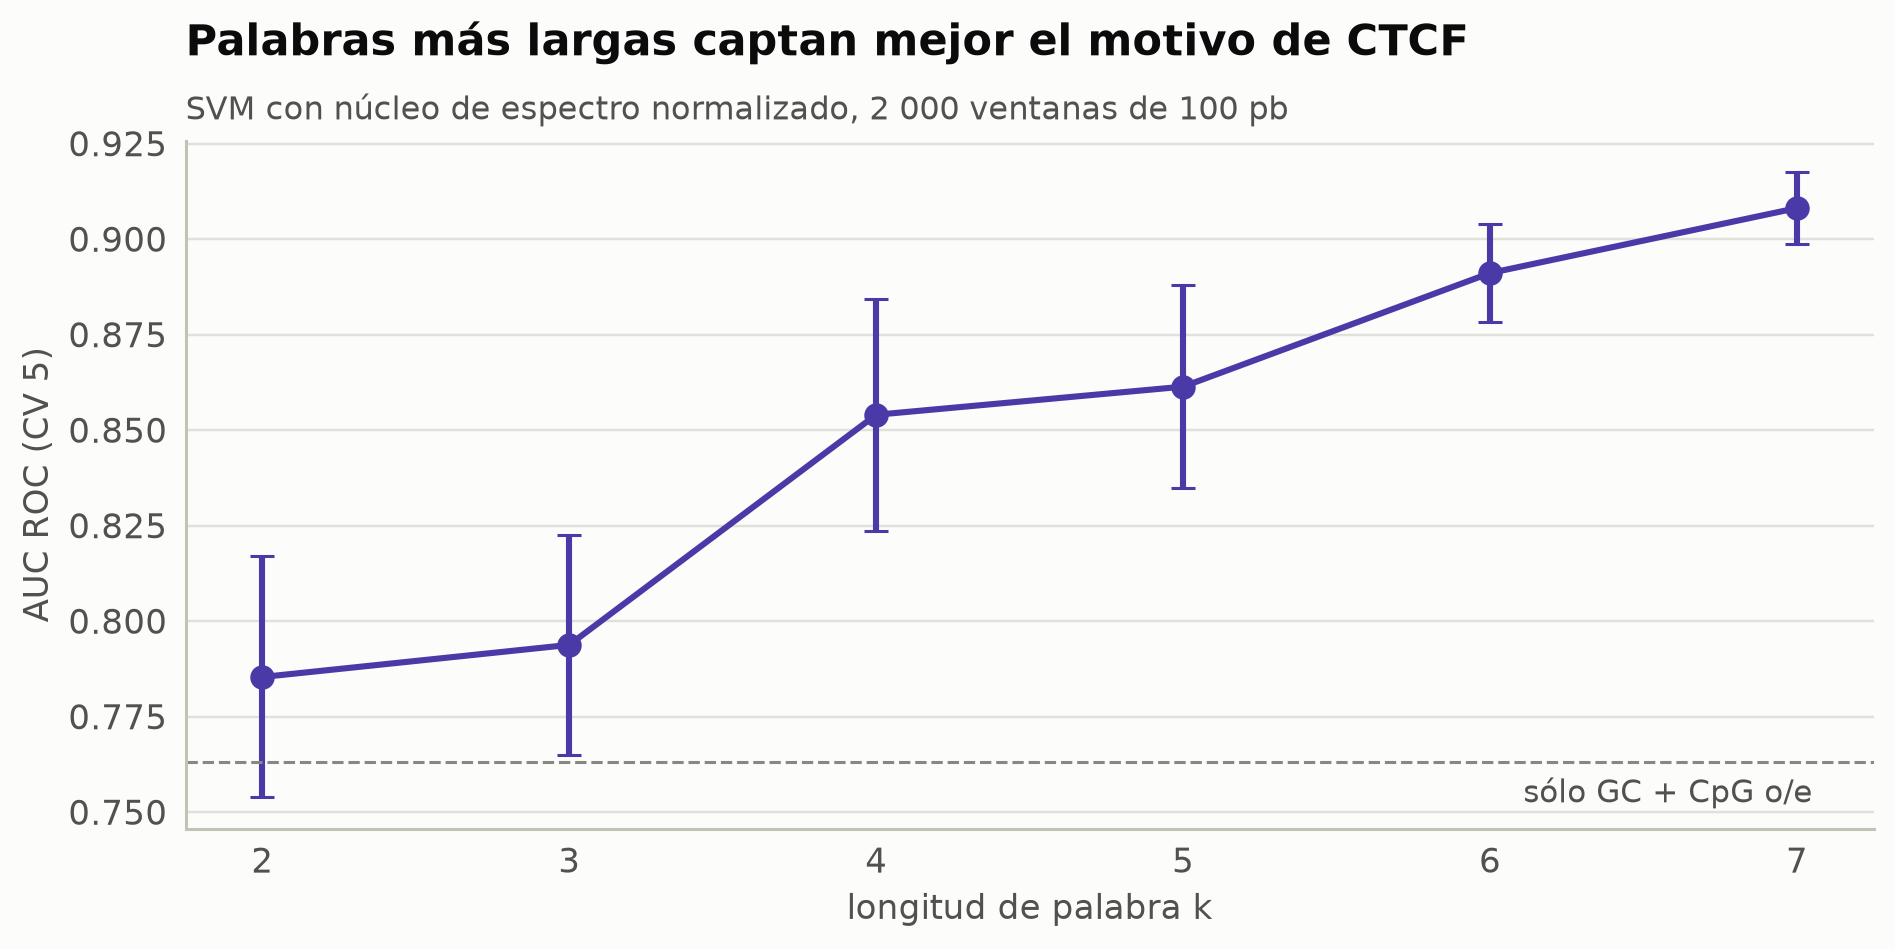

In [17]:
cv5 = StratifiedKFold(5, shuffle=True, random_state=0)
res_k = []
for k in (2, 3, 4, 5, 6, 7):
    Phi = normalize(CountVectorizer(analyzer="char", ngram_range=(k, k), lowercase=False)
                    .fit_transform(seqs_bal).astype(float))
    Kmat = (Phi @ Phi.T).toarray()                        # núcleo de espectro normalizado
    auc = cross_val_score(SVC(kernel="precomputed", C=1), Kmat, y_bal, cv=cv5, scoring="roc_auc")
    res_k.append((k, auc.mean(), auc.std()))
    print(f"k = {k}:  AUC (CV 5) = {fmt(auc.mean())} ± {fmt(auc.std())}")
res_k = np.array(res_k)
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.errorbar(res_k[:, 0], res_k[:, 1], yerr=res_k[:, 2], fmt="o-", color=ec.VIOLET, lw=2, capsize=4)
ax.axhline(auc2, color=ec.MUTED, ls="--", lw=1)
ax.text(7.05, auc2 - 0.004, "sólo GC + CpG o/e", color=ec.INK_2, fontsize=10, va="top", ha="right")
ax.set_xlabel("longitud de palabra k"); ax.set_ylabel("AUC ROC (CV 5)")
ec.title(ax, "Palabras más largas captan mejor el motivo de CTCF", "SVM con núcleo de espectro normalizado, 2 000 ventanas de 100 pb")
plt.show()

> 🔎 **Qué observamos.** El AUC sube con $k$: palabras de 6–7 letras empiezan a capturar trozos del motivo de CTCF, cosa
> que un espectro de 2-mers (que es casi sólo composición) no puede. En esta ventana de $k$ no hemos llegado aún al
> punto en que el espectro sea tan disperso que nada se parezca a nada, pero existe: el ejercicio 2 le pide buscarlo.

## 6. Árboles de decisión y *random forests*

### 6.1 Un juego de veinte preguntas

Un **árbol de decisión** clasifica mediante una cascada de preguntas binarias («¿el conteo de `TGA` es mayor que 2?»),
como el juego de adivinar un personaje con preguntas de sí o no. En cada nodo elige el atributo y el umbral que más
reducen la **impureza** de los grupos resultantes, típicamente medida por el índice de Gini (ecuación 17.11):

$$
G(\text{nodo}) = \sum_{c} \hat p_c\,(1-\hat p_c).
$$

| Símbolo | Significado |
|---|---|
| $\hat p_c$ | Fracción de las secuencias del nodo que pertenecen a la clase $c$ |
| $G$ | Impureza de Gini: 0 si el nodo es puro, máxima (0,5 con dos clases) si están mezcladas a partes iguales |

**A mano.** Un nodo tiene 8 sitios de CTCF y 2 ventanas de fondo: $G=0{,}8\cdot0{,}2+0{,}2\cdot0{,}8=0{,}32$. La
pregunta «¿contiene `CCCTC`?» lo divide en un hijo con 6 sitios y 0 fondos ($G=0$) y otro con 2 y 2 ($G=0{,}5$). La
impureza ponderada de los hijos es $0{,}6\cdot0+0{,}4\cdot0{,}5=0{,}20$: la pregunta reduce la impureza en $0{,}12$. El
árbol prueba todas las preguntas posibles y se queda con la de mayor reducción.

Los árboles son interpretables y capturan interacciones no lineales, pero son **inestables**: pequeños cambios en los
datos producen árboles muy distintos, es decir, tienen **alta varianza**. Breiman (2001) atacó esa debilidad con los
***random forests***: entrenar $B$ árboles profundos, cada uno sobre una muestra *bootstrap* de los datos y eligiendo en
cada nodo el mejor atributo entre un subconjunto aleatorio, y promediar sus votos. ¿Por qué funciona? Si cada árbol
tiene varianza $\sigma^2$ y la correlación entre dos árboles es $\rho$, la varianza del promedio es (ecuación 17.12)

$$
\operatorname{Var}\!\left(\frac1B\sum_{b=1}^{B}T_b(\mathbf{x})\right) = \rho\,\sigma^2 + \frac{1-\rho}{B}\,\sigma^2 .
$$

| Símbolo | Significado |
|---|---|
| $T_b(\mathbf{x})$ | Predicción del árbol $b$ para la entrada $\mathbf{x}$ |
| $B$ | Número de árboles del bosque |
| $\rho$ | Correlación entre las predicciones de dos árboles distintos |
| $\sigma^2$ | Varianza de la predicción de un árbol individual |

El segundo término desaparece al aumentar $B$, pero el primero no: la única forma de reducirlo es **decorrelacionar**
los árboles, que es exactamente lo que logra la selección aleatoria de atributos. Es lo mismo que preguntar a un
comité: diez expertos que leyeron el mismo libro opinan casi igual (ρ alta) y su promedio apenas mejora a uno solo.

G(padre) = 0.32; hijos: 0.00 y 0.50; ponderada = 0.20; reducción = 0.12


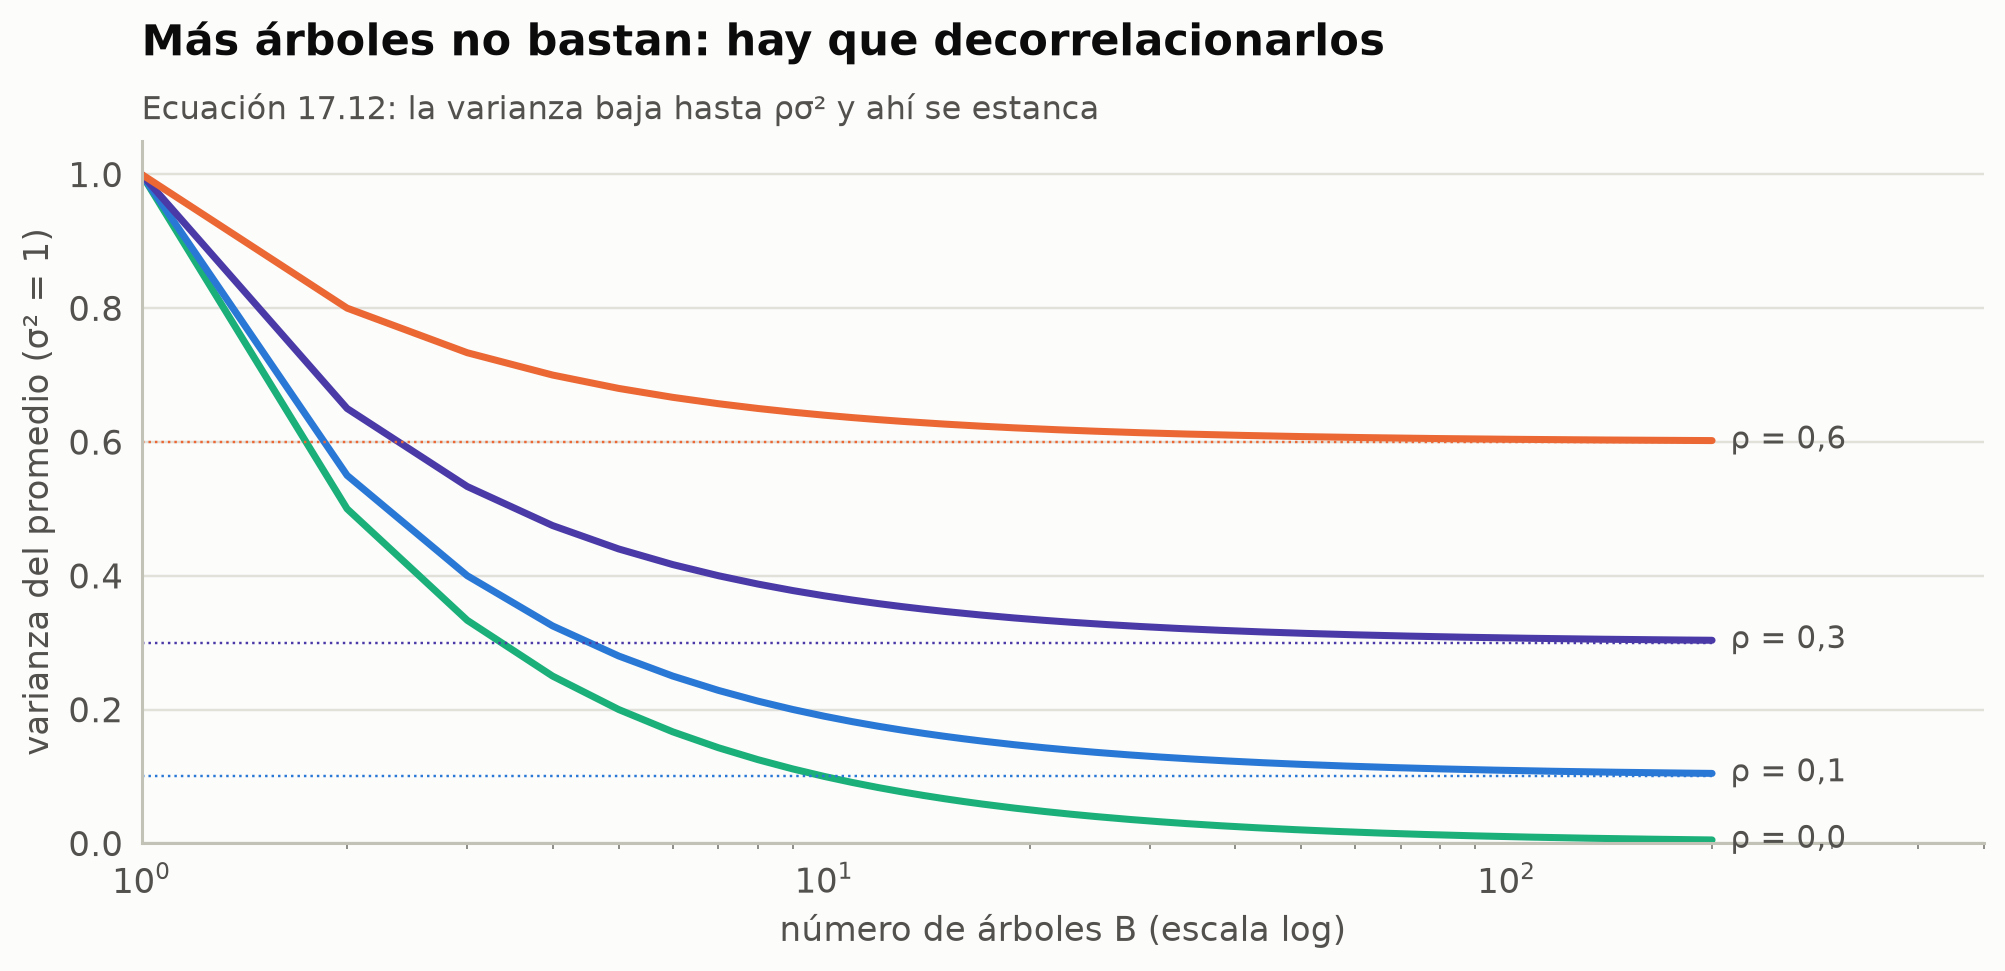

In [18]:
from sklearn.tree import DecisionTreeClassifier
def gini(counts):
    p = np.array(counts) / sum(counts)
    return float(np.sum(p * (1 - p)))
g_padre, g_izq, g_der = gini([8, 2]), gini([6, 0]), gini([2, 2])
print(f"G(padre) = {g_padre:.2f}; hijos: {g_izq:.2f} y {g_der:.2f}; ponderada = {0.6 * g_izq + 0.4 * g_der:.2f}; "
      f"reducción = {g_padre - (0.6 * g_izq + 0.4 * g_der):.2f}")

B = np.arange(1, 201)
fig, ax = plt.subplots(figsize=(9, 4.3))
for rho, col in zip((0.0, 0.1, 0.3, 0.6), (ec.AQUA, ec.BLUE, ec.VIOLET, ec.ORANGE)):
    v = rho + (1 - rho) / B                       # σ² = 1
    ax.plot(B, v, color=col, lw=2.3)
    ec.label_end(ax, B[-1], v[-1], f"ρ = {rho:.1f}".replace(".", ","))
    if rho > 0:
        ax.hlines(rho, 1, 200, color=col, lw=0.8, ls=":")
ax.set_xscale("log"); ax.set_xlim(1, 500); ax.set_ylim(0, 1.05)
ax.set_xlabel("número de árboles B (escala log)"); ax.set_ylabel("varianza del promedio (σ² = 1)")
ec.title(ax, "Más árboles no bastan: hay que decorrelacionarlos", "Ecuación 17.12: la varianza baja hasta ρσ² y ahí se estanca")
plt.show()

> 🔎 **Qué observamos.** Con árboles independientes (ρ = 0) la varianza cae como $1/B$ hasta desaparecer; con ρ = 0,6
> se estanca en 0,6 por muchos árboles que añadamos. Por eso un bosque con `max_features="sqrt"` (cada nodo sólo mira
> una fracción aleatoria de los atributos) generaliza mejor que el simple *bagging* de árboles idénticos.

### 6.2 Un bosque sobre CTCF, con error «fuera de la bolsa»

Cada árbol deja fuera alrededor de un tercio de los datos (los que no salieron en su *bootstrap*; la fracción exacta
tiende a $(1-1/n)^n\to e^{-1}\approx0{,}368$). Evaluar a cada secuencia sólo con los árboles que no la vieron da una
estimación del error de generalización «fuera de la bolsa» (*out-of-bag*, OOB) sin un conjunto de prueba separado.

Random forest (300 árboles, espectro de 5-mers): exactitud OOB = 0,775, AUC OOB = 0,863  (0.3 s)


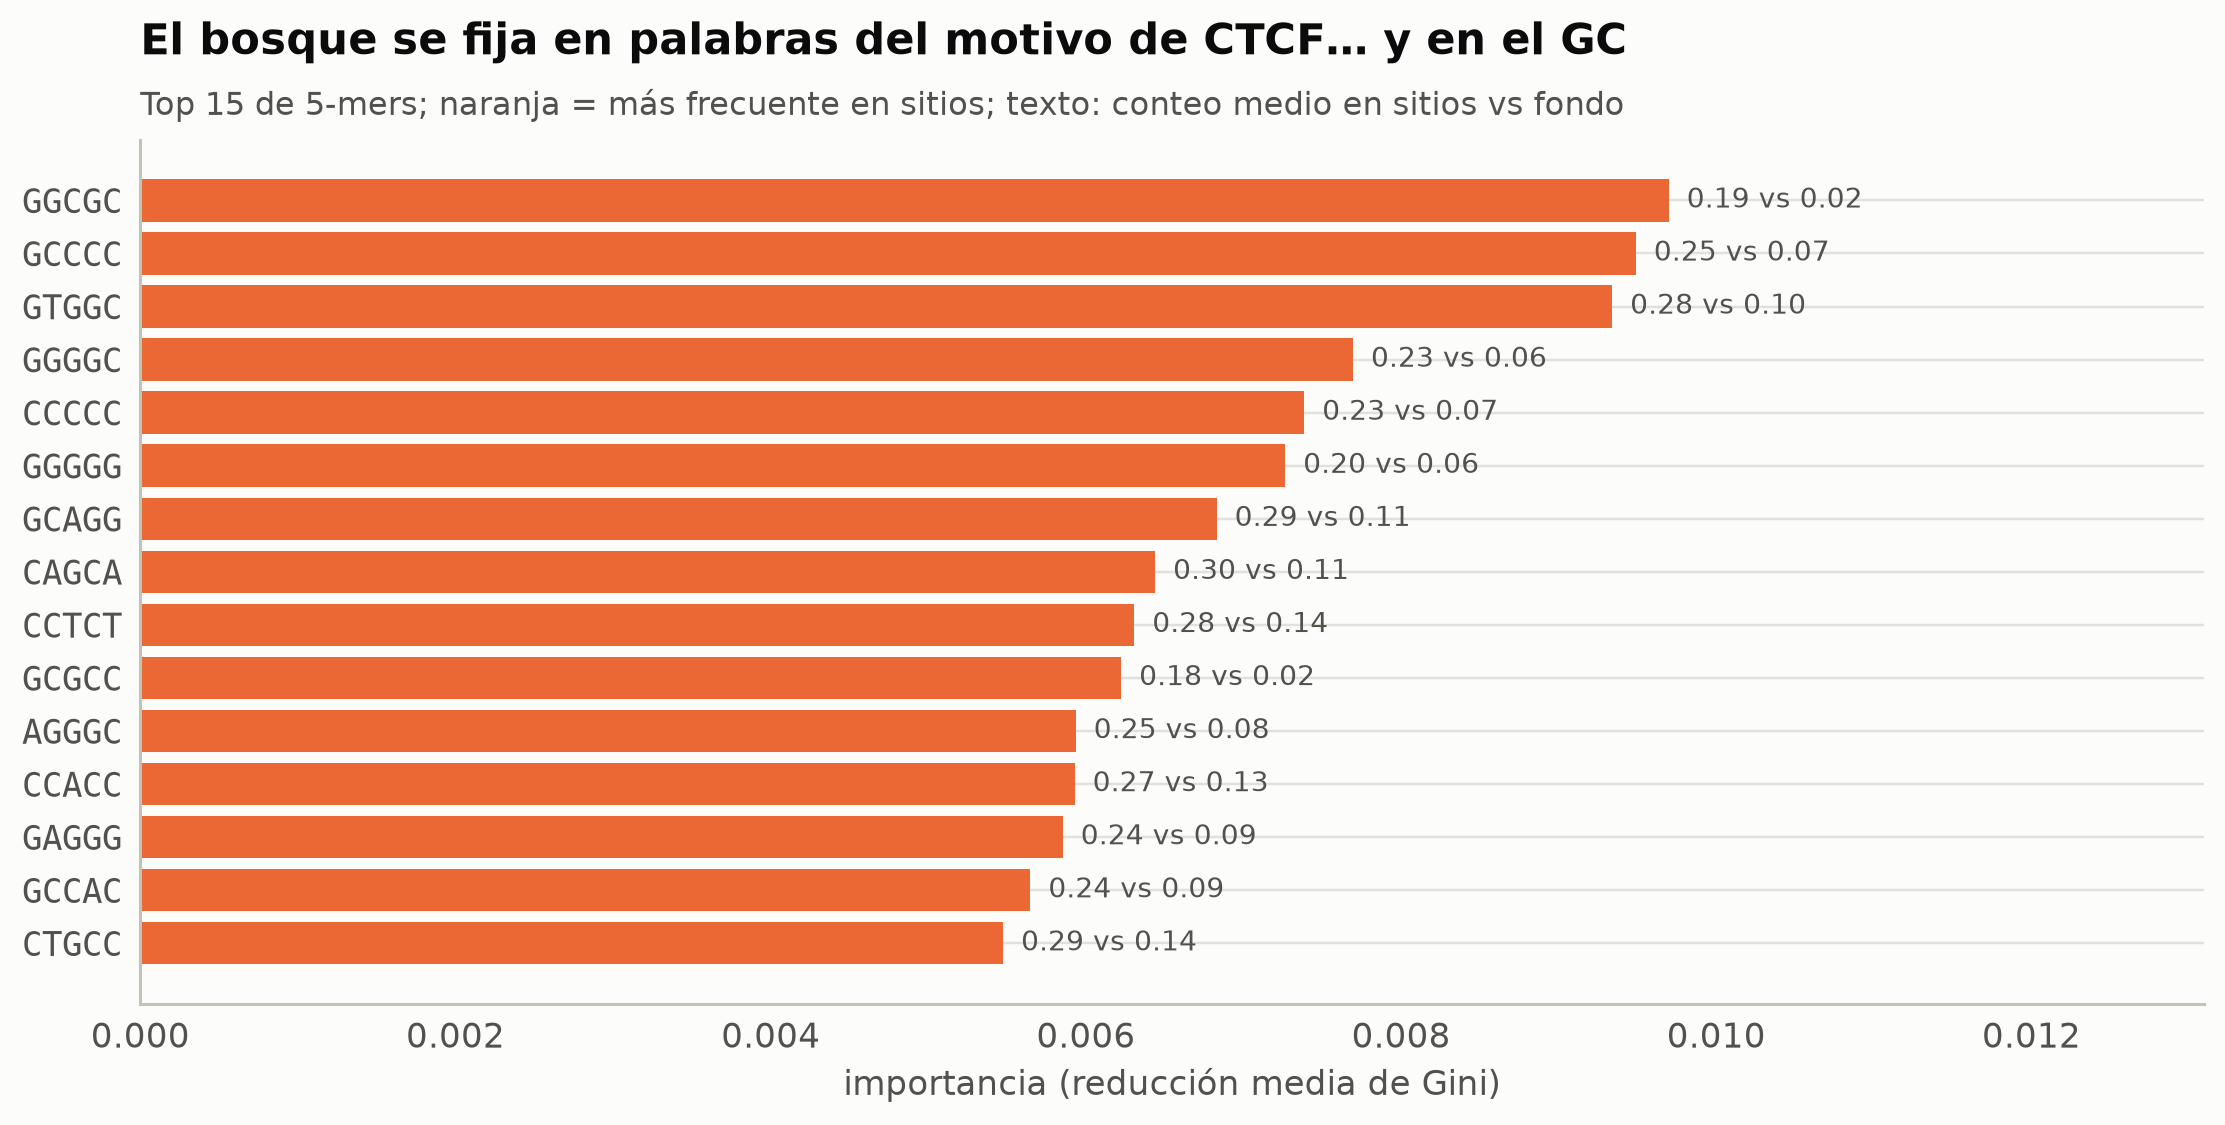

In [19]:
vec5 = CountVectorizer(analyzer="char", ngram_range=(5, 5), lowercase=False)
X5 = vec5.fit_transform(seqs_bal)
t0 = time.time()
rf_ctcf = RandomForestClassifier(n_estimators=300, oob_score=True, n_jobs=-1, random_state=0).fit(X5, y_bal)
oob_auc = roc_auc_score(y_bal, rf_ctcf.oob_decision_function_[:, 1])
print(f"Random forest (300 árboles, espectro de 5-mers): exactitud OOB = {fmt(rf_ctcf.oob_score_)}, "
      f"AUC OOB = {fmt(oob_auc)}  ({time.time() - t0:.1f} s)")
voc = np.array(vec5.get_feature_names_out())
imp = rf_ctcf.feature_importances_
top = np.argsort(-imp)[:15]
fp = np.asarray(X5[y_bal == 1].mean(0)).ravel(); fn = np.asarray(X5[y_bal == 0].mean(0)).ravel()
fig, ax = plt.subplots(figsize=(10, 5))
cols = [ec.ORANGE if fp[i] > fn[i] else ec.BLUE for i in top]
ax.barh(range(15)[::-1], imp[top], color=cols)
ax.set_yticks(range(15)[::-1], voc[top], family="monospace")
for j, i in enumerate(top):
    ax.text(imp[i], 14 - j, f"  {fp[i]:.2f} vs {fn[i]:.2f}", va="center", fontsize=9, color=ec.INK_2)
ax.set_xlabel("importancia (reducción media de Gini)")
ax.set_xlim(0, imp[top].max() * 1.35)
ec.title(ax, "El bosque se fija en palabras del motivo de CTCF… y en el GC",
         "Top 15 de 5-mers; naranja = más frecuente en sitios; texto: conteo medio en sitios vs fondo")
plt.show()

> 🔎 **Qué observamos.** Todas las palabras más importantes son más frecuentes en los sitios. Algunas son fragmentos del
> motivo de CTCF (`CCGCGNGGNGGCAG`, y en su forma inversa `CTGCCNCCNCGCGG`): `GCAGG`, `CAGCA`, `GGCGC`, `CCACC`, `GCGCC`.
> Otras (`CCCCC`, `GGGGG`, `GGGGC`) sólo delatan un alto contenido de GC. La importancia de Gini no distingue motivo de
> atajo: la interpretación exige cuidado, como veremos en la sección 8.

## 7. Sesgo, varianza y complejidad

Para la pérdida cuadrática, el error esperado de un modelo en un punto $\mathbf{x}$, promediado sobre todos los
conjuntos de entrenamiento posibles, se descompone **exactamente** en tres términos (ecuación 17.13):

$$
\mathbb{E}\Big[\big(y-\hat f(\mathbf{x})\big)^2\Big] = \underbrace{\sigma_\varepsilon^2}_{\text{ruido}} + \underbrace{\big(\mathbb{E}[\hat f(\mathbf{x})]-f(\mathbf{x})\big)^2}_{\text{sesgo}^2} + \underbrace{\mathbb{E}\Big[\big(\hat f(\mathbf{x})-\mathbb{E}[\hat f(\mathbf{x})]\big)^2\Big]}_{\text{varianza}}.
$$

| Símbolo | Significado |
|---|---|
| $f(\mathbf{x})$ | Función verdadera; $y=f(\mathbf{x})+\varepsilon$ |
| $\hat f(\mathbf{x})$ | Modelo ajustado; es aleatorio porque depende de la muestra de entrenamiento |
| $\sigma^2_\varepsilon$ | Varianza del ruido irreducible $\varepsilon$ (errores experimentales, etiquetas ambiguas) |

Piense en un tirador: el **sesgo** es apuntar sistemáticamente a la izquierda del blanco; la **varianza**, que el pulso
tiemble y los disparos se dispersen. Un modelo demasiado simple (un árbol de profundidad 1) no puede representar la
frontera verdadera: sesgo alto. Uno demasiado flexible (un árbol que crece hasta dejar una hoja por secuencia)
reproduce el ruido de su muestra concreta: varianza alta.

**A mano.** Si $f(\mathbf{x})=2$, el ruido tiene $\sigma_\varepsilon^2=0{,}25$ y, entrenado en muchas muestras, el modelo
predice en promedio 1,8 con varianza 0,09, el error esperado es $0{,}25+0{,}2^2+0{,}09=0{,}38$.

La figura del libro usa 400 puntos simulados con dos clases entrelazadas (`make_moons`, ruido 0,33, semilla 17) y
árboles de profundidad 1 a 15. Cifras del libro: mínimo del error de validación en profundidad **6** (0,110); con
profundidad 15, error de entrenamiento 0 y de validación **0,132**; un *random forest* de 300 árboles, **0,105**.

mejor profundidad = 6, error CV = 0,110   [libro: 6, 0,110]
profundidad 15: error CV = 0,132, entrenamiento = 0,000   [libro: 0,132 / 0,000]
random forest: error CV = 0,105   [libro: 0,105]


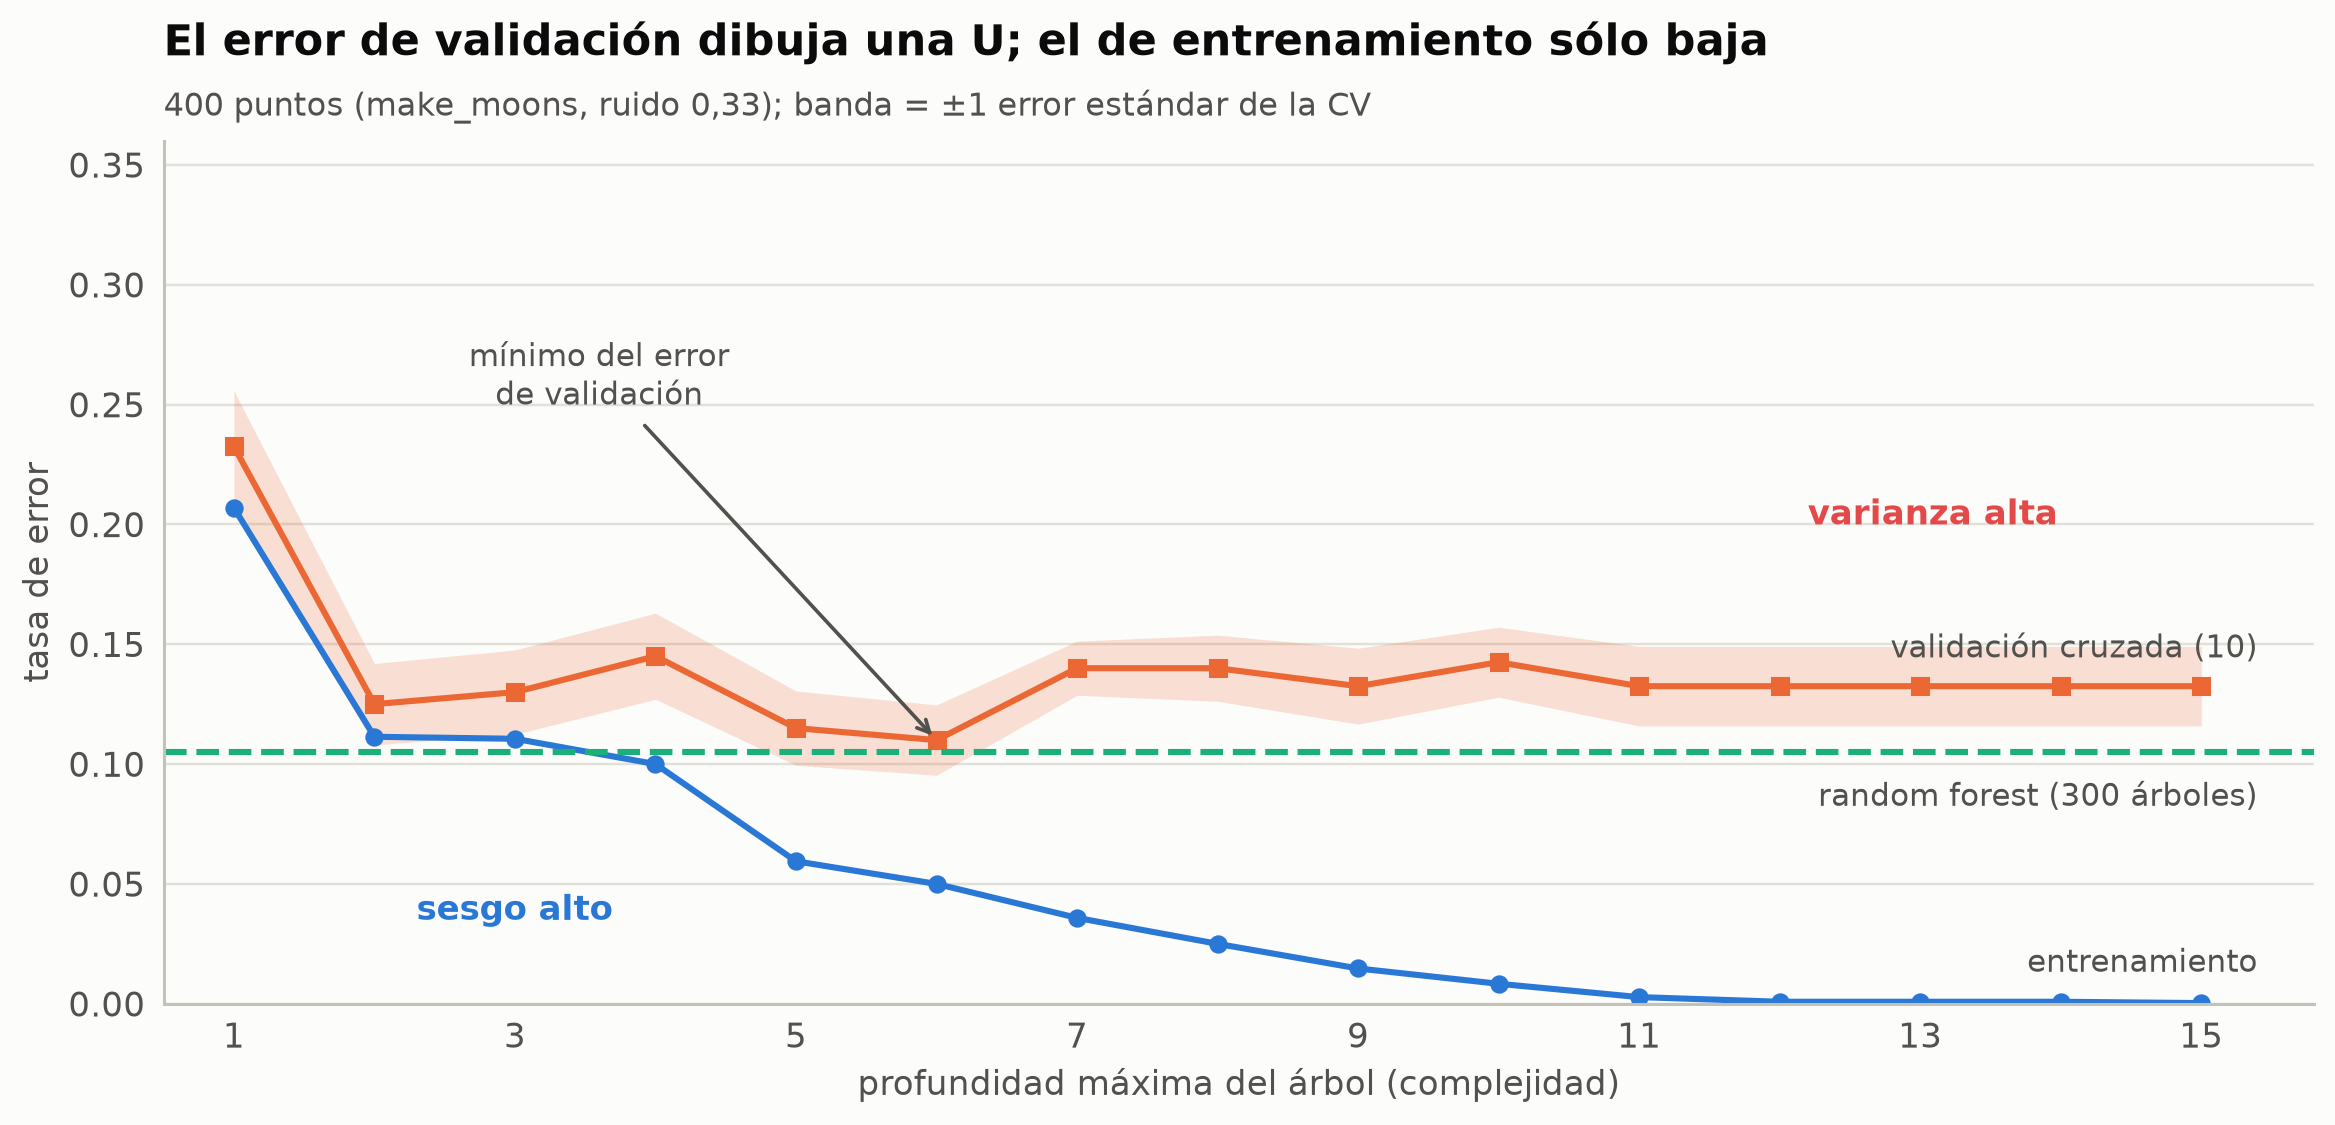

In [20]:
Xm, ym = make_moons(n_samples=400, noise=0.33, random_state=17)
cv10 = StratifiedKFold(10, shuffle=True, random_state=17)
rows_sv = []
for d in range(1, 16):
    res = cross_validate(DecisionTreeClassifier(max_depth=d, random_state=0), Xm, ym, cv=cv10, return_train_score=True)
    rows_sv.append((d, 1 - res["train_score"].mean(), 1 - res["test_score"].mean(), res["test_score"].std()))
sv_tab = pd.DataFrame(rows_sv, columns=["d", "train", "cv", "cvsd"])
best = sv_tab.loc[sv_tab.cv.idxmin()]
rf_err = 1 - cross_val_score(RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0),
                             Xm, ym, cv=cv10).mean()
print(f"mejor profundidad = {int(best.d)}, error CV = {fmt(best.cv)}   [libro: 6, 0,110]")
print(f"profundidad 15: error CV = {fmt(sv_tab.cv.iloc[-1])}, entrenamiento = {fmt(sv_tab.train.iloc[-1])}   [libro: 0,132 / 0,000]")
print(f"random forest: error CV = {fmt(rf_err)}   [libro: 0,105]")

fig, ax = plt.subplots(figsize=(10.5, 5))
se = sv_tab.cvsd / np.sqrt(10)
ax.fill_between(sv_tab.d, sv_tab.cv - se, sv_tab.cv + se, color=ec.ORANGE, alpha=0.2, lw=0)
ax.plot(sv_tab.d, sv_tab.train, "o-", color=ec.BLUE, lw=2, ms=5)
ax.plot(sv_tab.d, sv_tab.cv, "s-", color=ec.ORANGE, lw=2, ms=5)
ax.axhline(rf_err, color=ec.AQUA, ls="--", lw=2)
ax.text(15.4, sv_tab.train.iloc[-1] + 0.01, "entrenamiento", color=ec.INK_2, fontsize=10, ha="right", va="bottom")
ax.text(15.4, sv_tab.cv.iloc[-1] + 0.012, "validación cruzada (10)", color=ec.INK_2, fontsize=10, ha="right")
ax.text(15.4, rf_err - 0.012, "random forest (300 árboles)", color=ec.INK_2, fontsize=10, ha="right", va="top")
ax.annotate("mínimo del error\nde validación", (float(best.d), float(best.cv)), xytext=(3.6, 0.25), fontsize=10, ha="center",
            arrowprops=dict(arrowstyle="->", color=ec.INK_2, lw=1.2), color=ec.INK_2)
ax.text(2.3, 0.035, "sesgo alto", color=ec.BLUE, fontsize=11, fontweight="bold")
ax.text(12.2, 0.2, "varianza alta", color=ec.RED, fontsize=11, fontweight="bold")
ax.set_xlim(0.5, 15.8); ax.set_ylim(0, 0.36); ax.set_xticks(range(1, 16, 2))
ax.set_xlabel("profundidad máxima del árbol (complejidad)"); ax.set_ylabel("tasa de error")
ec.title(ax, "El error de validación dibuja una U; el de entrenamiento sólo baja",
         "400 puntos (make_moons, ruido 0,33); banda = ±1 error estándar de la CV")
plt.show()

> 🔎 **Qué observamos.** Es la figura 17.3 del libro. La distancia creciente entre la curva azul y la naranja es la
> **firma del sobreajuste**. El bosque (línea verde) promedia árboles profundos decorrelacionados y consigue un error
> menor que el mejor árbol individual, sin necesidad de ajustar la profundidad. La animación muestra lo que ocurre dentro:
> cómo se deforma la frontera del árbol a medida que crece.

![Vista previa: al aumentar la profundidad, el árbol pasa de una frontera recta y torpe (sesgo) a un mosaico de islas que persigue cada punto ruidoso (varianza); a la derecha, el punto recorre las curvas de error.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-17-machine-learning/17.1_arbol_profundidad.gif)

*Vista previa: al aumentar la profundidad, el árbol pasa de una frontera recta y torpe (sesgo) a un mosaico de islas que persigue cada punto ruidoso (varianza); a la derecha, el punto recorre las curvas de error.*

In [21]:
gxx, gyy = np.meshgrid(np.linspace(-1.8, 2.8, 230), np.linspace(-1.4, 1.9, 170))
grid = np.c_[gxx.ravel(), gyy.ravel()]
preds = {d: DecisionTreeClassifier(max_depth=d, random_state=0).fit(Xm, ym).predict(grid).reshape(gxx.shape)
         for d in range(1, 16)}
frames = [d for d in range(1, 16) for _ in range(3)] + [15] * 3
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5), gridspec_kw=dict(width_ratios=[1.3, 1]))
ax = axes[0]
mesh = ax.pcolormesh(gxx, gyy, preds[1], cmap=mpl.colors.ListedColormap(["#d6e6fa", "#fbdccd"]), shading="auto")
ax.scatter(Xm[ym == 0, 0], Xm[ym == 0, 1], s=14, color=ec.BLUE, alpha=0.85)
ax.scatter(Xm[ym == 1, 0], Xm[ym == 1, 1], s=16, marker="^", color=ec.ORANGE, alpha=0.85)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
info = ax.text(0.02, 0.97, "", transform=ax.transAxes, va="top", fontsize=12, fontweight="bold",
               bbox=dict(fc="white", ec="none", alpha=0.85))
ax.set_title("La frontera del árbol según su profundidad", loc="left")
ax2 = axes[1]
ax2.plot(sv_tab.d, sv_tab.train, "o-", color=ec.BLUE, lw=1.8, ms=4, label="entrenamiento")
ax2.plot(sv_tab.d, sv_tab.cv, "s-", color=ec.ORANGE, lw=1.8, ms=4, label="validación cruzada")
ax2.axhline(rf_err, color=ec.AQUA, ls="--", lw=1.5, label="random forest")
mk1, = ax2.plot([], [], "o", ms=12, mfc="none", mec=ec.INK, mew=2)
mk2, = ax2.plot([], [], "s", ms=12, mfc="none", mec=ec.INK, mew=2)
ax2.set_xlabel("profundidad"); ax2.set_ylabel("tasa de error"); ax2.set_ylim(0, 0.36)
ax2.legend(frameon=False, loc="upper right"); ax2.set_title("Errores", loc="left")

def update(f):
    d = frames[f]
    mesh.set_array(preds[d].ravel())
    r = sv_tab.iloc[d - 1]
    info.set_text(f"profundidad {d} · error CV {r.cv:.3f}".replace(".", ","))
    mk1.set_data([d], [r.train]); mk2.set_data([d], [r.cv])
    return mesh, info, mk1, mk2

update(0)
ec.animate(fig, update, frames=len(frames), interval=300, name="17.1_arbol_profundidad")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Con profundidad 1 el árbol sólo puede cortar el plano con una recta vertical u horizontal: no
> captura las lunas (sesgo). Hacia profundidad 5–7 la frontera sigue la forma verdadera. Más allá aparecen islas
> diminutas alrededor de puntos aislados del otro color: el árbol está memorizando ruido. El error de entrenamiento
> sigue bajando, pero el de validación sube.

> ✅ **Compruebe su comprensión.** Si duplicáramos el número de puntos de entrenamiento, ¿la profundidad óptima
> tendería a subir o a bajar? (A subir: con más datos, cada hoja profunda se apoya en más puntos y la varianza pesa
> menos, así que el modelo puede permitirse más complejidad.)

## 8. Validación cruzada y la fuga de información

### 8.1 La validación cruzada

Para estimar el riesgo esperado sin gastar datos, la **validación cruzada** de $K$ particiones divide el conjunto en
$K$ bloques $F_1,\dots,F_K$, entrena $K$ veces dejando fuera uno cada vez y promedia los errores (ecuación 17.14):

$$
\widehat{\mathrm{CV}}_K = \frac{1}{K}\sum_{k=1}^{K}\frac{1}{|F_k|}\sum_{i\in F_k}\ell\big(y_i,\ \hat f^{(-k)}(\mathbf{x}_i)\big).
$$

| Símbolo | Significado |
|---|---|
| $F_k$ | Índices de las observaciones del bloque $k$ (usadas como prueba en la ronda $k$) |
| $\hat f^{(-k)}$ | Modelo entrenado con todos los bloques excepto $F_k$ |
| $K$ | Número de particiones (habitualmente 5 o 10) |

**A mano.** Con 5 bloques cuyos errores de prueba son 0,10; 0,12; 0,08; 0,14 y 0,11, la estimación es
$\widehat{\mathrm{CV}}_5 = 0{,}55/5 = 0{,}11$. (La LOO de la sección 4.6 es el caso extremo $K=n$.)

Este estimador es insesgado **sólo si** las observaciones de prueba son independientes de las de entrenamiento. En
biología esa suposición se rompe casi siempre, porque las secuencias están emparentadas por la evolución. Si una
globina de ratón queda en el entrenamiento y la de rata en la prueba, el modelo no necesita haber aprendido nada sobre
globinas; le basta con reconocer a la prima. Es como evaluar a un estudiante con preguntas que son copias ligeramente
reescritas de las que ya practicó. Jones (2019) advirtió que la separación insuficiente entre entrenamiento y prueba es
un problema recurrente en el ML aplicado a biología, y las recomendaciones DOME (Walsh *et al.*, 2021: datos,
optimización, modelo y evaluación) exigen declarar cómo se garantizó esa independencia.

### 8.2 El experimento del libro: etiquetas al azar, exactitud espectacular

El libro simula 60 familias de 15 secuencias de 200 pb, cada una derivada de un ancestro aleatorio con un 15 % de
sustituciones, y asigna una etiqueta **al azar** a cada familia completa. Ningún clasificador puede superar el 50 % con
familias nuevas. Cifras del libro (partición aleatoria / por familia): regresión logística 0,668 / 0,409; *random
forest* 0,878 / 0,470; 1-NN 0,969 / 0,529.

> 🤔 **Antes de ejecutar, prediga.** ¿Qué método se beneficiará más de la partición aleatoria: el que memoriza (1-NN) o
> el lineal? ¿Por qué?

Un detalle técnico: las cifras por familia del libro salen de una asignación familia → bloque concreta, la que produjo
el guion `generar.py` del libro, y que guardamos en `data/171_particiones_libro.json`. `GroupKFold` de la versión de
scikit-learn instalada aquí puede repartir las 60 familias de otra manera y dar cifras algo distintas (0,410 / 0,454 /
0,538 en nuestra ejecución); no importa: la conclusión es la misma. Para reproducir el libro cargamos esa asignación;
en su trabajo use `GroupKFold` directamente, que es lo correcto.

In [22]:
# (continuación del generador del libro: después de la figura de fronteras)
nfam, nmem, Lf, mut = 60, 15, 200, 0.15
seqs_f, groups, labels = [], [], []
fam_lab = rng_libro.permutation(np.r_[np.zeros(nfam // 2), np.ones(nfam // 2)]).astype(int)
for f in range(nfam):
    anc = rng_libro.choice(list("ACGT"), Lf)
    for m_ in range(nmem):
        s = anc.copy()
        pos_mut = rng_libro.random(Lf) < mut
        s[pos_mut] = rng_libro.choice(list("ACGT"), pos_mut.sum())
        seqs_f.append("".join(s)); groups.append(f); labels.append(fam_lab[f])
Xk = np.array([spectrum(s, 3) for s in seqs_f]); Xk /= Xk.sum(1, keepdims=True)
yk, gk = np.array(labels), np.array(groups)

fam2fold = np.array(json.load(open(course_file("171_particiones_libro.json")))["familia_a_bloque"])
book_folds = [(np.where(fam2fold[gk] != f)[0], np.where(fam2fold[gk] == f)[0]) for f in range(5)]
modelos = {"regresión logística": LogisticRegression(C=10, max_iter=5000),
           "random forest": RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1),
           "1-NN": KNeighborsClassifier(1)}
libro = {"regresión logística": (0.668, 0.409), "random forest": (0.878, 0.470), "1-NN": (0.969, 0.529)}
fuga = []
for nm, mdl in modelos.items():
    a_r = cross_val_score(mdl, Xk, yk, cv=KFold(5, shuffle=True, random_state=17)).mean()
    a_g = cross_val_score(mdl, Xk, yk, cv=book_folds).mean()
    a_g_new = cross_val_score(mdl, Xk, yk, cv=GroupKFold(5), groups=gk).mean()
    fuga.append((nm, a_r, a_g, a_g_new))
    print(f"{nm:20s} aleatoria {fmt(a_r)} · por familia {fmt(a_g)}  [libro: {fmt(libro[nm][0])} / "
          f"{fmt(libro[nm][1])}] · GroupKFold de esta versión: {fmt(a_g_new)}")

regresión logística  aleatoria 0,668 · por familia 0,409  [libro: 0,668 / 0,409] · GroupKFold de esta versión: 0,410


random forest        aleatoria 0,878 · por familia 0,470  [libro: 0,878 / 0,470] · GroupKFold de esta versión: 0,454
1-NN                 aleatoria 0,969 · por familia 0,529  [libro: 0,969 / 0,529] · GroupKFold de esta versión: 0,538


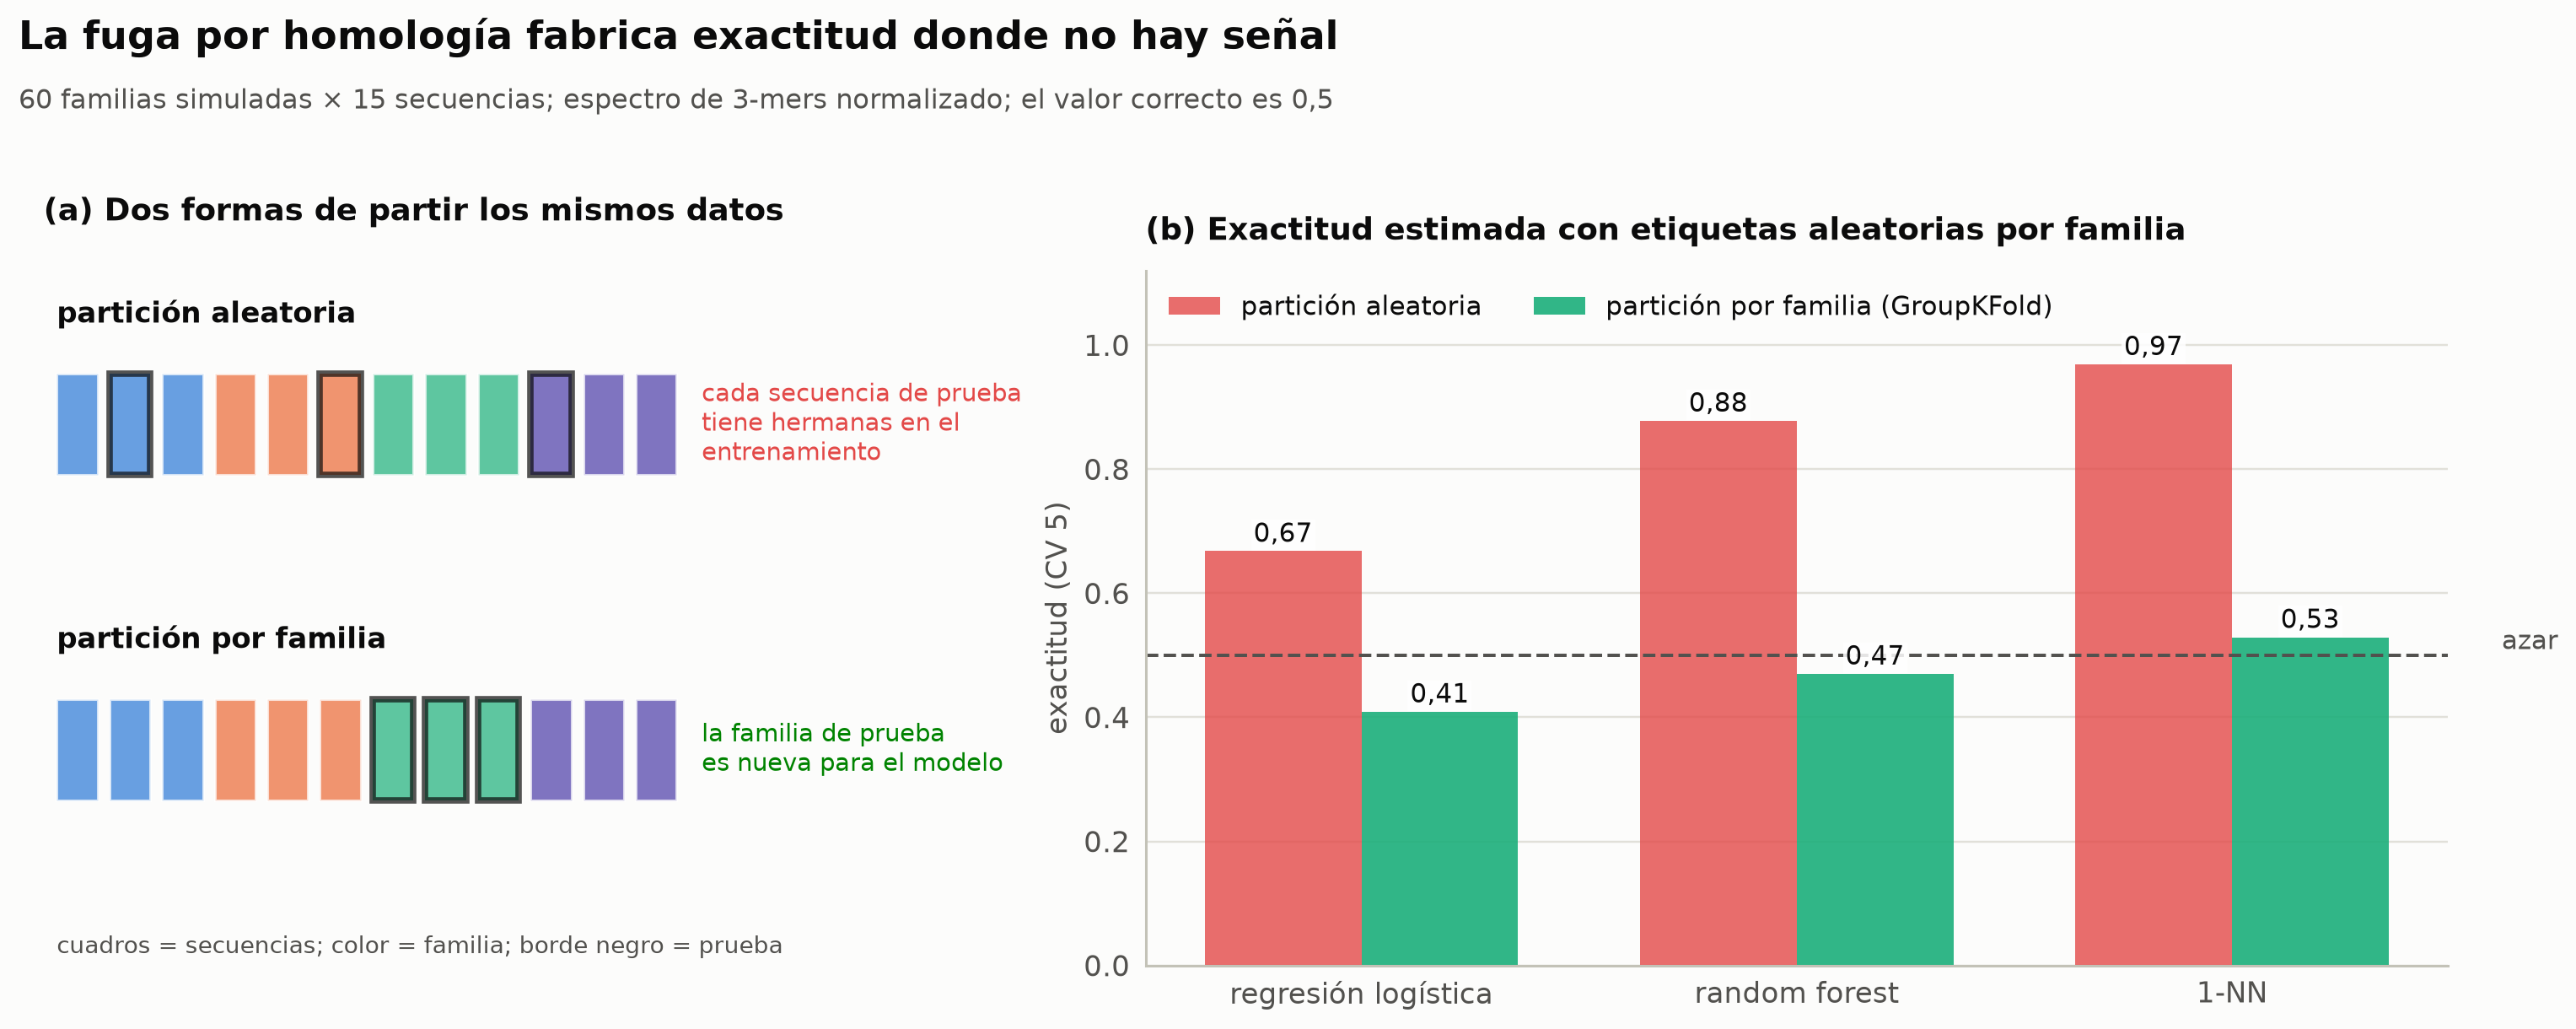

In [23]:
fig = plt.figure(figsize=(13.5, 5.2))
axs = fig.add_axes([0.02, 0.1, 0.36, 0.78]); axb = fig.add_axes([0.46, 0.14, 0.52, 0.72])
famcol = [ec.BLUE, ec.ORANGE, ec.AQUA, ec.VIOLET]
for row, (yrow, lab, test) in enumerate([(2.0, "partición aleatoria", lambda k, m_: (3 * k + m_) in (1, 5, 9)),
                                          (0.4, "partición por familia", lambda k, m_: k == 2)]):
    axs.text(0, yrow + 0.75, lab, fontsize=11, fontweight="bold")
    for k in range(4):
        for m_ in range(3):
            idx_ = 3 * k + m_
            t = test(k, m_)
            axs.add_patch(Rectangle((idx_ * 0.8, yrow), 0.62, 0.5, facecolor=famcol[k], alpha=0.7,
                                    edgecolor=ec.INK if t else "white", lw=2.5 if t else 1))
axs.text(9.8, 2.25, "cada secuencia de prueba\ntiene hermanas en el\nentrenamiento", fontsize=9.5, color=ec.RED, va="center")
axs.text(9.8, 0.65, "la familia de prueba\nes nueva para el modelo", fontsize=9.5, color=ec.GREEN, va="center")
axs.text(0, -0.35, "cuadros = secuencias; color = familia; borde negro = prueba", fontsize=9, color=ec.INK_2)
axs.set_xlim(-0.2, 13.5); axs.set_ylim(-0.6, 3.1); axs.axis("off")
axs.set_title("(a) Dos formas de partir los mismos datos", loc="left", fontsize=12)
xi = np.arange(3); wbar = 0.36
va = [r[1] for r in fuga]; vf = [r[2] for r in fuga]
b1 = axb.bar(xi - wbar / 2, va, wbar, color=ec.RED, alpha=0.8, label="partición aleatoria")
b2 = axb.bar(xi + wbar / 2, vf, wbar, color=ec.AQUA, alpha=0.9, label="partición por familia (GroupKFold)")
for bars in (b1, b2):
    for r in bars:
        axb.text(r.get_x() + r.get_width() / 2, r.get_height() + 0.015, fmt(r.get_height(), 2), ha="center", fontsize=10,
                 bbox=dict(fc="white", ec="none", alpha=0.85, pad=1))
axb.axhline(0.5, color=ec.INK_2, ls="--", lw=1.3); axb.text(2.62, 0.51, "azar", fontsize=10, color=ec.INK_2)
axb.set_xticks(xi, [r[0] for r in fuga]); axb.set_ylim(0, 1.12); axb.set_ylabel("exactitud (CV 5)")
axb.legend(frameon=False, loc="upper left", ncol=2, bbox_to_anchor=(0, 1.0))
axb.set_title("(b) Exactitud estimada con etiquetas aleatorias por familia", loc="left", fontsize=12)
ec.fig_title(fig, "La fuga por homología fabrica exactitud donde no hay señal",
             "60 familias simuladas × 15 secuencias; espectro de 3-mers normalizado; el valor correcto es 0,5")
plt.show()

> 🔎 **Qué observamos.** Es la figura 17.4 del libro. La partición aleatoria produce estimaciones espectaculares, sobre
> todo para los métodos que memorizan (1-NN reconoce a la hermana; el bosque, casi). La partición por familia devuelve
> cifras compatibles con el azar, que es la verdad. Los valores algo inferiores a 0,5 se deben a que, al retirar
> familias enteras, la proporción de clases del entrenamiento se desplaza en sentido contrario a la del bloque de prueba.

### 8.3 Tres fugas en los datos reales de CTCF

**(a) Parentesco por cercanía genómica.** En CTCF no hay familias evidentes, pero las ventanas de fondo vienen en
bloques de 25 ventanas contiguas de una misma región, y los sitios de un mismo cromosoma comparten entorno. La unidad
de partición natural es el **cromosoma** (`GroupKFold` con `groups=cromosoma`), que además imita el uso real: aplicar el
modelo a regiones del genoma no vistas.

**(b) Preprocesamiento fuera de la validación.** Elegimos los 50 6-mers «más discriminativos» con **todas** las
secuencias y después validamos. Para que no haya dudas de que es una fuga, **barajamos las etiquetas**: no hay nada que
aprender, y el AUC honesto debe ser 0,5.

**(c) Un atajo: el contenido de GC.** Si los negativos son ventanas aleatorias del genoma (GC ≈ 0,41) y los positivos
son sitios de CTCF (GC ≈ 0,52), el GC sólo ya discrimina. Construimos un segundo fondo **emparejado por GC**: para cada
sitio tomamos una ventana de fondo del mismo intervalo de GC (en pasos de 0,05).

In [24]:
lr6 = lambda: make_pipeline(CountVectorizer(analyzer="char", ngram_range=(6, 6), lowercase=False),
                            LogisticRegression(C=0.1, max_iter=5000))
# (a) partición aleatoria frente a partición por cromosoma
auc_rand = cross_val_score(lr6(), seqs_bal, y_bal, cv=cv5, scoring="roc_auc").mean()
auc_chr = cross_val_score(lr6(), seqs_bal, y_bal, cv=GroupKFold(5), groups=chr_bal, scoring="roc_auc").mean()
print(f"(a) LR 6-mers: AUC partición aleatoria = {fmt(auc_rand)} · por cromosoma = {fmt(auc_chr)}")

# (b) selección de atributos fuera / dentro del pipeline, con etiquetas barajadas
y_shuf = np.random.default_rng(1).permutation(y_bal)
X6 = CountVectorizer(analyzer="char", ngram_range=(6, 6), lowercase=False).fit_transform(seqs_bal)
X6_sel = SelectKBest(chi2, k=50).fit_transform(X6, y_shuf)               # ✘ ve las etiquetas de la prueba
auc_leak = cross_val_score(LogisticRegression(C=0.1, max_iter=5000), X6_sel, y_shuf, cv=cv5, scoring="roc_auc").mean()
pipe_ok = make_pipeline(SelectKBest(chi2, k=50), LogisticRegression(C=0.1, max_iter=5000))  # ✔ dentro de cada partición
auc_ok = cross_val_score(pipe_ok, X6, y_shuf, cv=cv5, scoring="roc_auc").mean()
print(f"(b) etiquetas barajadas: selección fuera del pipeline AUC = {fmt(auc_leak)} · dentro = {fmt(auc_ok)}")

# (c) fondo emparejado por GC
gcb = np.floor(gc_n / 0.05).astype(int); gcp = np.floor(gc_p / 0.05).astype(int)
rng_m = np.random.default_rng(7)
pool = {b_: list(rng_m.permutation(np.where(gcb == b_)[0])) for b_ in np.unique(gcb)}
match = []
for b_ in gcp:
    if pool.get(b_):
        match.append(pool[b_].pop())
match = np.array(match)
print(f"(c) fondo emparejado: {len(match)} ventanas para {len(gc_p)} sitios (los sitios con GC extremo no tienen pareja)")
seqs_gc = ctcf_pos + [ctcf_neg[i] for i in match]
y_gc = np.r_[np.ones(1000), np.zeros(len(match))].astype(int)
chr_gc = np.r_[chr_pos, chr_neg[match]]
res_atajo = {}
for nm_, S_, Y_, gcv in (("fondo aleatorio", seqs_bal, y_bal, np.r_[gc_p, gc_n[idx_neg]]),
                         ("fondo emparejado por GC", seqs_gc, y_gc, np.r_[gc_p, gc_n[match]])):
    a_gc = roc_auc_score(Y_, gcv)
    a_km = cross_val_score(lr6(), S_, Y_, cv=cv5, scoring="roc_auc").mean()
    res_atajo[nm_] = (a_gc, a_km)
    print(f"    {nm_:25s} AUC sólo GC = {fmt(a_gc)} · AUC LR 6-mers = {fmt(a_km)}")

(a) LR 6-mers: AUC partición aleatoria = 0,892 · por cromosoma = 0,882
(b) etiquetas barajadas: selección fuera del pipeline AUC = 0,684 · dentro = 0,488
(c) fondo emparejado: 967 ventanas para 1000 sitios (los sitios con GC extremo no tienen pareja)


    fondo aleatorio           AUC sólo GC = 0,764 · AUC LR 6-mers = 0,892


    fondo emparejado por GC   AUC sólo GC = 0,522 · AUC LR 6-mers = 0,841


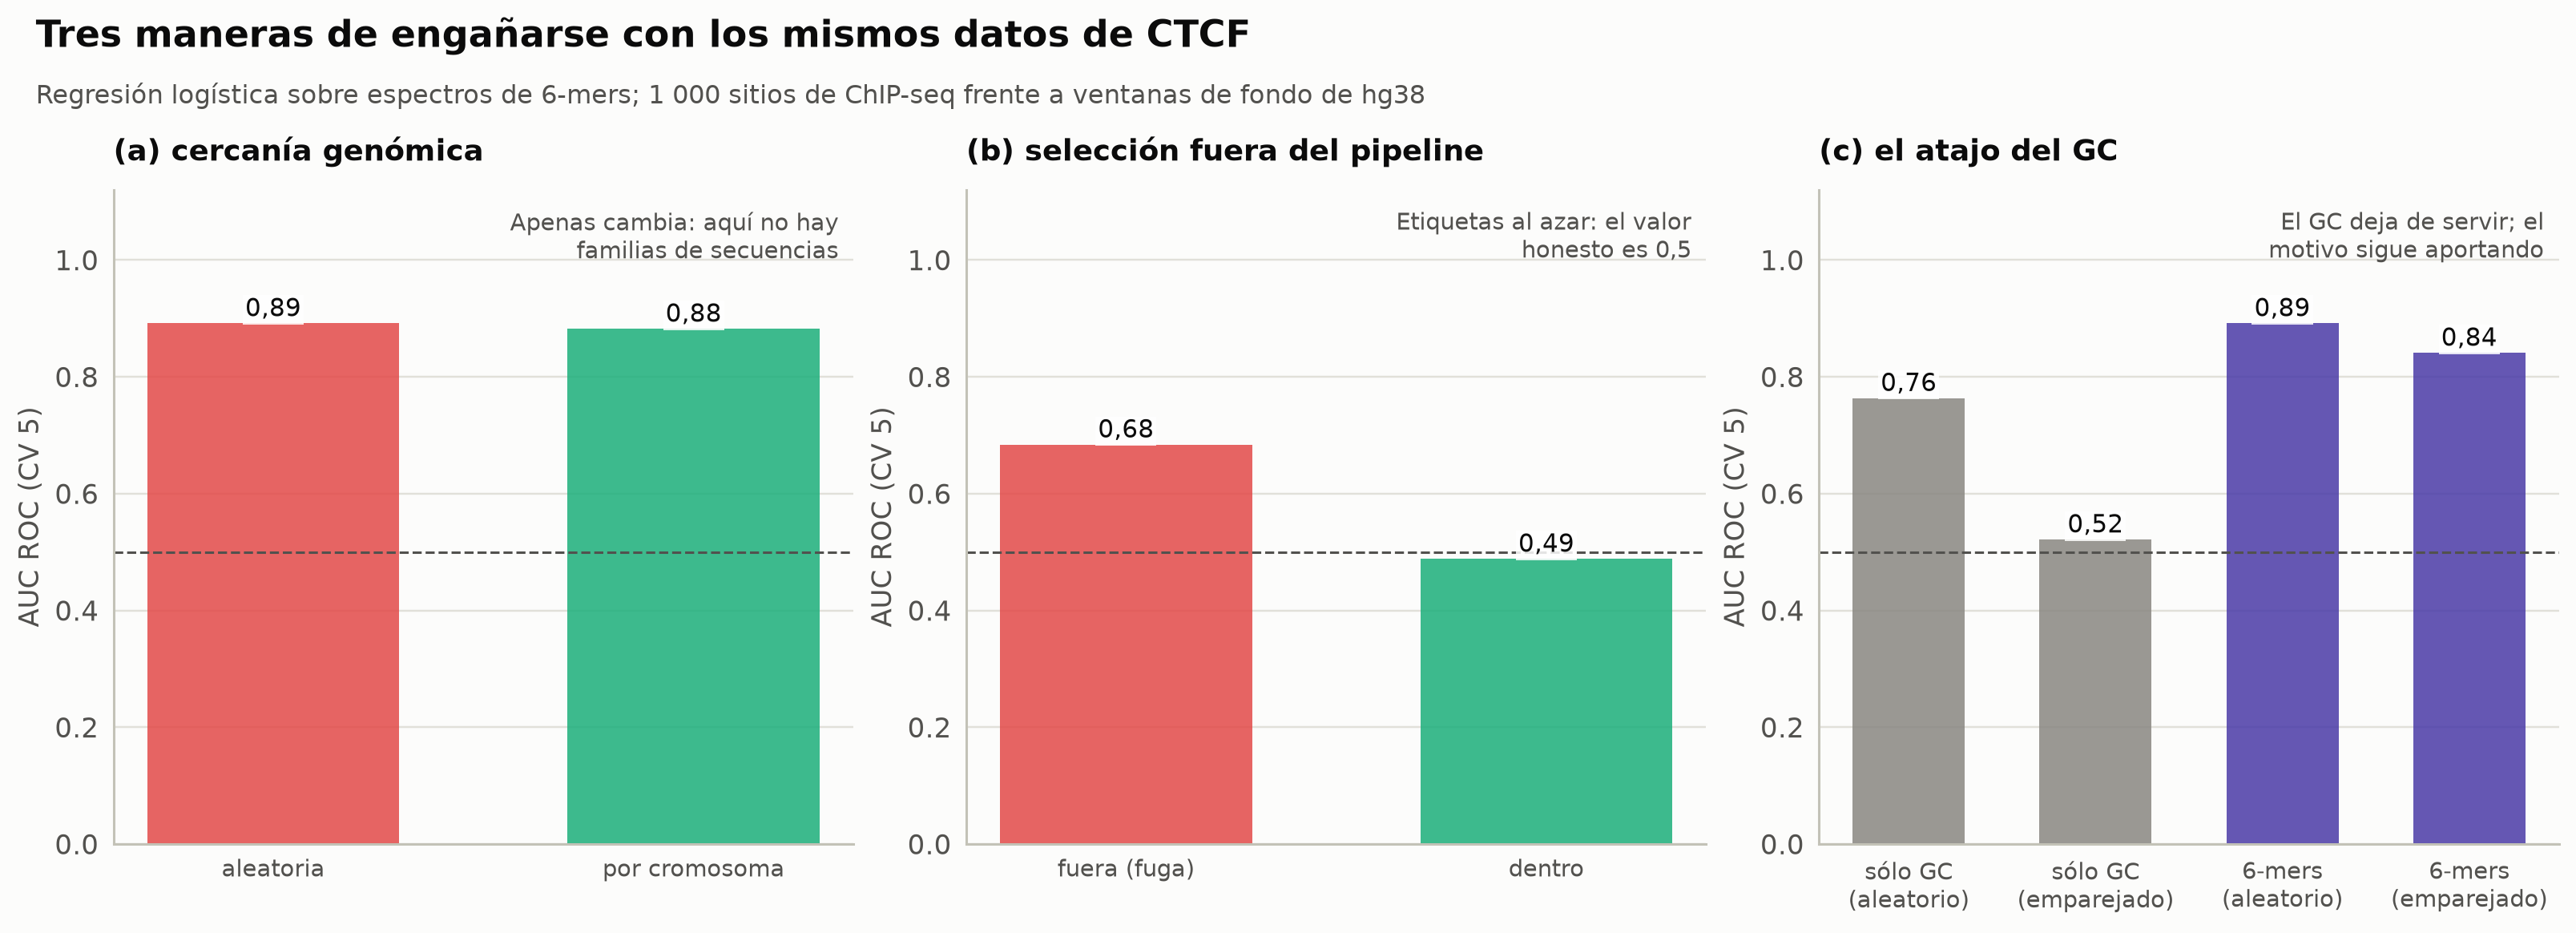

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.5))
panels = [("(a) cercanía genómica", ["aleatoria", "por cromosoma"], [auc_rand, auc_chr], [ec.RED, ec.AQUA],
           "Apenas cambia: aquí no hay\nfamilias de secuencias"),
          ("(b) selección fuera del pipeline", ["fuera (fuga)", "dentro"], [auc_leak, auc_ok], [ec.RED, ec.AQUA],
           "Etiquetas al azar: el valor\nhonesto es 0,5"),
          ("(c) el atajo del GC", ["sólo GC\n(aleatorio)", "sólo GC\n(emparejado)", "6-mers\n(aleatorio)", "6-mers\n(emparejado)"],
           [res_atajo["fondo aleatorio"][0], res_atajo["fondo emparejado por GC"][0],
            res_atajo["fondo aleatorio"][1], res_atajo["fondo emparejado por GC"][1]],
           [ec.MUTED, ec.MUTED, ec.VIOLET, ec.VIOLET], "El GC deja de servir; el\nmotivo sigue aportando")]
for ax, (tt_, labs, vals, cols, note) in zip(axes, panels):
    bars = ax.bar(range(len(vals)), vals, color=cols, alpha=0.85, width=0.6)
    for r in bars:
        ax.text(r.get_x() + r.get_width() / 2, r.get_height() + 0.012, fmt(r.get_height(), 2), ha="center", fontsize=10,
                bbox=dict(fc="white", ec="none", alpha=0.85, pad=1))
    ax.axhline(0.5, color=ec.INK_2, ls="--", lw=1)
    ax.set_xticks(range(len(vals)), labs, fontsize=9.5); ax.set_ylim(0, 1.12); ax.set_ylabel("AUC ROC (CV 5)")
    ax.set_title(tt_, loc="left", fontsize=12)
    ax.text(0.98, 0.97, note, transform=ax.transAxes, ha="right", va="top", fontsize=9.5, color=ec.INK_2)
ec.fig_title(fig, "Tres maneras de engañarse con los mismos datos de CTCF",
             "Regresión logística sobre espectros de 6-mers; 1 000 sitios de ChIP-seq frente a ventanas de fondo de hg38")
plt.show()

> 🔎 **Qué observamos.**
> - **(a)** Partir por cromosoma apenas cambia el AUC. Es un hallazgo, no un fracaso: la fuga depende de cuán
>   emparentadas estén las muestras. Estas ventanas no son copias unas de otras como las familias simuladas; aun así, la
>   partición por cromosoma es la que responde a la pregunta real.
> - **(b)** Con etiquetas **al azar**, seleccionar atributos antes de validar da un AUC muy por encima de 0,5: los 50
>   6-mers elegidos «vieron» las etiquetas de la prueba. Dentro del *pipeline*, el AUC vuelve al azar.
> - **(c)** Frente al fondo aleatorio, el GC sólo ya da un AUC alto; frente al fondo emparejado, cae a ≈ 0,5, y el
>   modelo de 6-mers también baja, pero se mantiene por encima del azar: esa diferencia es lo que realmente aprendió del
>   **motivo**. Un modelo presentado sólo con el fondo aleatorio habría exagerado su mérito biológico.

> ⚠️ **Cómo evitar la fuga de información** (recuadro del libro)
> 1. **Agrupe antes de partir.** Agrupe las secuencias por similitud (por ejemplo, con MMseqs2 o CD-HIT al 30–40 % de
>    identidad para proteínas) y use los grupos como unidad de partición (`GroupKFold` en scikit-learn).
> 2. **Preprocese dentro de cada partición.** Seleccionar los $k$-mers más discriminativos, estandarizar o imputar usando
>    todos los datos antes de la validación cruzada filtra información de la prueba. Encadene los pasos en un `Pipeline`.
> 3. **Reserve un conjunto de prueba final** que no se toque durante la selección de hiperparámetros; la validación
>    cruzada anidada estima el error del procedimiento completo.
> 4. **Piense en el uso real.** Si el modelo se aplicará a especies no vistas, particione por especie; si a datos
>    futuros, por fecha; si a regiones nuevas del genoma, por cromosoma. Y elija negativos que no dejen atajos.

## 9. Métricas para clases desbalanceadas

En genómica, los positivos suelen ser raros: menos del 1 % de las posiciones de un genoma son sitios de unión de un
factor dado, y la mayoría de las variantes de sentido erróneo son benignas. Con un 1 % de positivos, un clasificador
que siempre dice «negativo» tiene un 99 % de exactitud y no sirve para nada, como un detector de incendios sin pilas
que «acierta» 364 días al año.

Para un umbral de decisión $\tau$, sean VP, FP, VN y FN los verdaderos y falsos positivos y negativos. La **curva ROC**
representa la tasa de verdaderos positivos $\mathrm{TPR}=\mathrm{VP}/(\mathrm{VP}+\mathrm{FN})$ (sensibilidad o
exhaustividad) frente a la de falsos positivos $\mathrm{FPR}=\mathrm{FP}/(\mathrm{FP}+\mathrm{VN})$ al variar $\tau$.
Ambas tasas se calculan **dentro** de cada clase, así que la curva ROC no depende de la proporción de positivos. La
**curva de precisión-exhaustividad** (PR) representa, en cambio, la precisión $\mathrm{VP}/(\mathrm{VP}+\mathrm{FP})$,
que mezcla las dos clases. Por el teorema de Bayes, con prevalencia $\pi$ (ecuación 17.15):

$$
\mathrm{Precisión}(\tau) = \frac{\mathrm{TPR}(\tau)\,\pi}{\mathrm{TPR}(\tau)\,\pi + \mathrm{FPR}(\tau)\,(1-\pi)}.
$$

| Símbolo | Significado |
|---|---|
| $\pi$ | Prevalencia: fracción de positivos en la población donde se aplicará el modelo |
| $\mathrm{TPR},\ \mathrm{FPR}$ | Tasas de verdaderos y falsos positivos al umbral $\tau$ |
| $\tau$ | Umbral sobre la puntuación del clasificador a partir del cual se predice «positivo» |

Cuando $\pi$ es pequeño, el término $\mathrm{FPR}\,(1-\pi)$ domina el denominador y la precisión se hunde, aunque la
curva ROC no cambie. Saito y Rehmsmeier (2015) mostraron que en conjuntos desbalanceados la curva PR es más informativa
que la ROC y que la línea base de la curva PR no es 0,5 sino $\pi$.

### Ejemplo del libro: «Un clasificador excelente que casi siempre se equivoca»

Un predictor de sitios de unión tiene $\mathrm{TPR}=0{,}90$ y $\mathrm{FPR}=0{,}05$ a su umbral por defecto: parece muy
bueno. Si lo aplicamos a regiones donde sólo el 1 % son sitios reales ($\pi=0{,}01$):

$$
\text{Precisión}=\frac{0{,}90\times0{,}01}{0{,}90\times0{,}01+0{,}05\times0{,}99}=\frac{0{,}009}{0{,}0585}\approx0{,}154.
$$

De cada 100 predicciones positivas, unas 85 son falsas. El mismo clasificador, con clases equilibradas ($\pi=0{,}5$),
tendría una precisión de $0{,}947$.

> 🤔 **Antes de ejecutar, prediga.** Si el mismo predictor se aplica a todo el genoma humano, donde quizá
> $\pi\approx0{,}001$, ¿será la precisión mayor o menor que 0,1?

In [26]:
def precision_at(tpr, fpr, prev):
    return tpr * prev / (tpr * prev + fpr * (1 - prev))
for prev in (0.5, 0.1, 0.01, 0.001):
    pr_ = precision_at(0.90, 0.05, prev)
    print(f"π = {prev:<6} → precisión = {fmt(pr_, 3)}  (de cada 100 positivos predichos, {100 * (1 - pr_):.0f} son falsos)")
print("[libro: π = 0,01 → 0,154; π = 0,5 → 0,947]")

π = 0.5    → precisión = 0,947  (de cada 100 positivos predichos, 5 son falsos)
π = 0.1    → precisión = 0,667  (de cada 100 positivos predichos, 33 son falsos)
π = 0.01   → precisión = 0,154  (de cada 100 positivos predichos, 85 son falsos)
π = 0.001  → precisión = 0,018  (de cada 100 positivos predichos, 98 son falsos)
[libro: π = 0,01 → 0,154; π = 0,5 → 0,947]


### La figura ROC/PR del libro

El libro genera puntuaciones normales $\mathcal N(1{,}5,1)$ para los positivos y $\mathcal N(0,1)$ para los negativos
(AUC teórica $0{,}856$), una vez con 2 000 + 2 000 y otra con 200 positivos entre 20 000 secuencias ($\pi=0{,}01$). Cifras
del libro: AUC 0,852 / 0,883 y AP (precisión media) 0,852 / 0,127.

AUC: equilibrado 0,852 · desbalanceado 0,883   [libro: 0,852 / 0,883]
AP:  equilibrado 0,852 · desbalanceado 0,127   [libro: 0,852 / 0,127]
AUC teórica = Φ(1,5/√2) = 0,856


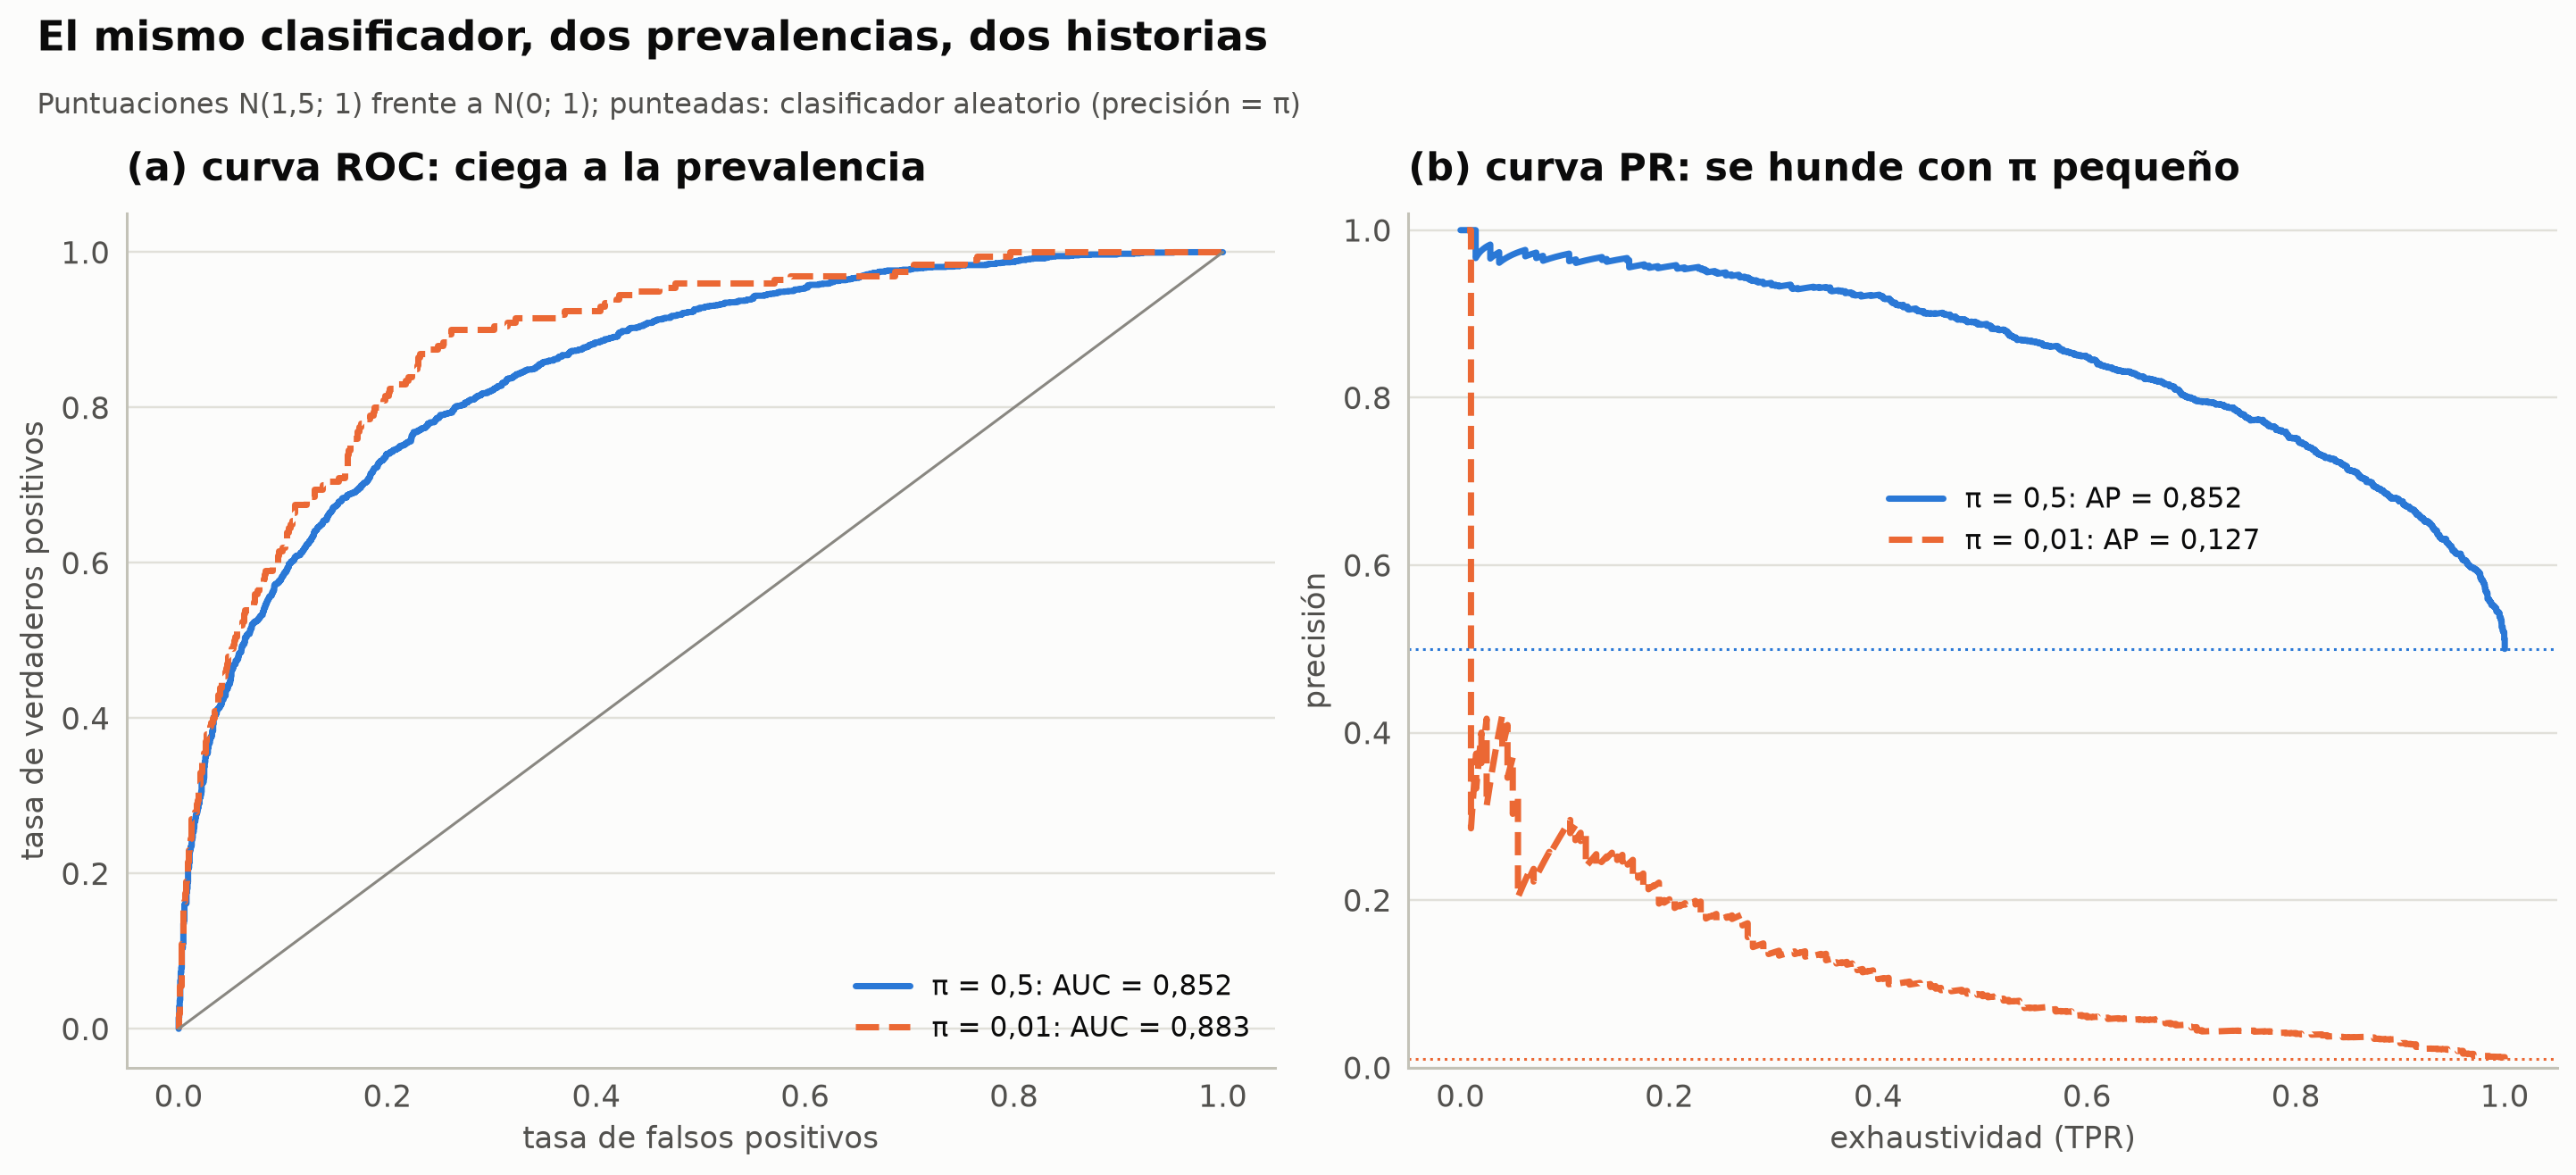

In [27]:
def curvas(npos, nneg):
    """Función del libro (continúa el mismo generador rng_libro)."""
    sp = rng_libro.normal(1.5, 1, npos); sn = rng_libro.normal(0, 1, nneg)
    yy = np.r_[np.ones(npos), np.zeros(nneg)]; ss = np.r_[sp, sn]
    fpr, tpr, _ = roc_curve(yy, ss)
    pr, rc, _ = precision_recall_curve(yy, ss)
    return (fpr, tpr), (rc, pr), roc_auc_score(yy, ss), average_precision_score(yy, ss)

roc_b, pr_b, auc_b, ap_b = curvas(2000, 2000)
roc_d, pr_d, auc_d, ap_d = curvas(200, 19800)
print(f"AUC: equilibrado {fmt(auc_b)} · desbalanceado {fmt(auc_d)}   [libro: 0,852 / 0,883]")
print(f"AP:  equilibrado {fmt(ap_b)} · desbalanceado {fmt(ap_d)}   [libro: 0,852 / 0,127]")
print(f"AUC teórica = Φ(1,5/√2) = {fmt(0.5 * (1 + math.erf(1.5 / 2)))}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
ax = axes[0]
ax.plot(*roc_b, color=ec.BLUE, lw=2.3, label=f"π = 0,5: AUC = {fmt(auc_b)}")
ax.plot(*roc_d, color=ec.ORANGE, lw=2.3, ls="--", label=f"π = 0,01: AUC = {fmt(auc_d)}")
ax.plot([0, 1], [0, 1], color=ec.MUTED, lw=1)
ax.set_xlabel("tasa de falsos positivos"); ax.set_ylabel("tasa de verdaderos positivos"); ax.legend(frameon=False, loc="lower right")
ax.set_title("(a) curva ROC: ciega a la prevalencia", loc="left")
ax = axes[1]
ax.plot(*pr_b, color=ec.BLUE, lw=2.3, label=f"π = 0,5: AP = {fmt(ap_b)}")
ax.plot(*pr_d, color=ec.ORANGE, lw=2.3, ls="--", label=f"π = 0,01: AP = {fmt(ap_d)}")
ax.axhline(0.5, color=ec.BLUE, lw=1, ls=":"); ax.axhline(0.01, color=ec.ORANGE, lw=1, ls=":")
ax.set_xlabel("exhaustividad (TPR)"); ax.set_ylabel("precisión"); ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc="center", bbox_to_anchor=(0.58, 0.64))
ax.set_title("(b) curva PR: se hunde con π pequeño", loc="left")
ec.fig_title(fig, "El mismo clasificador, dos prevalencias, dos historias",
             "Puntuaciones N(1,5; 1) frente a N(0; 1); punteadas: clasificador aleatorio (precisión = π)")
plt.show()

> 🔎 **Qué observamos.** Es la figura 17.5 del libro. Las curvas ROC son prácticamente iguales (la pequeña diferencia de
> AUC es fluctuación muestral de sólo 200 positivos), mientras que las PR son radicalmente distintas: con $\pi=0{,}01$ la
> precisión media cae de 0,85 a 0,13. **Cuando los positivos son raros, informe siempre la curva PR.**

### Caso real: ¿cuántos de los sitios de CTCF predichos serían reales en el genoma?

Entrenamos la regresión logística de 6-mers con **todas** las ventanas (1 000 sitios y 6 202 fondos, $\pi\approx0{,}14$)
y obtenemos puntuaciones honestas con `cross_val_predict` por cromosoma. Con las TPR y FPR de esas puntuaciones, la
ecuación 17.15 dice qué precisión tendríamos con cualquier prevalencia. Pase el cursor por las curvas.

AUC = 0,892 · AP con π = 0,139: 0,631  (1.0 s)


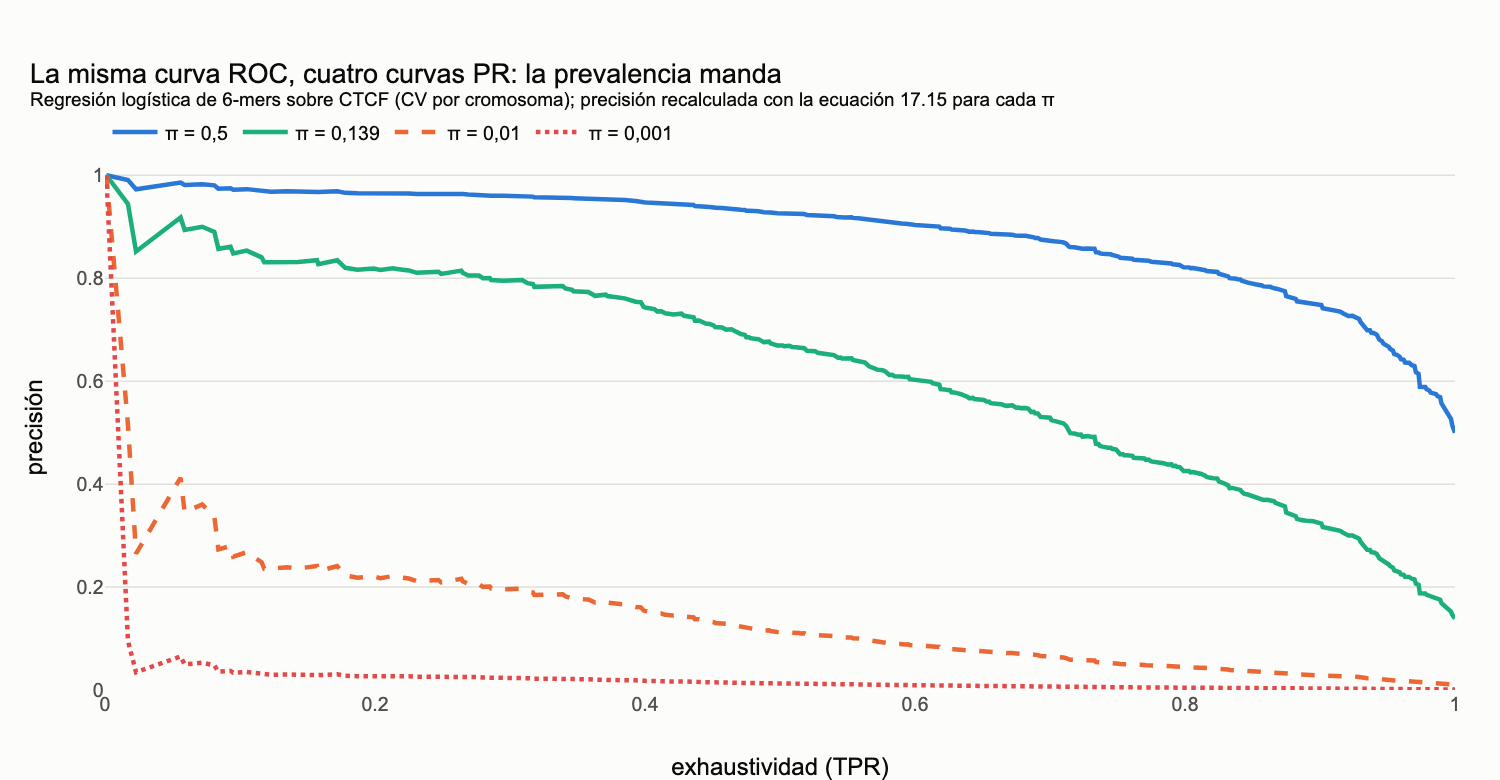

In [28]:
seqs_all = ctcf_pos + ctcf_neg
y_all = np.r_[np.ones(len(ctcf_pos)), np.zeros(len(ctcf_neg))].astype(int)
chr_all = np.r_[chr_pos, chr_neg]
t0 = time.time()
score_all = cross_val_predict(lr6(), seqs_all, y_all, cv=GroupKFold(5), groups=chr_all, method="decision_function")
fpr_r, tpr_r, thr_r = roc_curve(y_all, score_all)
print(f"AUC = {fmt(roc_auc_score(y_all, score_all))} · AP con π = {fmt(y_all.mean())}: "
      f"{fmt(average_precision_score(y_all, score_all))}  ({time.time() - t0:.1f} s)")
figp = go.Figure()
keep = np.unique(np.r_[np.linspace(1, len(fpr_r) - 1, 350).astype(int)])
for prev, col, dash in ((0.5, ec.BLUE, "solid"), (y_all.mean(), ec.AQUA, "solid"), (0.01, ec.ORANGE, "dash"),
                        (0.001, ec.RED, "dot")):
    prec = precision_at(tpr_r[keep], fpr_r[keep], prev)
    txt = [f"<b>π = {prev:.3g}</b><br>umbral τ = {thr_r[i]:.2f}<br>TPR = {tpr_r[i]:.2f} · FPR = {fpr_r[i]:.3f}<br>"
           f"precisión = {p_:.2f}<br>de cada 100 sitios predichos, <b>{100 * (1 - p_):.0f} serían falsos</b>"
           for i, p_ in zip(keep, prec)]
    figp.add_trace(go.Scatter(x=tpr_r[keep], y=prec, mode="lines", name=f"π = {prev:.3g}".replace(".", ","), text=txt,
                              hovertemplate="%{text}<extra></extra>", line=dict(color=col, width=3, dash=dash)))
figp.update_layout(title="La misma curva ROC, cuatro curvas PR: la prevalencia manda"
                         "<br><sup>Regresión logística de 6-mers sobre CTCF (CV por cromosoma); precisión recalculada con "
                         "la ecuación 17.15 para cada π</sup>",
                   xaxis=dict(title="exhaustividad (TPR)", range=[0, 1]), yaxis=dict(title="precisión", range=[0, 1.02]),
                   height=520, margin=dict(t=110, l=70, r=30, b=60),
                   legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
figp.show()

> 🔎 **Qué observamos.** Con clases equilibradas el clasificador parece excelente. Con la prevalencia de nuestro propio
> conjunto (≈ 0,14) sigue siendo útil. Pero si lo pasáramos por todo el genoma, donde las ventanas con un sitio fuerte de
> CTCF son quizá una de cada mil, casi todas sus predicciones positivas serían falsas en casi cualquier umbral. No es
> que el modelo empeore: es aritmética de Bayes. Por eso los predictores genómicos se combinan con otros datos
> (accesibilidad de la cromatina, conservación) que suben la prevalencia de las regiones candidatas.

> ✅ **Compruebe su comprensión.** Un colega reporta «AUC = 0,95» para un predictor de variantes patógenas evaluado en un
> conjunto con 50 % de patógenas. ¿Qué dato le falta para saber si será útil en la clínica, donde menos del 5 % de las
> variantes candidatas son patógenas? (La FPR al umbral de uso y la prevalencia real, o directamente la curva PR con
> esa prevalencia.)

## 10. Todo junto con scikit-learn

La biblioteca scikit-learn (Pedregosa *et al.*, 2011) ofrece una interfaz uniforme (`fit`, `predict`, `predict_proba`)
para todos los modelos de esta lección, y herramientas para encadenar el preprocesamiento con el modelo de modo que la
validación cruzada no filtre información. Este es el fragmento `clasificar_kmers.py` del libro, **sin cambios**,
aplicado a CTCF con el fondo emparejado por GC y el **cromosoma** como grupo (`fam`):

In [29]:
seqs, y, fam = seqs_gc, y_gc, chr_gc          # CTCF vs fondo emparejado por GC; grupo = cromosoma

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import make_pipeline

# seqs: lista de str; y: etiquetas 0/1; fam: clúster de homología
modelo = make_pipeline(
    CountVectorizer(analyzer="char", ngram_range=(3, 3),
                    lowercase=False),          # espectro de 3-mers
    LogisticRegression(C=1.0, max_iter=5000))  # regularización L2
cv = GroupKFold(n_splits=5)                    # familias separadas
ap = cross_val_score(modelo, seqs, y, groups=fam, cv=cv,
                     scoring="average_precision")
print(f"AP = {ap.mean():.3f} +/- {ap.std():.3f}")

AP = 0.674 +/- 0.041


Como el vectorizador forma parte del *pipeline*, el vocabulario de $k$-mers se aprende de nuevo en cada partición
usando sólo los datos de entrenamiento. Para cambiar de modelo basta con sustituir el último paso. Comparemos los tres
clasificadores de la lección con 6-mers, en las mismas particiones por cromosoma (la línea base de la AP es la
prevalencia, ≈ 0,5 aquí).

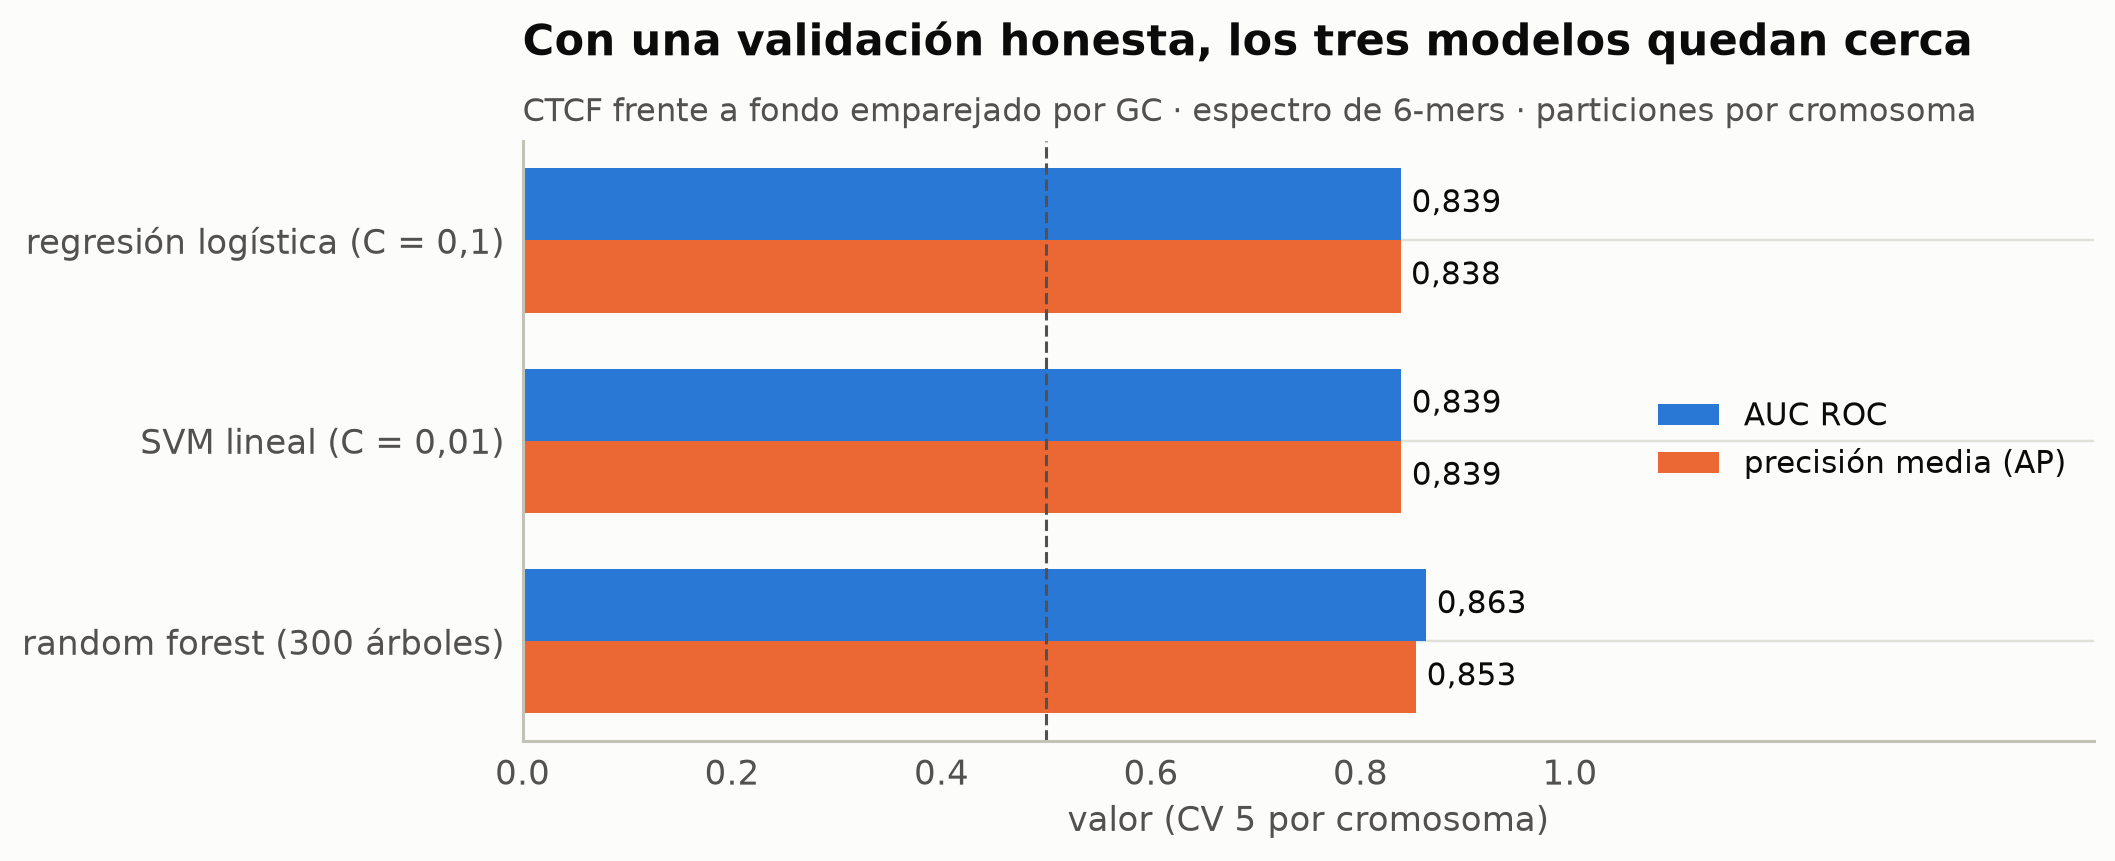

,modelo,AUC ROC,AP,segundos
0,"regresión logística (C = 0,1)",0.839,0.838,0.287
1,"SVM lineal (C = 0,01)",0.839,0.839,4.935
2,random forest (300 árboles),0.863,0.853,1.640


In [30]:
candidatos = {
    "regresión logística (C = 0,1)": LogisticRegression(C=0.1, max_iter=5000),
    "SVM lineal (C = 0,01)": SVC(kernel="linear", C=0.01),
    "random forest (300 árboles)": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=0),
}
filas = []
for nm_, clf in candidatos.items():
    t0 = time.time()
    pipe = make_pipeline(CountVectorizer(analyzer="char", ngram_range=(6, 6), lowercase=False), clf)
    r = cross_validate(pipe, seqs, y, groups=fam, cv=GroupKFold(5), scoring=["roc_auc", "average_precision"])
    filas.append((nm_, r["test_roc_auc"].mean(), r["test_average_precision"].mean(), time.time() - t0))
res_tab = pd.DataFrame(filas, columns=["modelo", "AUC ROC", "AP", "segundos"])
fig, ax = plt.subplots(figsize=(9.5, 3.8))
yy_ = np.arange(len(res_tab))[::-1]
ax.barh(yy_ + 0.18, res_tab["AUC ROC"], 0.36, color=ec.BLUE, label="AUC ROC")
ax.barh(yy_ - 0.18, res_tab["AP"], 0.36, color=ec.ORANGE, label="precisión media (AP)")
for yv, a, b_ in zip(yy_, res_tab["AUC ROC"], res_tab["AP"]):
    ax.text(a + 0.01, yv + 0.18, fmt(a), va="center", fontsize=10); ax.text(b_ + 0.01, yv - 0.18, fmt(b_), va="center", fontsize=10)
ax.axvline(0.5, color=ec.INK_2, ls="--", lw=1)
ax.set_yticks(yy_, res_tab["modelo"]); ax.set_xlim(0, 1.5); ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xlabel("valor (CV 5 por cromosoma)")
ax.legend(frameon=False, loc="center right")
ec.title(ax, "Con una validación honesta, los tres modelos quedan cerca",
         "CTCF frente a fondo emparejado por GC · espectro de 6-mers · particiones por cromosoma")
plt.show()
res_tab.round(3)

> 🔎 **Qué observamos.** Una vez eliminados el atajo del GC y la fuga, las diferencias entre modelos son pequeñas
> comparadas con las diferencias que producían las malas prácticas de la sección 8. Es la idea clave del capítulo:

> 💡 **Idea clave.** En ML para biología, la pregunta decisiva no es «¿qué modelo uso?», sino «¿a qué secuencias
> **nuevas** se parece mi conjunto de prueba?».

Los modelos lineales sobre espectros tienen un techo: no ven el orden de las palabras ni reconocen el motivo completo
de 19 pb con sus variantes. En la Lección 17.2 una red convolucional aprenderá los filtros directamente sobre la
codificación *one-hot*, combinando lo mejor de las dos representaciones de la sección 2.

## 11. Ejercicios

**Ejercicio 1 (a mano, básico).** Calcule $\Phi_3$ para $x=$ `GATTACAGAT` e $y=$ `TACAGATTAC`, el núcleo $K_3(x,y)$ y su
versión normalizada. ¿Es mayor o menor que $\tilde K_2=0{,}846$? Explique por qué. Compruebe con código.

**Ejercicio 2 (núcleo de espectro).** Extienda el experimento de la sección 5.4 a $k=8,\,9,\,10,\,12$. ¿A partir de qué
$k$ empieza a bajar el AUC? Relacione la respuesta con el número de palabras posibles ($4^k$) y el número de palabras
de cada ventana de 100 pb (de 93 con $k=8$ a 89 con $k=12$).

**Ejercicio 3 (prevalencia).** Con $\mathrm{TPR}=0{,}90$: (a) ¿qué precisión tendría el clasificador del ejemplo del
libro con $\pi=0{,}001$? (b) ¿Qué FPR necesitaría para alcanzar una precisión de 0,5 con esa prevalencia? Despeje de
la ecuación 17.15.

**Ejercicio 4 (el conocimiento previo como atributo).** La matriz de JASPAR MA0139.1 de CTCF está en
`data/api_cache/jaspar_MA0139.1.json`. Convierta sus conteos en una PWM de log-probabilidades (pseudoconteo 0,5 y fondo
uniforme), calcule para cada ventana de `seqs_gc` la **puntuación máxima** en ambas hebras y úsela como único atributo.
Compare su AUC con el de la regresión logística de 6-mers de la sección 10. ¿Qué ganaría combinándolas?

**Ejercicio 5 (validación anidada, nivel maestría).** Elija $C$ de la regresión logística de 6-mers con `GridSearchCV`
(valores $10^{-3}$ a $10$) **dentro** de cada partición por cromosoma, y estime la AP del procedimiento completo con un
`GroupKFold` externo. Compare con la AP que obtendría eligiendo el mejor $C$ mirando directamente las puntuaciones de la
validación cruzada. ¿Cuál es optimista y por qué?

In [31]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
f3x, f3y = spectrum(x_seq, 3), spectrum(y_seq, 3)
print("Φ3(x):", {u: int(c) for u, c in zip(kmers(3), f3x) if c})
print("Φ3(y):", {u: int(c) for u, c in zip(kmers(3), f3y) if c})
k3 = f3x @ f3y
print(f"K3(x,y) = {k3:.0f}; K3(x,x) = {f3x @ f3x:.0f}; K3(y,y) = {f3y @ f3y:.0f}; "
      f"normalizado = {fmt(k3 / math.sqrt((f3x @ f3x) * (f3y @ f3y)))}")
print("Es MAYOR que 0,846 (0,900): x e y comparten los bloques TACAGAT y GATTAC, así que casi todos sus 3-mers "
      "coinciden; sólo difieren en qué palabra se repite (GAT en x, TAC en y). Un k más largo no siempre reduce la "
      "similitud: depende de cómo se reparten las palabras. Con k = 4 los espectros llegan a ser idénticos.")

Φ3(x): {'ACA': 1, 'AGA': 1, 'ATT': 1, 'CAG': 1, 'GAT': 2, 'TAC': 1, 'TTA': 1}
Φ3(y): {'ACA': 1, 'AGA': 1, 'ATT': 1, 'CAG': 1, 'GAT': 1, 'TAC': 2, 'TTA': 1}
K3(x,y) = 9; K3(x,x) = 10; K3(y,y) = 10; normalizado = 0,900
Es MAYOR que 0,846 (0,900): x e y comparten los bloques TACAGAT y GATTAC, así que casi todos sus 3-mers coinciden; sólo difieren en qué palabra se repite (GAT en x, TAC en y). Un k más largo no siempre reduce la similitud: depende de cómo se reparten las palabras. Con k = 4 los espectros llegan a ser idénticos.


In [32]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
for k in (8, 9, 10, 12):
    Phi = normalize(CountVectorizer(analyzer="char", ngram_range=(k, k), lowercase=False)
                    .fit_transform(seqs_bal).astype(float))
    Kmat = (Phi @ Phi.T).toarray()
    auc = cross_val_score(SVC(kernel="precomputed", C=1), Kmat, y_bal, cv=cv5, scoring="roc_auc").mean()
    frac0 = (Kmat[np.triu_indices(len(Kmat), 1)] == 0).mean()
    print(f"k = {k:2d}: 4^k = {4**k:>9,d} · AUC = {fmt(auc)} · pares sin ninguna palabra común = {frac0:.0%}")
print("Cuando casi ningún par comparte palabras, la matriz de núcleo se parece a la identidad: la SVM sólo puede "
      "memorizar y el AUC deja de mejorar y acaba bajando.")

k =  8: 4^k =    65,536 · AUC = 0,911 · pares sin ninguna palabra común = 85%


k =  9: 4^k =   262,144 · AUC = 0,911 · pares sin ninguna palabra común = 95%


k = 10: 4^k = 1,048,576 · AUC = 0,896 · pares sin ninguna palabra común = 98%


k = 12: 4^k = 16,777,216 · AUC = 0,819 · pares sin ninguna palabra común = 100%
Cuando casi ningún par comparte palabras, la matriz de núcleo se parece a la identidad: la SVM sólo puede memorizar y el AUC deja de mejorar y acaba bajando.


In [33]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
prev = 0.001
print(f"(a) precisión con π = 0,001: {fmt(precision_at(0.9, 0.05, prev), 4)} (≈ 98 de cada 100 positivos son falsos)")
# 0,5 = TPR·π / (TPR·π + FPR·(1−π))  ⇒  FPR = TPR·π / (1−π)
fpr_need = 0.9 * prev / (1 - prev)
print(f"(b) FPR necesaria = TPR·π/(1−π) = {fpr_need:.5f}, unas {0.05 / fpr_need:.0f} veces menor que 0,05")

(a) precisión con π = 0,001: 0,0177 (≈ 98 de cada 100 positivos son falsos)
(b) FPR necesaria = TPR·π/(1−π) = 0.00090, unas 55 veces menor que 0,05


In [34]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
jas = json.load(open(course_file("api_cache/jaspar_MA0139.1.json")))
cnt = np.array([jas["pfm"][b] for b in "ACGT"]) + 0.5
pwm = np.log2(cnt / cnt.sum(0) / 0.25)                      # 4 × 19
comp = {"A": "T", "C": "G", "G": "C", "T": "A"}
def max_pwm(s):
    best = -1e9
    for seq_ in (s, "".join(comp.get(c, "N") for c in reversed(s))):
        o = onehot(seq_)
        for i in range(len(seq_) - pwm.shape[1] + 1):
            best = max(best, float((pwm * o[:, i:i + pwm.shape[1]]).sum()))
    return best
pwm_score = np.array([max_pwm(s) for s in seqs_gc])
print(f"AUC de la puntuación PWM máxima (fondo emparejado por GC) = {fmt(roc_auc_score(y_gc, pwm_score))}")
print(f"AUC de la LR de 6-mers (sección 8.3c) = {fmt(res_atajo['fondo emparejado por GC'][1])}")
print("La PWM condensa décadas de conocimiento en un solo número; combinarla con los k-mers (p. ej. añadiéndola como "
      "columna extra) permite al modelo usar a la vez el motivo completo y el contexto que lo rodea.")

AUC de la puntuación PWM máxima (fondo emparejado por GC) = 0,924
AUC de la LR de 6-mers (sección 8.3c) = 0,841
La PWM condensa décadas de conocimiento en un solo número; combinarla con los k-mers (p. ej. añadiéndola como columna extra) permite al modelo usar a la vez el motivo completo y el contexto que lo rodea.


In [35]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
from sklearn.model_selection import GridSearchCV
Cs = [1e-3, 1e-2, 1e-1, 1, 10]
base = make_pipeline(CountVectorizer(analyzer="char", ngram_range=(6, 6), lowercase=False),
                     LogisticRegression(max_iter=5000))
# (i) optimista: elegir C mirando las mismas particiones con las que se informa
aps = {C: cross_val_score(base.set_params(logisticregression__C=C), seqs, y, groups=fam, cv=GroupKFold(5),
                          scoring="average_precision").mean() for C in Cs}
print("AP por C:", {C: round(v, 3) for C, v in aps.items()}, "→ mejor", fmt(max(aps.values())))
# (ii) anidada: la búsqueda de C ocurre dentro de cada partición externa
outer = GroupKFold(5); ap_nest = []
for tr, te in outer.split(seqs, y, fam):
    gs = GridSearchCV(base, {"logisticregression__C": Cs}, cv=GroupKFold(3), scoring="average_precision")
    gs.fit([seqs[i] for i in tr], y[tr], groups=fam[tr])
    ap_nest.append(average_precision_score(y[te], gs.decision_function([seqs[i] for i in te])))
print(f"AP anidada = {fmt(np.mean(ap_nest))}")
print("En principio la primera es optimista: el máximo de varias estimaciones ruidosas está sesgado hacia arriba "
      "(el C elegido 'vio' la prueba). Aquí, con sólo 5 valores de C y una curva AP casi plana, ambas coinciden; "
      "el sesgo crece con el número de hiperparámetros explorados y con conjuntos más pequeños.")

AP por C: {0.001: np.float64(0.824), 0.01: np.float64(0.842), 0.1: np.float64(0.838), 1: np.float64(0.827), 10: np.float64(0.821)} → mejor 0,842


AP anidada = 0,842
En principio la primera es optimista: el máximo de varias estimaciones ruidosas está sesgado hacia arriba (el C elegido 'vio' la prueba). Aquí, con sólo 5 valores de C y una curva AP casi plana, ambas coinciden; el sesgo crece con el número de hiperparámetros explorados y con conjuntos más pequeños.


## 📌 Resumen

- El aprendizaje supervisado minimiza el **riesgo empírico** regularizado, pero lo que importa es el **riesgo
  esperado** sobre secuencias nuevas; todo el oficio consiste en estimar honestamente esa distancia.
- **One-hot** conserva la posición (ideal para secuencias alineadas, como los promotores de *E. coli*, donde la
  regresión logística redescubre las cajas −35 y −10); el **espectro de $k$-mers** es invariante a desplazamientos
  (útil para motivos en posición variable, como CTCF). El **núcleo de espectro** mide cuántos $k$-mers comparten dos
  secuencias sin construir los vectores ($\tilde K_2=11/13\approx0{,}846$ en el ejemplo del libro).
- **Regresión logística:** $p=\sigma(\mathbf{w}^\top\mathbf{x}+b)$; entropía cruzada convexa; gradiente
  $\frac1n\sum(p_i-y_i)\mathbf{x}_i$; un paso con $\eta=1$ baja la pérdida de 0,6931 a 0,5741 en el ejemplo del libro.
- **SVM:** maximiza el margen $2/\|\mathbf{w}\|$ con pérdida *hinge*; la solución sólo depende de los vectores de
  soporte, y el truco del núcleo permite usar el núcleo de espectro.
- **Árboles y bosques:** Gini para elegir preguntas; la varianza del bosque es $\rho\sigma^2+(1-\rho)\sigma^2/B$, por eso
  hay que decorrelacionar los árboles. Error OOB gratis.
- **Sesgo-varianza:** el error de validación dibuja una U con la complejidad (mínimo en profundidad 6 en la figura del
  libro); el de entrenamiento sólo baja.
- **Fugas:** por homología (etiquetas al azar con exactitud de 0,97), por preprocesamiento fuera del *pipeline* y por
  atajos (el GC en CTCF). Remedios: `GroupKFold`, `Pipeline`, negativos emparejados, prueba final intocable.
- **Desbalance:** la ROC es ciega a la prevalencia; la precisión depende de $\pi$ (TPR = 0,90 y FPR = 0,05 dan una
  precisión de 0,154 con $\pi=0{,}01$). Informe la curva PR.

## 📚 Lecturas recomendadas

- Greener, J. G., Kandathil, S. M., Moffat, L. y Jones, D. T. (2022). A guide to machine learning for biologists.
  *Nature Reviews Molecular Cell Biology*, 23(1), 40–55. https://doi.org/10.1038/s41580-021-00407-0
- Hastie, T., Tibshirani, R. y Friedman, J. (2009). *The Elements of Statistical Learning* (2.ª ed.). Springer.
  https://doi.org/10.1007/978-0-387-84858-7
- Leslie, C., Eskin, E. y Noble, W. S. (2002). The spectrum kernel: a string kernel for SVM protein classification.
  *Pacific Symposium on Biocomputing*, 564–575. https://doi.org/10.1142/9789812799623_0053
- Cortes, C. y Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297.
  https://doi.org/10.1007/BF00994018
- Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324
- Jones, D. T. (2019). Setting the standards for machine learning in biology. *Nature Reviews Molecular Cell Biology*,
  20(11), 659–660. https://doi.org/10.1038/s41580-019-0176-5
- Walsh, I. *et al.* (2021). DOME: recommendations for supervised machine learning validation in biology. *Nature
  Methods*, 18(10), 1122–1127. https://doi.org/10.1038/s41592-021-01205-4
- Saito, T. y Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating
  binary classifiers on imbalanced datasets. *PLOS ONE*, 10(3), e0118432. https://doi.org/10.1371/journal.pone.0118432
- Pedregosa, F. *et al.* (2011). Scikit-learn: machine learning in Python. *Journal of Machine Learning Research*, 12,
  2825–2830.
- Harley, C. B. y Reynolds, R. P. (1987). Analysis of *E. coli* promoter sequences. *Nucleic Acids Research*, 15(5),
  2343–2361. https://doi.org/10.1093/nar/15.5.2343
- Towell, G. G., Shavlik, J. W. y Noordewier, M. O. (1990). Refinement of approximate domain theories by
  knowledge-based neural networks. *Proceedings of the Eighth National Conference on Artificial Intelligence (AAAI-90)*.
  (Conjunto «E. coli promoter gene sequences» del repositorio UCI.)
- ENCODE Project Consortium (2012). An integrated encyclopedia of DNA elements in the human genome. *Nature*, 489,
  57–74. https://doi.org/10.1038/nature11247
- Rauluseviciute, I. *et al.* (2024). JASPAR 2024: 20th anniversary of the open-access database of transcription factor
  binding profiles. *Nucleic Acids Research*, 52(D1), D174–D182. https://doi.org/10.1093/nar/gkad1059

**Siguiente lección:** 17.2 · Deep learning para ADN, donde una red convolucional aprenderá el motivo por sí sola.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)